# CS3807 - Deep Learning Laboratory - Experiment 5

## Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Shiv Nadar University Chennai** | B.Tech Artificial Intelligence & Data Science | Semester V | AY 2026-27

---

### 1. Objective
Systematically study the effect of **weight initialization, regularization, optimization algorithms, CNN hyperparameters, transfer learning, fine-tuning and cross-validation** on image classification performance, using a single CNN architecture (**MobileNetV2**) and the **Oxford-IIIT Pet dataset** (37 breeds, RGB, resized to 224x224x3).

### 2. Learning Outcomes
After completing this experiment you will be able to:
- explain different weight initialization strategies;
- identify and analyze overfitting using training and validation curves;
- compare SGD, Momentum, RMSProp and Adam;
- explain CNN hyperparameters such as kernel size, stride, padding and pooling;
- understand Batch Normalization and Dropout;
- perform transfer learning and fine-tuning using MobileNetV2;
- tune important training hyperparameters;
- apply 5-fold cross-validation for model selection; and
- justify the final model using accuracy, variability and computational cost.

### Notebook map (everything required by the document)
| Doc section | Notebook part | Plots produced |
|---|---|---|
| 3. Dataset & setup | Part 1 | sample grid, class distribution |
| 4. MobileNetV2 architecture | Part 2 | architecture + parameter analysis |
| 5. Weight initialization | Part 3 | **Plot 1, Plot 2** |
| 6. Regularization & overfitting | Part 4 | **Plot 3, Plot 4** |
| 7. Batch Normalization (+ numerical example) | Part 5 | **Plot 5** |
| 8. Optimization algorithms | Part 6 | **Plot 6, Plot 7** + optimizer table |
| 9. CNN hyperparameter tuning | Part 7 | **Plot 8, Plot 9, Plot 10** |
| 10. Transfer learning & fine-tuning | Part 8 | **Plot 11, Plot 12** |
| 11. K-Fold cross-validation | Part 9 | **Plot 13** + CV table |
| 12. Final model evaluation | Part 10 | **Plot 14**, **Plot 15** + metrics table |
| 13. Overall results | Part 11 | overall comparison table |
| 14. Inference for plots | after every plot | 3-point inference |
| 15. Discussion questions | Part 12 | 23 answers |
| 16. Additional exercise | Part 13 | 2 new configs, 5-fold CV |

> **Runtime:** Runtime -> Change runtime type -> **T4 GPU**. Full run is roughly 45-60 min. Set `QUICK_MODE = True` in the config cell for a fast (~12 min) smoke run.

---
# Part 0 - Environment, Imports and Global Configuration

In [1]:
# ============================================================================
# Part 0 : imports, reproducibility, global configuration
# ============================================================================
import os, sys, time, math, json, random, warnings, itertools
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_fscore_support, accuracy_score)

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", gpus if gpus else "NONE  (enable Runtime > Change runtime type > T4 GPU)")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# ------------------------- reproducibility ---------------------------------
SEED = 42
def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    try:
        tf.keras.utils.set_random_seed(seed)
    except Exception:
        pass
set_seeds()

# ------------------------- global configuration ----------------------------
QUICK_MODE   = False        # True -> fewer epochs / folds (fast smoke test)

IMG_SIZE     = 224          # doc section 3 : all images resized to 224 x 224 x 3
CHANNELS     = 3
NUM_CLASSES  = 37           # Oxford-IIIT Pet : 37 breeds
VAL_FRACTION = 0.20         # validation carved out of the training pool
K_FOLDS      = 5            # doc section 11 : 5-fold cross validation

# epoch budgets
EPOCHS_HEAD    = 20 if not QUICK_MODE else 6    # studies on cached features
EPOCHS_CV      = 15 if not QUICK_MODE else 5    # cross-validation (frozen base)
EPOCHS_FE      = 8  if not QUICK_MODE else 3    # full-model feature extraction
EPOCHS_FT      = 8  if not QUICK_MODE else 3    # full-model fine-tuning
EPOCHS_FTCV_A  = 2  if not QUICK_MODE else 1    # fine-tune CV : head warm-up
EPOCHS_FTCV_B  = 3  if not QUICK_MODE else 1    # fine-tune CV : unfrozen phase
RUN_FINETUNE_CV = True      # set False to skip the slow fine-tuning cross-validation

BATCH_SIZE    = 32
BASE_LR       = 1e-3
FT_LR         = 1e-5        # doc section 9 : fine-tuning LR in {1e-4, 1e-5}
UNFREEZE_LAST = 30          # partial unfreezing : last N layers of MobileNetV2

# ------------------------- plotting style ----------------------------------
mpl.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 110, "savefig.dpi": 130,
    "axes.grid": True, "grid.alpha": .3, "axes.titlesize": 12,
    "axes.titleweight": "bold", "font.size": 10, "legend.fontsize": 9,
})
PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd",
           "#8c564b", "#17becf", "#e377c2"]

OUT_DIR = "exp5_outputs"; os.makedirs(OUT_DIR, exist_ok=True)
RESULTS = {}                # every study writes its summary here

def save_show(fig, name):
    """Save a figure to exp5_outputs/ and display it."""
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, name + ".png"), bbox_inches="tight")
    plt.show()

def banner(txt):
    print("\n" + "=" * 78); print(txt); print("=" * 78)

def inference(what, trend, why):
    """Doc section 14 : every major plot needs a 3-point, 2-3 line inference."""
    print("\n--- INFERENCE " + "-" * 62)
    print("1. What the plot shows : " + what)
    print("2. Trend observed      : " + trend)
    print("3. Why it occurs       : " + why)
    print("-" * 76)

def show_table(title, header, rows):
    """Small fixed-width table printer used for every results table."""
    widths = [max(len(str(header[i])), max([len(str(r[i])) for r in rows] + [0]))
              for i in range(len(header))]
    line = "  ".join("-" * w for w in widths)
    print("\n" + title); print(line)
    print("  ".join(str(header[i]).ljust(widths[i]) for i in range(len(header))))
    print(line)
    for r in rows:
        print("  ".join(str(r[i]).ljust(widths[i]) for i in range(len(header))))
    print(line)

print("\nConfiguration ready.  QUICK_MODE =", QUICK_MODE)

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : NONE  (enable Runtime > Change runtime type > T4 GPU)

Configuration ready.  QUICK_MODE = False


2026-08-28 10:57:19.248927: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


---
# Part 1 - Dataset and Experimental Setup (Doc Section 3)

**Oxford-IIIT Pet Dataset** - 7,349 RGB images of cats and dogs across **37 breeds**, with varying spatial dimensions.

Experimental considerations enforced below:
- RGB images resized to **224 x 224**;
- inputs normalized to **[-1, 1]**, exactly the preprocessing required by the ImageNet-pretrained MobileNetV2;
- **separate training, validation and test** data;
- the **test set is never touched** during any hyperparameter selection - it is opened only in Part 10;
- **MobileNetV2** is used because it is computationally far lighter than large CNNs and is therefore suitable for CPU-based laboratory work.

The official `trainval` split (3,680 images) is used as the **training pool**. It is split 80/20 into train/validation for the single-run studies, and it is also the pool used for 5-fold cross-validation. The official `test` split (3,669 images) is the **independent test set**. The two archives are read straight from the Oxford mirror, so the notebook does not depend on `tensorflow_datasets`.

In [2]:
# ============================================================================
# Part 1 : download Oxford-IIIT Pet and materialise resized uint8 arrays
# ============================================================================
# The two official archives are read directly from the Oxford mirror rather than
# through `tensorflow_datasets`.  TFDS pulls in `tensorflow-metadata`, whose
# protobuf-generated code is regularly compiled against a newer protobuf than
# the runtime Colab ships; when that happens `import tensorflow_datasets`
# raises inside its lazy loader and the failure surfaces as the very confusing
# "module 'tensorflow_datasets' has no attribute 'load'".  Reading the tarballs
# needs nothing beyond the standard library plus Pillow, and reproduces exactly
# the official 3,680 / 3,669 trainval-test split of the 37 breeds.
import tarfile, urllib.request
from concurrent.futures import ThreadPoolExecutor
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True     # a few Oxford JPEGs are truncated

banner("DOWNLOADING OXFORD-IIIT PET DATASET (this may take 2-4 minutes)")

DATA_ROOT = "oxford_iiit_pet"
MIRRORS   = ["https://thor.robots.ox.ac.uk/pets/",
             "https://thor.robots.ox.ac.uk/~vgg/data/pets/",
             "https://www.robots.ox.ac.uk/~vgg/data/pets/data/"]
ARCHIVES  = ["images.tar.gz", "annotations.tar.gz"]
os.makedirs(DATA_ROOT, exist_ok=True)


def fetch(fn):
    """Download one archive, trying every known Oxford mirror in turn."""
    dst = os.path.join(DATA_ROOT, fn)
    if os.path.exists(dst) and os.path.getsize(dst) > 1_000_000:
        print("  %-20s already present (%.0f MB)" % (fn, os.path.getsize(dst) / 1e6))
        return dst
    last_err = None
    for base in MIRRORS:
        try:
            t0 = time.time()

            def hook(blocks, block_size, total, _fn=fn):
                if total > 0 and blocks % 500 == 0:
                    print("\r  %-20s %5.1f %%" % (_fn, 100 * min(blocks * block_size / total, 1.0)),
                          end="")

            urllib.request.urlretrieve(base + fn, dst + ".part", hook)
            os.replace(dst + ".part", dst)
            print("\r  %-20s %.0f MB downloaded  (%.0fs)"
                  % (fn, os.path.getsize(dst) / 1e6, time.time() - t0))
            return dst
        except Exception as err:                        # try the next mirror
            last_err = err
    raise RuntimeError("could not download %s from any mirror : %s" % (fn, last_err))


def extract(fn):
    path   = os.path.join(DATA_ROOT, fn)
    marker = os.path.join(DATA_ROOT, "." + fn + ".done")
    if os.path.exists(marker):
        print("  %-20s already extracted" % fn)
        return
    with tarfile.open(path) as tar:
        try:
            tar.extractall(DATA_ROOT, filter="data")    # Python >= 3.12
        except TypeError:
            tar.extractall(DATA_ROOT)
    open(marker, "w").close()
    print("  %-20s extracted" % fn)


for archive in ARCHIVES:
    fetch(archive)
    extract(archive)

IMG_DIR = os.path.join(DATA_ROOT, "images")
ANN_DIR = os.path.join(DATA_ROOT, "annotations")


def read_split(fname):
    """annotations/{trainval,test}.txt  ->  [(file stem, class id 0..36), ...]"""
    rows = []
    with open(os.path.join(ANN_DIR, fname)) as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            rows.append((parts[0], int(parts[1]) - 1))   # CLASS-ID is 1-based
    return rows


pool_rows = read_split("trainval.txt")
test_rows = read_split("test.txt")

# breed name of every class id, recovered from the file stem: Abyssinian_100 -> Abyssinian
NUM_CLASSES = 1 + max(c for _, c in pool_rows + test_rows)
CLASS_NAMES = [""] * NUM_CLASSES
for stem, cid in pool_rows + test_rows:
    CLASS_NAMES[cid] = stem.rsplit("_", 1)[0]

N_POOL, N_TEST = len(pool_rows), len(test_rows)

print("\nDataset          : oxford_iiit_pet 4.0.0  (official Oxford archives)")
print("Classes (breeds) :", NUM_CLASSES)
print("Training pool    :", N_POOL, "images")
print("Test set         :", N_TEST, "images  (UNTOUCHED until Part 10)")
print("Total            :", N_POOL + N_TEST, "images")
print("First 8 classes  :", CLASS_NAMES[:8])


RESAMPLE = getattr(Image, "Resampling", Image).BILINEAR


def materialise(rows, name):
    """Decode every JPEG, resize it to 224x224 and stack into one uint8 array."""
    X = np.zeros((len(rows), IMG_SIZE, IMG_SIZE, CHANNELS), dtype=np.uint8)
    y = np.zeros((len(rows),), dtype=np.int32)

    def one(i):
        stem, cid = rows[i]
        with Image.open(os.path.join(IMG_DIR, stem + ".jpg")) as im:
            im = im.convert("RGB").resize((IMG_SIZE, IMG_SIZE), RESAMPLE)
            X[i] = np.asarray(im, dtype=np.uint8)
        y[i] = cid

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as pool:
        list(pool.map(one, range(len(rows))))
    print("  %-14s -> %s  (%.1fs)" % (name, str(X.shape), time.time() - t0))
    return X, y


banner("MATERIALISING IMAGES AT 224 x 224")
X_pool_img, y_pool = materialise(pool_rows, "training pool")
X_test_img, y_test = materialise(test_rows, "test set")
print("\nMemory used by image arrays : %.2f GB" %
      ((X_pool_img.nbytes + X_test_img.nbytes) / 1e9))



DOWNLOADING OXFORD-IIIT PET DATASET (this may take 2-4 minutes)
  images.tar.gz        792 MB downloaded  (3s)
  images.tar.gz        extracted
  annotations.tar.gz   19 MB downloaded  (0s)
  annotations.tar.gz   extracted

Dataset          : oxford_iiit_pet 4.0.0  (official Oxford archives)
Classes (breeds) : 37
Training pool    : 3680 images
Test set         : 3669 images  (UNTOUCHED until Part 10)
Total            : 7349 images
First 8 classes  : ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay']

MATERIALISING IMAGES AT 224 x 224
  training pool  -> (3680, 224, 224, 3)  (9.6s)
  test set       -> (3669, 224, 224, 3)  (9.5s)

Memory used by image arrays : 1.11 GB


Train      : 2944
Validation : 736
Test       : 3669  <- untouched until Part 10

Images/class  train : min 74  max 80  mean 79.6
Images/class  val   : min 19  max 20  mean 19.9

Random-guess (chance) accuracy = 1/37 = 2.70 %


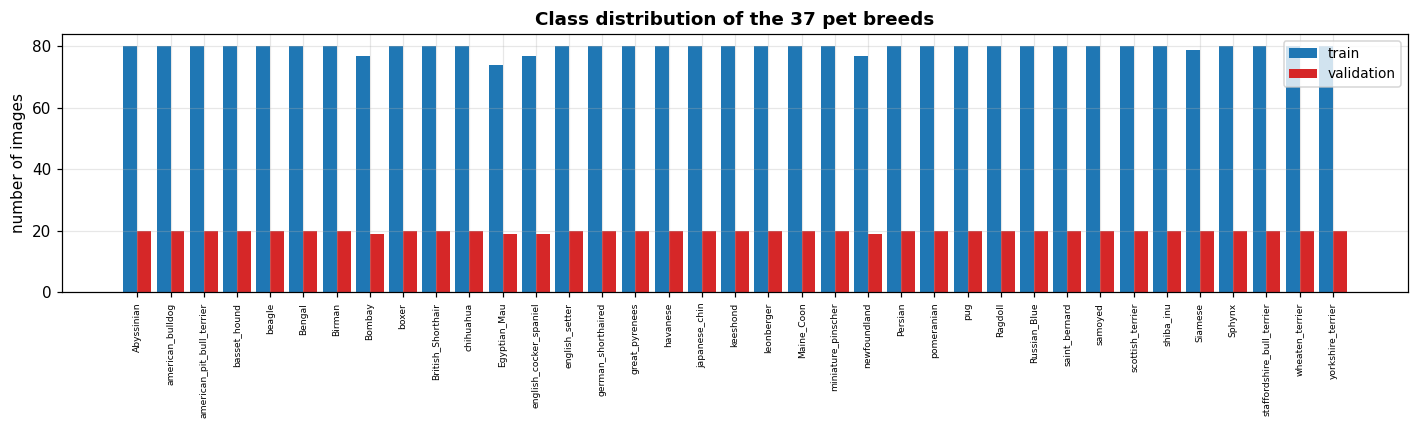

In [3]:
# ---- stratified train / validation split of the training pool --------------
idx_all = np.arange(len(y_pool))
idx_tr, idx_va = train_test_split(idx_all, test_size=VAL_FRACTION,
                                  random_state=SEED, stratify=y_pool)
y_tr, y_va = y_pool[idx_tr], y_pool[idx_va]

print("Train      :", len(idx_tr))
print("Validation :", len(idx_va))
print("Test       :", len(y_test), " <- untouched until Part 10")

cnt_tr = np.bincount(y_tr, minlength=NUM_CLASSES)
cnt_va = np.bincount(y_va, minlength=NUM_CLASSES)
print("\nImages/class  train : min %d  max %d  mean %.1f" % (cnt_tr.min(), cnt_tr.max(), cnt_tr.mean()))
print("Images/class  val   : min %d  max %d  mean %.1f" % (cnt_va.min(), cnt_va.max(), cnt_va.mean()))
CHANCE = 1.0 / NUM_CLASSES
print("\nRandom-guess (chance) accuracy = 1/37 = %.2f %%" % (100 * CHANCE))

fig, ax = plt.subplots(figsize=(13, 4))
w = 0.42; xs = np.arange(NUM_CLASSES)
ax.bar(xs - w / 2, cnt_tr, w, label="train", color=PALETTE[0])
ax.bar(xs + w / 2, cnt_va, w, label="validation", color=PALETTE[1])
ax.set_xticks(xs); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax.set_ylabel("number of images"); ax.set_title("Class distribution of the 37 pet breeds")
ax.legend(); save_show(fig, "00_class_distribution")

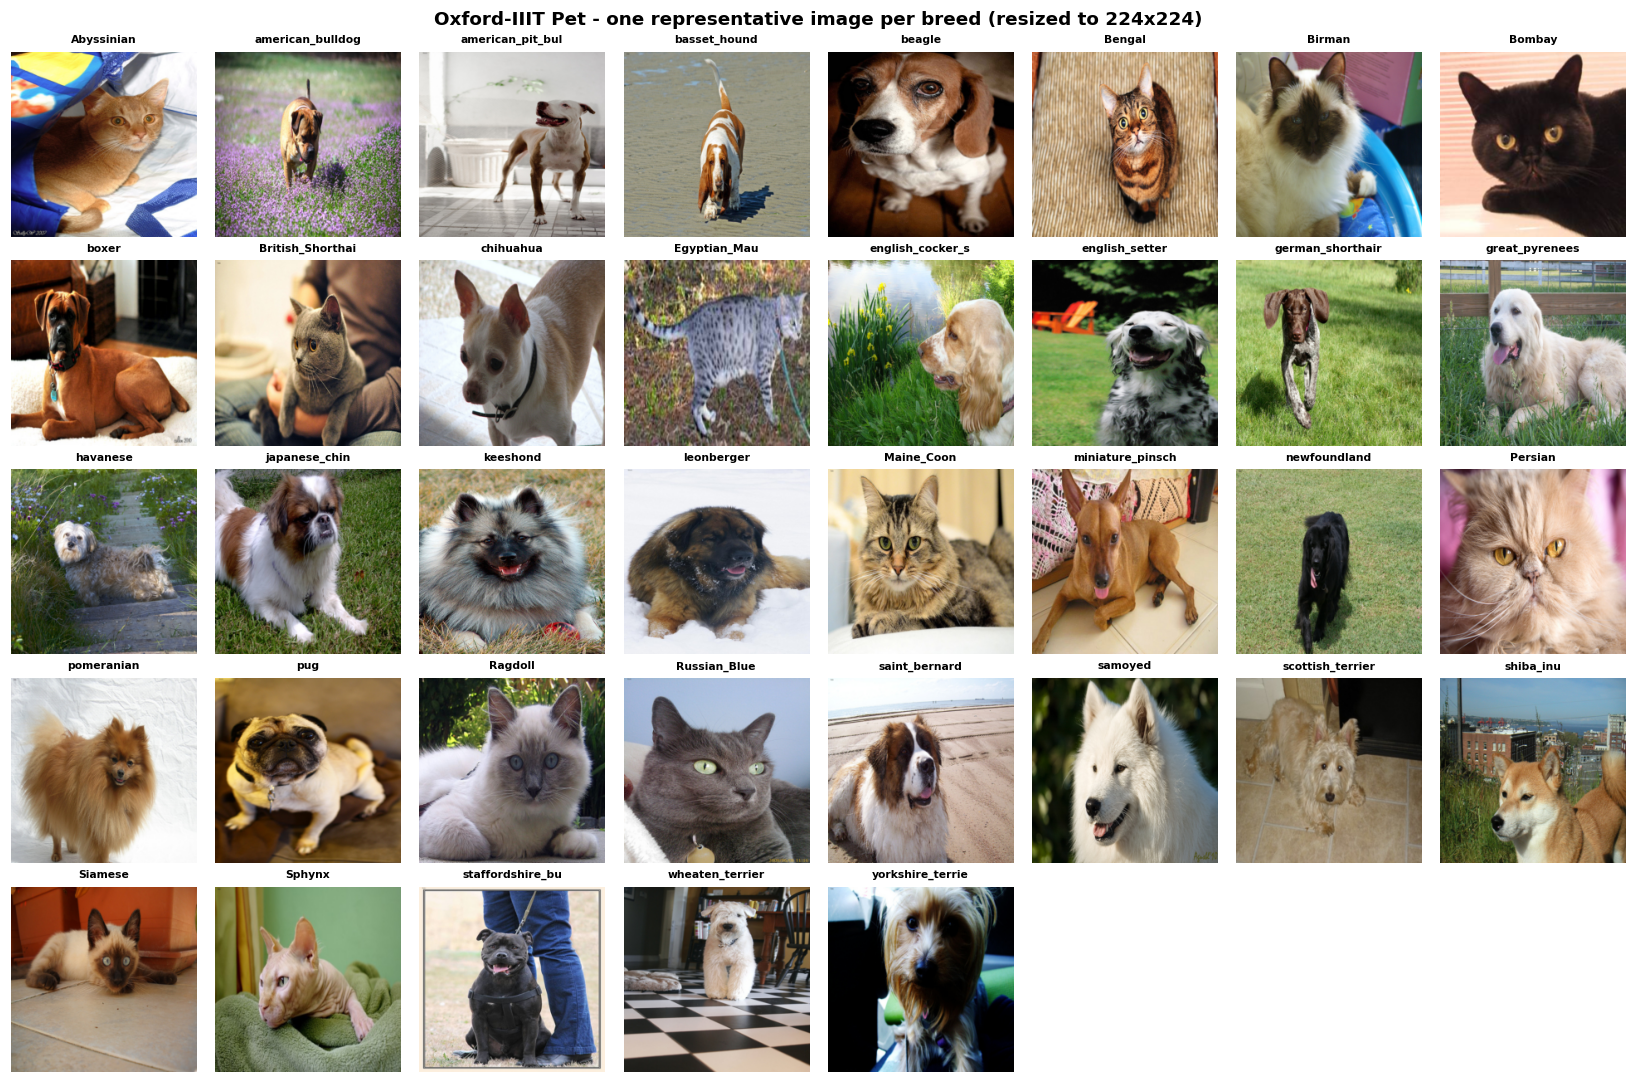

In [4]:
# ---- visual sanity check : one sample per class ----------------------------
fig, axes = plt.subplots(5, 8, figsize=(15, 10))
for k, ax in enumerate(axes.ravel()):
    ax.axis("off")
    if k < NUM_CLASSES:
        j = int(np.where(y_pool == k)[0][0])
        ax.imshow(X_pool_img[j]); ax.set_title(CLASS_NAMES[k][:16], fontsize=7)
fig.suptitle("Oxford-IIIT Pet - one representative image per breed (resized to 224x224)",
             fontweight="bold")
save_show(fig, "00_sample_images")

---
# Part 2 - MobileNetV2 Architecture (Doc Section 4)

MobileNetV2 is a lightweight CNN designed to reduce computational complexity while keeping a good image representation. Its important components are:

- **depthwise convolution** - one `k x k` filter *per input channel* (no cross-channel mixing);
- **pointwise 1x1 convolution** - mixes channels, no spatial extent;
- **inverted residual blocks** - expand -> depthwise -> project, with a skip connection;
- **linear bottlenecks** - no ReLU on the narrow projection output (ReLU destroys information in low dimensions);
- **batch normalization** after every convolution; and
- **ReLU6** activation, `min(max(0, x), 6)`, which is quantisation friendly.

Simplified conceptual pipeline (as given in the document):

```
Input 224x224x3 -> Conv -> Depthwise Conv -> Pointwise Conv -> Residual Block
                -> Global Avg. Pooling -> Dense -> Softmax
```

The cell below inspects the real architecture, counts each layer type, and verifies the cost saving of depthwise separable convolution numerically.

In [5]:
# ============================================================================
# Part 2 : inspect MobileNetV2, convolution arithmetic, cost of DW-separable
# ============================================================================
banner("MOBILENETV2 (ImageNet weights, include_top=False)")

base_probe = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), include_top=False, weights="imagenet")

n_total = base_probe.count_params()
n_layers = len(base_probe.layers)
from collections import Counter
kinds = Counter(type(l).__name__ for l in base_probe.layers)

print("Total layers      :", n_layers)
print("Total parameters  : {:,}".format(n_total))
print("Output shape      :", base_probe.output_shape, " -> 7x7x1280 feature map")
print("\nLayer-type census :")
for k, v in kinds.most_common():
    print("   %-28s %d" % (k, v))

print("\nFirst 12 layers of MobileNetV2 :")
for l in base_probe.layers[:12]:
    print("   %-28s %-22s params=%d" % (l.name, str(l.output.shape), l.count_params()))

print("\nLast 8 layers of MobileNetV2 :")
for l in base_probe.layers[-8:]:
    print("   %-28s %-22s params=%d" % (l.name, str(l.output.shape), l.count_params()))


MOBILENETV2 (ImageNet weights, include_top=False)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers      : 154
Total parameters  : 2,257,984
Output shape      : (None, 7, 7, 1280)  -> 7x7x1280 feature map

Layer-type census :
   BatchNormalization           52
   Conv2D                       35
   ReLU                         35
   DepthwiseConv2D              17
   Add                          10
   ZeroPadding2D                4
   InputLayer                   1

First 12 layers of MobileNetV2 :
   input_layer                  (None, 224, 224, 3)    params=0
   Conv1                        (None, 112, 112, 32)   params=864
   bn_Conv1                     (None, 112, 112, 32)   params=128
   Conv1_relu                   (None, 112, 112, 32)   params=0
   expanded_conv_depthwise      (None, 112, 112, 32)   params=288
   expanded_conv_depthwise_BN   (None, 112, 112, 32)   params=128
   expanded_conv_depthwise_relu (None, 112, 112, 32)   params=0
   expanded_conv_project    

In [6]:
# ---- convolution output-size arithmetic (doc section 9) --------------------
#      O = floor( (N + 2P - K) / S ) + 1
def conv_out(N, K, P, S):
    return math.floor((N + 2 * P - K) / S) + 1

banner("CONVOLUTION OUTPUT DIMENSION :  O = floor((N + 2P - K)/S) + 1")
rows = []
for (N, K, P, S, note) in [
    (224, 3, 0, 1, "3x3, valid padding, stride 1"),
    (224, 3, 1, 1, "3x3, same padding,  stride 1  (size preserved)"),
    (224, 3, 1, 2, "3x3, same padding,  stride 2  (down-sample x2)"),
    (224, 5, 2, 1, "5x5, same padding,  stride 1"),
    (224, 7, 3, 2, "7x7, stride 2  (MobileNetV2-style stem)"),
    (112, 3, 1, 2, "3x3 depthwise, stride 2"),
    (56,  1, 0, 1, "1x1 pointwise (spatial size unchanged)"),
    (14,  2, 0, 2, "2x2 max-pooling, stride 2"),
]:
    rows.append([N, K, P, S, conv_out(N, K, P, S), note])
show_table("Effect of kernel size K, padding P and stride S",
           ["N", "K", "P", "S", "O", "meaning"], rows)

print("""
Reading of the table
  - kernel size K : larger K -> larger receptive field but smaller output and more FLOPs
  - padding    P  : P = (K-1)/2 with S=1 gives 'same' padding, the spatial size is preserved
  - stride     S  : S = 2 halves the spatial resolution, which is how MobileNetV2 down-samples
  - pooling       : 2x2 / stride 2 pooling also halves resolution but has no learnable weights
""")


CONVOLUTION OUTPUT DIMENSION :  O = floor((N + 2P - K)/S) + 1

Effect of kernel size K, padding P and stride S
---  -  -  -  ---  ----------------------------------------------
N    K  P  S  O    meaning                                       
---  -  -  -  ---  ----------------------------------------------
224  3  0  1  222  3x3, valid padding, stride 1                  
224  3  1  1  224  3x3, same padding,  stride 1  (size preserved)
224  3  1  2  112  3x3, same padding,  stride 2  (down-sample x2)
224  5  2  1  224  5x5, same padding,  stride 1                  
224  7  3  2  112  7x7, stride 2  (MobileNetV2-style stem)       
112  3  1  2  56   3x3 depthwise, stride 2                       
56   1  0  1  56   1x1 pointwise (spatial size unchanged)        
14   2  0  2  7    2x2 max-pooling, stride 2                     
---  -  -  -  ---  ----------------------------------------------

Reading of the table
  - kernel size K : larger K -> larger receptive field but smaller output 


STANDARD CONVOLUTION vs DEPTHWISE SEPARABLE CONVOLUTION

Parameter / FLOP saving of depthwise separable convolution (K = 3)
-----------  ---  ----  ----------  -------------  ------------  -----------
feature map  Cin  Cout  std params  dw-sep params  param saving  FLOP saving
-----------  ---  ----  ----------  -------------  ------------  -----------
112x112      32   64    18,432      2,336          7.9x          7.9x       
56x56        128  128   147,456     17,536         8.4x          8.4x       
28x28        256  256   589,824     67,840         8.7x          8.7x       
14x14        512  512   2,359,296   266,752        8.8x          8.8x       
7x7          960  320   2,764,800   315,840        8.8x          8.8x       
-----------  ---  ----  ----------  -------------  ------------  -----------

Theoretical ratio :   (K*K*Cin + Cin*Cout) / (K*K*Cin*Cout)  =  1/Cout + 1/K^2
For K = 3 and a large Cout this tends to 1/9, i.e. roughly a 8-9x reduction.
This is exactly why Mobil

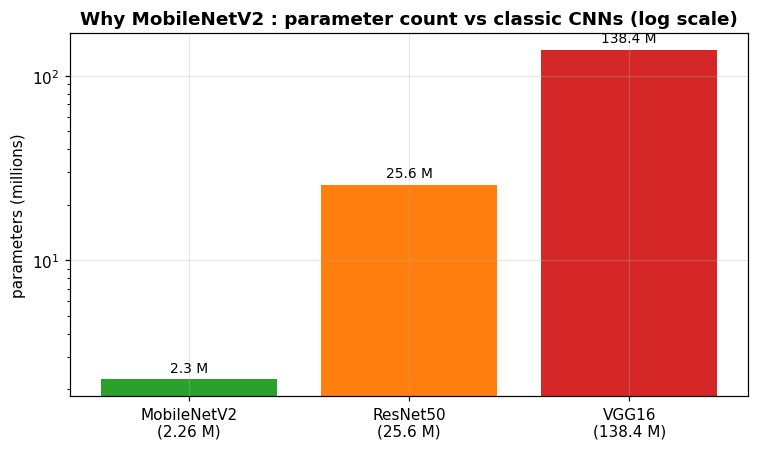


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Parameter counts of MobileNetV2 against two classic ImageNet CNNs.
2. Trend observed      : MobileNetV2 needs ~11x fewer parameters than ResNet50 and ~61x fewer than VGG16.
3. Why it occurs       : Depthwise separable convolution factorises a KxKxCinxCout kernel into a KxKxCin depthwise part plus a 1x1xCinxCout pointwise part, cutting cost by about 1/K^2.
----------------------------------------------------------------------------


In [7]:
# ---- why MobileNetV2 is cheap : standard vs depthwise-separable conv -------
banner("STANDARD CONVOLUTION vs DEPTHWISE SEPARABLE CONVOLUTION")

def std_conv_cost(H, W, Cin, Cout, K):
    params = K * K * Cin * Cout
    flops  = H * W * params
    return params, flops

def dw_sep_cost(H, W, Cin, Cout, K):
    dw_p = K * K * Cin            # depthwise : one KxK filter per channel
    pw_p = 1 * 1 * Cin * Cout     # pointwise : 1x1 channel mixing
    params = dw_p + pw_p
    flops  = H * W * params
    return params, flops

rows = []
for (H, W, Cin, Cout, K) in [(112, 112, 32, 64, 3), (56, 56, 128, 128, 3),
                             (28, 28, 256, 256, 3), (14, 14, 512, 512, 3),
                             (7, 7, 960, 320, 3)]:
    sp, sf = std_conv_cost(H, W, Cin, Cout, K)
    dp, df = dw_sep_cost(H, W, Cin, Cout, K)
    rows.append(["%dx%d" % (H, W), Cin, Cout, "{:,}".format(sp), "{:,}".format(dp),
                 "%.1fx" % (sp / dp), "%.1fx" % (sf / df)])
show_table("Parameter / FLOP saving of depthwise separable convolution (K = 3)",
           ["feature map", "Cin", "Cout", "std params", "dw-sep params",
            "param saving", "FLOP saving"], rows)

print("""
Theoretical ratio :   (K*K*Cin + Cin*Cout) / (K*K*Cin*Cout)  =  1/Cout + 1/K^2
For K = 3 and a large Cout this tends to 1/9, i.e. roughly a 8-9x reduction.
This is exactly why MobileNetV2 has only ~2.26 M parameters versus ~138 M for VGG16,
which makes it usable on CPU-based laboratory hardware.""")

vgg_params = 138_357_544
fig, ax = plt.subplots(figsize=(7, 4.2))
names = ["MobileNetV2\n(2.26 M)", "ResNet50\n(25.6 M)", "VGG16\n(138.4 M)"]
vals  = [n_total / 1e6, 25.6, vgg_params / 1e6]
bars = ax.bar(names, vals, color=[PALETTE[2], PALETTE[3], PALETTE[1]])
ax.set_ylabel("parameters (millions)"); ax.set_yscale("log")
ax.set_title("Why MobileNetV2 : parameter count vs classic CNNs (log scale)")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.1, "%.1f M" % v, ha="center", fontsize=9)
save_show(fig, "01_mobilenetv2_params")

inference(
    "Parameter counts of MobileNetV2 against two classic ImageNet CNNs.",
    "MobileNetV2 needs ~11x fewer parameters than ResNet50 and ~61x fewer than VGG16.",
    "Depthwise separable convolution factorises a KxKxCinxCout kernel into a KxKxCin "
    "depthwise part plus a 1x1xCinxCout pointwise part, cutting cost by about 1/K^2.")

del base_probe
tf.keras.backend.clear_session()

---
# Part 3 setup - Frozen-Base Feature Cache

Doc sections 5-9 (initialization, regularization, batch normalization, optimizers, hyperparameters) require **dozens of controlled training runs**, and doc section 9 states the *experimental rule*: **change one hyperparameter at a time while keeping everything else fixed**.

Running 50+ full 224x224 CNN trainings is not feasible in a lab session. Because all of those studies are performed in the **feature-extraction regime** (Case A of doc section 10 - the pretrained convolutional base is **frozen**), the frozen base produces exactly the same 1280-dimensional Global-Average-Pooled feature for an image every time. We therefore compute those features **once** and train the classification head on the cached features.

This is mathematically identical to training the full model with a frozen base (without augmentation), and it makes each controlled run take about a second instead of a minute.

Full end-to-end 224x224 models are still trained in **Part 8 (transfer learning / fine-tuning)**, **Part 10 (final model)** and **Part 13 (additional exercise)**, where the base is unfrozen and the cache no longer applies.

In [8]:
# ============================================================================
# Part 3 setup : cache the frozen MobileNetV2 GAP features (1280-d)
# ============================================================================
def build_base(trainable=False):
    """ImageNet MobileNetV2 without the classifier head."""
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), include_top=False, weights="imagenet")
    base.trainable = trainable
    return base

def build_feature_extractor():
    """224x224 uint8-scale input -> [-1,1] rescaling -> MobileNetV2 -> GAP(1280)."""
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    # MobileNetV2 preprocessing is exactly x/127.5 - 1  -> range [-1, 1]
    x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0)(inp)
    base = build_base(trainable=False)
    x = base(x, training=False)
    out = tf.keras.layers.GlobalAveragePooling2D()(x)
    return tf.keras.Model(inp, out, name="mobilenetv2_feature_extractor")

banner("EXTRACTING AND CACHING FROZEN MOBILENETV2 FEATURES")
set_seeds()
feat_model = build_feature_extractor()
FEAT_DIM = feat_model.output_shape[-1]
BASE_PARAMS = feat_model.count_params()      # frozen MobileNetV2 parameters
print("Feature dimension :", FEAT_DIM)
print("Frozen base params: {:,}".format(BASE_PARAMS))

def extract(X_img, name, bs=64):
    t0 = time.time()
    F = feat_model.predict(X_img, batch_size=bs, verbose=0).astype(np.float32)
    print("  %-14s -> %s  (%.1fs)" % (name, str(F.shape), time.time() - t0))
    return F

F_pool = extract(X_pool_img, "training pool")
F_test = extract(X_test_img, "test set")
F_tr, F_va = F_pool[idx_tr], F_pool[idx_va]

print("\nCached feature memory : %.1f MB" % ((F_pool.nbytes + F_test.nbytes) / 1e6))
print("Feature statistics    : mean %.3f  std %.3f  min %.3f  max %.3f"
      % (F_pool.mean(), F_pool.std(), F_pool.min(), F_pool.max()))


EXTRACTING AND CACHING FROZEN MOBILENETV2 FEATURES
Feature dimension : 1280
Frozen base params: 2,257,984
  training pool  -> (3680, 1280)  (98.0s)
  test set       -> (3669, 1280)  (97.6s)

Cached feature memory : 37.6 MB
Feature statistics    : mean 0.311  std 0.508  min 0.000  max 5.529


In [9]:
# ============================================================================
# Shared helpers : initializers, optimizers, classification head, train loop
# ============================================================================
def get_initializer(name, seed=SEED):
    """Doc section 5 : the four initialization strategies to be investigated."""
    return {
        "Zero":            tf.keras.initializers.Zeros(),
        "Random":          tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0, seed=seed),
        "Xavier/Glorot":   tf.keras.initializers.GlorotUniform(seed=seed),
        "He":              tf.keras.initializers.HeNormal(seed=seed),
    }[name]

def get_optimizer(name, lr):
    """Doc section 8 : SGD, Momentum, RMSProp, Adam."""
    name = name.lower()
    if name == "sgd":      return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.0)
    if name == "momentum": return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=False)
    if name == "rmsprop":  return tf.keras.optimizers.RMSprop(learning_rate=lr, rho=0.9)
    if name == "adam":     return tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)
    raise ValueError("unknown optimizer " + name)

def make_head(input_dim=None, hidden=256, init="He", dropout=0.0, l2reg=0.0,
              use_bn=False, num_classes=None, seed=SEED):
    """
    Classification head placed on top of the frozen MobileNetV2 features.
        Dense(hidden) -> [BatchNorm] -> ReLU -> [Dropout] -> Dense(37) -> Softmax
    A hidden layer is deliberately included so that the symmetry problem of
    Zero initialization becomes visible (doc discussion question 3).
    """
    input_dim   = FEAT_DIM if input_dim is None else input_dim
    num_classes = NUM_CLASSES if num_classes is None else num_classes
    reg = tf.keras.regularizers.l2(l2reg) if l2reg > 0 else None

    inp = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(hidden, use_bias=not use_bn,
                              kernel_initializer=get_initializer(init, seed),
                              kernel_regularizer=reg, name="fc1")(inp)
    if use_bn:
        x = tf.keras.layers.BatchNormalization(name="bn1")(x)
    x = tf.keras.layers.Activation("relu", name="relu1")(x)
    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout, seed=seed, name="drop1")(x)
    x = tf.keras.layers.Dense(num_classes, kernel_initializer=get_initializer(init, seed + 1),
                              kernel_regularizer=reg, name="logits")(x)
    out = tf.keras.layers.Activation("softmax", dtype="float32", name="softmax")(x)
    return tf.keras.Model(inp, out)

def train_head(Xtr, ytr, Xva, yva, epochs=None, batch_size=BATCH_SIZE,
               optimizer="adam", lr=BASE_LR, verbose=0, **head_kw):
    """Train one classification head on cached features and return its history."""
    epochs = EPOCHS_HEAD if epochs is None else epochs
    tf.keras.backend.clear_session(); set_seeds()
    model = make_head(**head_kw)
    model.compile(optimizer=get_optimizer(optimizer, lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs,
                     batch_size=batch_size, verbose=verbose, shuffle=True)
    return model, hist.history, time.time() - t0

def epoch_to_converge(val_acc, tol=0.99):
    """First epoch (1-indexed) reaching `tol` x best validation accuracy."""
    best = max(val_acc)
    for i, v in enumerate(val_acc):
        if v >= tol * best:
            return i + 1
    return len(val_acc)

# quick smoke test of the pipeline
_m, _h, _t = train_head(F_tr, y_tr, F_va, y_va, epochs=3, verbose=0)
print("Pipeline smoke test  ->  val_acc after 3 epochs = %.2f %%   (%.1fs)"
      % (100 * _h["val_accuracy"][-1], _t))
BASELINE_QUICK = 100 * _h["val_accuracy"][-1]

Pipeline smoke test  ->  val_acc after 3 epochs = 87.77 %   (3.1s)


---
# Part 3 - Weight Initialization (Doc Section 5)

Weight initialization determines the initial values of the trainable weights before training begins. A suitable initialization improves convergence and prevents vanishing or exploding activations.

The four strategies investigated, all applied to the classification head (the frozen base keeps its ImageNet weights):

| Strategy | Rule | Expected behaviour |
|---|---|---|
| **Zero** | `W = 0` | all hidden units compute the same thing -> **symmetry is never broken**, the hidden layer receives zero gradient and never learns |
| **Random** | `W ~ N(0, 1)` | symmetry is broken but the variance is far too large -> **exploding activations**, unstable / very noisy loss |
| **Xavier / Glorot** | `Var(W) = 2 / (fan_in + fan_out)` | keeps forward and backward variance balanced; derived for **symmetric (tanh/sigmoid)** activations |
| **He** | `Var(W) = 2 / fan_in` | the extra factor 2 compensates for ReLU zeroing half the activations -> best for **ReLU** networks |

**Controlled setting** (everything except the initializer is held fixed): Adam, lr = 0.001, batch = 32, no dropout, no L2, no BN, hidden = 256.

In [10]:
# ============================================================================
# Part 3 : weight initialization study  ->  Plot 1 and Plot 2
# ============================================================================
banner("SECTION 5 : WEIGHT INITIALIZATION STUDY")
INIT_METHODS = ["Zero", "Random", "Xavier/Glorot", "He"]
init_hist, init_rows = {}, []

for i, init in enumerate(INIT_METHODS):
    print("  training with %-16s initialization ..." % init, end=" ")
    _, h, t = train_head(F_tr, y_tr, F_va, y_va,
                         optimizer="adam", lr=BASE_LR, batch_size=BATCH_SIZE,
                         init=init, dropout=0.0, l2reg=0.0, use_bn=False)
    init_hist[init] = h
    best = 100 * max(h["val_accuracy"])
    init_rows.append([init, "%.4f" % h["loss"][-1], "%.2f" % best,
                      epoch_to_converge(h["val_accuracy"]), "%.1f" % t])
    print("best val acc = %.2f %%   (%.1fs)" % (best, t))

show_table("Weight initialization summary",
           ["Initialization", "Final train loss", "Best val acc (%)",
            "Epoch to converge", "Time (s)"], init_rows)
RESULTS["init"] = init_rows
BEST_INIT = max(INIT_METHODS, key=lambda k: max(init_hist[k]["val_accuracy"]))
print("\nBest initialization :", BEST_INIT)


SECTION 5 : WEIGHT INITIALIZATION STUDY
  training with Zero             initialization ... best val acc = 2.72 %   (13.6s)
  training with Random           initialization ... best val acc = 74.18 %   (13.3s)
  training with Xavier/Glorot    initialization ... best val acc = 91.03 %   (13.3s)
  training with He               initialization ... best val acc = 91.71 %   (13.2s)

Weight initialization summary
--------------  ----------------  ----------------  -----------------  --------
Initialization  Final train loss  Best val acc (%)  Epoch to converge  Time (s)
--------------  ----------------  ----------------  -----------------  --------
Zero            3.6112            2.72              1                  13.6    
Random          0.0859            74.18             14                 13.3    
Xavier/Glorot   0.0010            91.03             9                  13.3    
He              0.0010            91.71             12                 13.2    
--------------  -------------

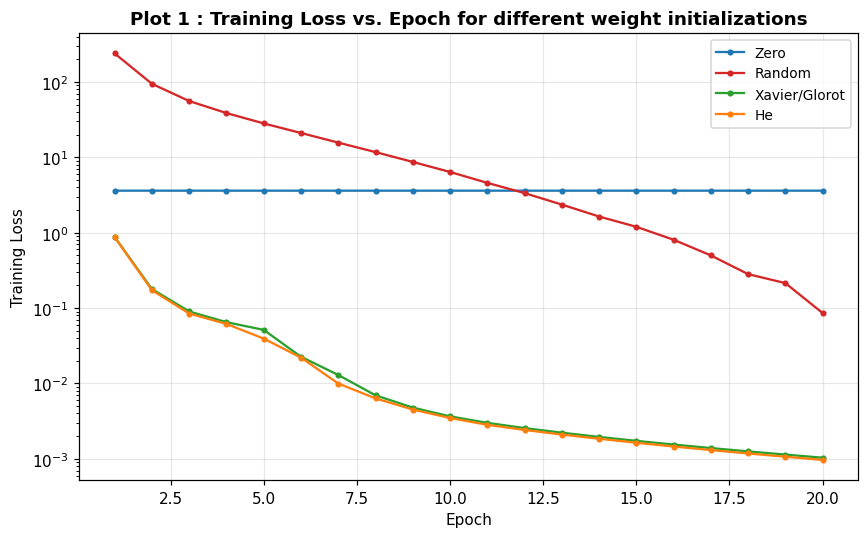


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Training-loss trajectory of the same head trained with four initialization schemes.
2. Trend observed      : He and Xavier fall fastest and lowest; Random(sigma=1) starts orders of magnitude higher and decreases erratically; Zero initialization is essentially flat.
3. Why it occurs       : He/Xavier keep the layer-wise activation variance close to 1 so gradients are well scaled. Large random weights saturate/explode activations. With W=0 every hidden unit is identical, dL/dW1 is proportional to W2 = 0, so the hidden layer never receives a gradient.
----------------------------------------------------------------------------


In [11]:
# ---------------------------- PLOT 1 ---------------------------------------
fig, ax = plt.subplots()
for i, init in enumerate(INIT_METHODS):
    ax.plot(range(1, len(init_hist[init]["loss"]) + 1), init_hist[init]["loss"],
            marker="o", ms=3, color=PALETTE[i], label=init)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss")
ax.set_title("Plot 1 : Training Loss vs. Epoch for different weight initializations")
ax.set_yscale("log"); ax.legend()
save_show(fig, "plot01_init_train_loss")

inference(
    "Training-loss trajectory of the same head trained with four initialization schemes.",
    "He and Xavier fall fastest and lowest; Random(sigma=1) starts orders of magnitude "
    "higher and decreases erratically; Zero initialization is essentially flat.",
    "He/Xavier keep the layer-wise activation variance close to 1 so gradients are well "
    "scaled. Large random weights saturate/explode activations. With W=0 every hidden unit "
    "is identical, dL/dW1 is proportional to W2 = 0, so the hidden layer never receives a gradient.")

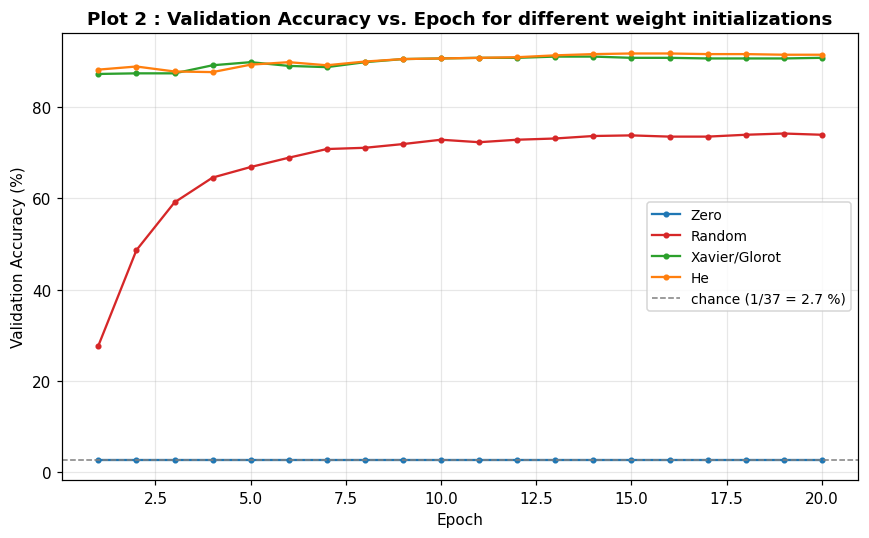


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Validation accuracy per epoch for the four initialization strategies.
2. Trend observed      : He and Xavier converge within a few epochs to the highest accuracy (He marginally faster and smoother), Random is far below and noisy, Zero stays near chance level.
3. Why it occurs       : Variance-scaled initialization gives a well-conditioned starting point; He's factor of 2 exactly compensates for ReLU discarding the negative half, which is why it is the best match for this ReLU head.
----------------------------------------------------------------------------


In [12]:
# ---------------------------- PLOT 2 ---------------------------------------
fig, ax = plt.subplots()
for i, init in enumerate(INIT_METHODS):
    ax.plot(range(1, len(init_hist[init]["val_accuracy"]) + 1),
            100 * np.array(init_hist[init]["val_accuracy"]),
            marker="o", ms=3, color=PALETTE[i], label=init)
ax.axhline(100 * CHANCE, ls="--", c="gray", lw=1, label="chance (1/37 = 2.7 %)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 2 : Validation Accuracy vs. Epoch for different weight initializations")
ax.legend()
save_show(fig, "plot02_init_val_acc")

inference(
    "Validation accuracy per epoch for the four initialization strategies.",
    "He and Xavier converge within a few epochs to the highest accuracy (He marginally "
    "faster and smoother), Random is far below and noisy, Zero stays near chance level.",
    "Variance-scaled initialization gives a well-conditioned starting point; He's factor "
    "of 2 exactly compensates for ReLU discarding the negative half, which is why it is "
    "the best match for this ReLU head.")

### Inference for Plots 1 and 2 (Doc Section 14)

1. **What the plots show** - the training loss and validation accuracy of an identical MobileNetV2 head trained under Zero, Random, Xavier/Glorot and He initialization, with every other hyperparameter held fixed.
2. **Trend observed** - He and Xavier converge fastest and reach the highest, most stable validation accuracy; large-variance Random initialization converges slowly and noisily; Zero initialization never leaves chance accuracy (~2.7 %).
3. **Why** - Zero initialization makes all hidden units identical, so the symmetry is never broken and the hidden-layer gradient is exactly zero; `N(0,1)` weights blow up the pre-activation variance and produce huge, noisy gradients; Xavier and He keep the activation/gradient variance approximately constant across layers, and He's `2/fan_in` scaling is the correct one for ReLU.

**Conclusion:** *He initialization* gives the fastest and most stable convergence and is used for the rest of the experiment.

---
# Part 4 - Regularization and Overfitting (Doc Section 6)

Overfitting occurs when a model performs very well on the training data but generalizes poorly to unseen data. The **generalization gap** is `train accuracy - validation accuracy`.

Four settings are compared, again **one change at a time** (He init, Adam, lr = 0.001, batch = 32):

| Variant | Change |
|---|---|
| No regularization | plain `Dense(256) -> ReLU -> Dense(37)` |
| L2 regularization | `l2 = 1e-3` penalty on both kernels (weight decay) |
| Dropout | `Dropout(0.5)` after the ReLU |
| Batch Normalization | `BatchNormalization` between `Dense(256)` and ReLU |

In [13]:
# ============================================================================
# Part 4 : regularization study  ->  Plot 3 and Plot 4
# ============================================================================
banner("SECTION 6 : REGULARIZATION AND OVERFITTING")
REG_VARIANTS = {
    "No regularization":   dict(dropout=0.0, l2reg=0.0,  use_bn=False),
    "L2 (1e-3)":           dict(dropout=0.0, l2reg=1e-3, use_bn=False),
    "Dropout (0.5)":       dict(dropout=0.5, l2reg=0.0,  use_bn=False),
    "Batch Normalization": dict(dropout=0.0, l2reg=0.0,  use_bn=True),
}
reg_hist, reg_rows = {}, []

for name, kw in REG_VARIANTS.items():
    print("  training : %-22s ..." % name, end=" ")
    _, h, t = train_head(F_tr, y_tr, F_va, y_va, optimizer="adam", lr=BASE_LR,
                         batch_size=BATCH_SIZE, init=BEST_INIT, **kw)
    reg_hist[name] = h
    gap = 100 * (h["accuracy"][-1] - h["val_accuracy"][-1])
    best = 100 * max(h["val_accuracy"])
    # epoch at which validation loss reaches its minimum -> onset of overfitting
    ov = int(np.argmin(h["val_loss"])) + 1
    reg_rows.append([name, "%.2f" % (100 * h["accuracy"][-1]), "%.2f" % (100 * h["val_accuracy"][-1]),
                     "%.2f" % best, "%.2f" % gap, ov, "%.1f" % t])
    print("val acc %.2f %%  gap %.2f pp" % (best, gap))

show_table("Regularization summary (gap = final train acc - final val acc)",
           ["Variant", "Train acc (%)", "Val acc (%)", "Best val acc (%)",
            "Gen. gap (pp)", "Best val-loss epoch", "Time (s)"], reg_rows)
RESULTS["reg"] = reg_rows
BEST_REG = max(REG_VARIANTS, key=lambda k: max(reg_hist[k]["val_accuracy"]))
LOWEST_GAP = min(REG_VARIANTS,
                 key=lambda k: reg_hist[k]["accuracy"][-1] - reg_hist[k]["val_accuracy"][-1])
print("\nHighest validation accuracy :", BEST_REG)
print("Smallest generalization gap :", LOWEST_GAP)


SECTION 6 : REGULARIZATION AND OVERFITTING
  training : No regularization      ... val acc 91.71 %  gap 8.56 pp
  training : L2 (1e-3)              ... val acc 91.03 %  gap 10.97 pp
  training : Dropout (0.5)          ... val acc 91.03 %  gap 8.87 pp
  training : Batch Normalization    ... val acc 91.71 %  gap 8.83 pp

Regularization summary (gap = final train acc - final val acc)
-------------------  -------------  -----------  ----------------  -------------  -------------------  --------
Variant              Train acc (%)  Val acc (%)  Best val acc (%)  Gen. gap (pp)  Best val-loss epoch  Time (s)
-------------------  -------------  -----------  ----------------  -------------  -------------------  --------
No regularization    100.00         91.44        91.71             8.56           9                    13.6    
L2 (1e-3)            97.25          86.28        91.03             10.97          17                   14.7    
Dropout (0.5)        99.22          90.35        91.03 

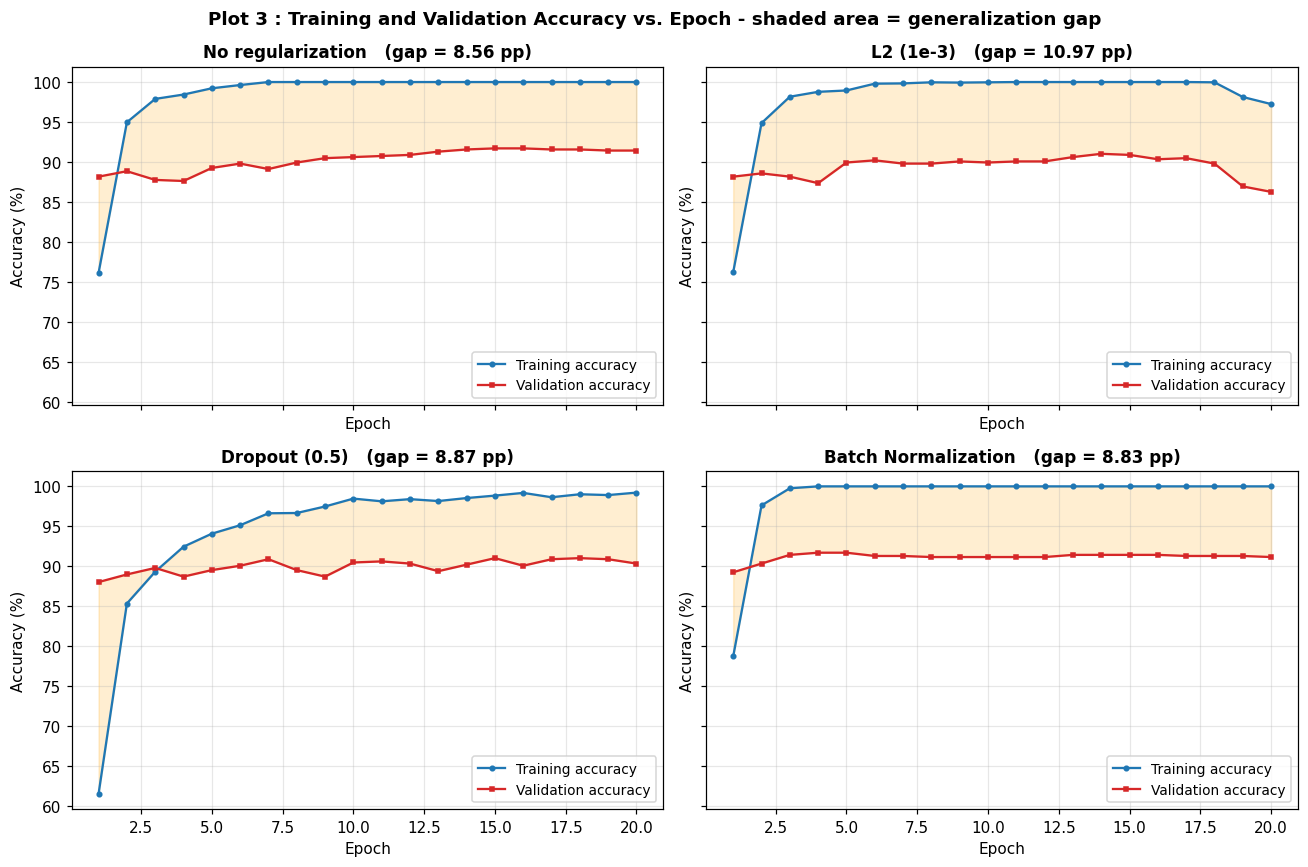


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Training vs. validation accuracy for four regularization settings; the shaded band is the generalization gap.
2. Trend observed      : The unregularized head drives training accuracy towards 100 % while validation accuracy saturates, giving the widest band. Dropout and L2 keep the two curves much closer; BN converges fastest but with an intermediate gap.
3. Why it occurs       : Dropout injects multiplicative noise and forces redundant features, L2 shrinks the weights and limits the effective capacity, so both reduce memorisation of the training set. BN mainly stabilises and accelerates optimisation and only mildly regularises.
----------------------------------------------------------------------------


In [14]:
# ---------------------------- PLOT 3 ---------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (name, h) in zip(axes.ravel(), reg_hist.items()):
    ep = range(1, len(h["accuracy"]) + 1)
    ax.plot(ep, 100 * np.array(h["accuracy"]), color=PALETTE[0], marker="o", ms=3,
            label="Training accuracy")
    ax.plot(ep, 100 * np.array(h["val_accuracy"]), color=PALETTE[1], marker="s", ms=3,
            label="Validation accuracy")
    ax.fill_between(ep, 100 * np.array(h["val_accuracy"]), 100 * np.array(h["accuracy"]),
                    color="orange", alpha=.18)
    gap = 100 * (h["accuracy"][-1] - h["val_accuracy"][-1])
    ax.set_title("%s   (gap = %.2f pp)" % (name, gap), fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.legend(loc="lower right")
fig.suptitle("Plot 3 : Training and Validation Accuracy vs. Epoch - shaded area = generalization gap",
             fontweight="bold")
save_show(fig, "plot03_reg_accuracy")

inference(
    "Training vs. validation accuracy for four regularization settings; the shaded band "
    "is the generalization gap.",
    "The unregularized head drives training accuracy towards 100 % while validation "
    "accuracy saturates, giving the widest band. Dropout and L2 keep the two curves much "
    "closer; BN converges fastest but with an intermediate gap.",
    "Dropout injects multiplicative noise and forces redundant features, L2 shrinks the "
    "weights and limits the effective capacity, so both reduce memorisation of the training "
    "set. BN mainly stabilises and accelerates optimisation and only mildly regularises.")

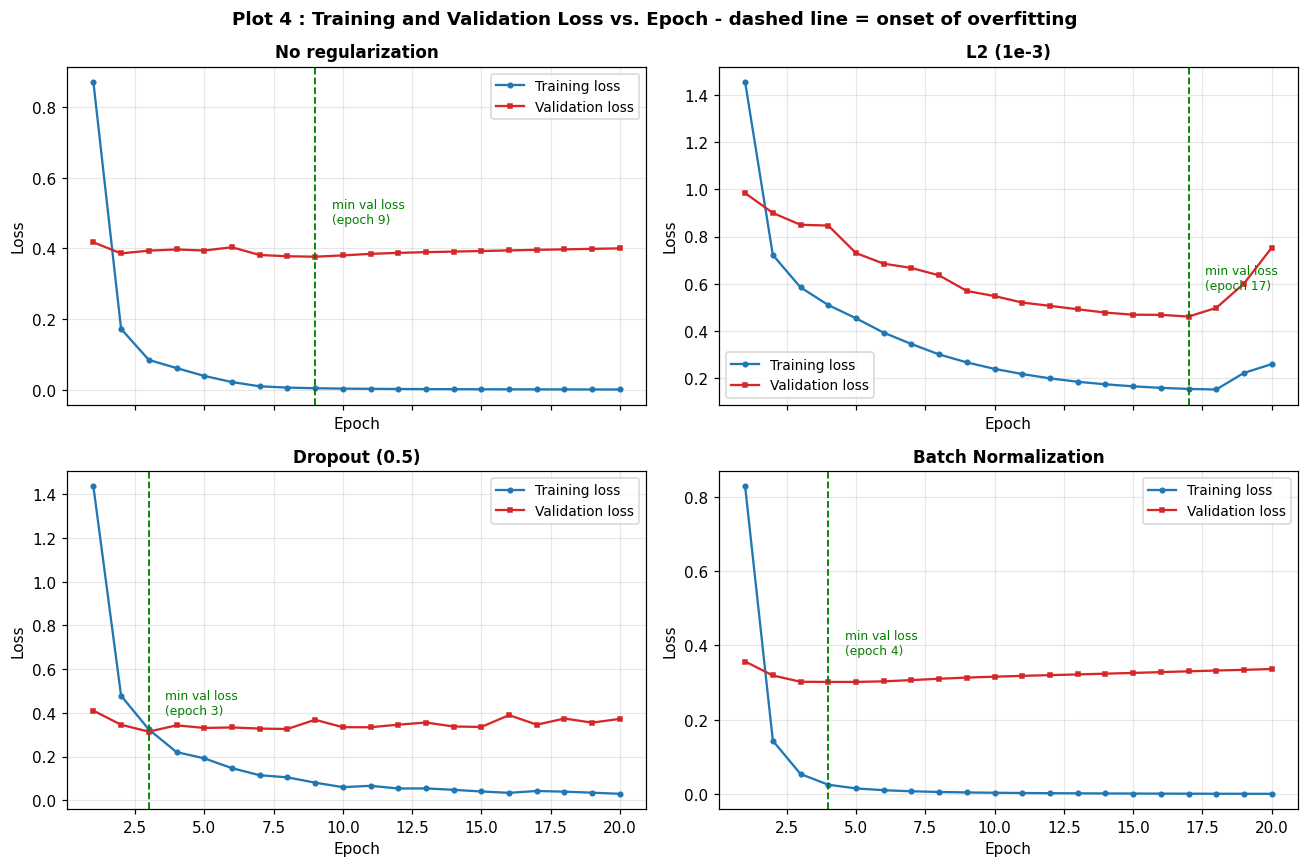


Overfitting check - does validation loss rise while training loss keeps falling?
   No regularization      min val loss at epoch  9, final val loss 0.4002  -> OVERFITTING after that epoch
   L2 (1e-3)              min val loss at epoch 17, final val loss 0.7526  -> OVERFITTING after that epoch
   Dropout (0.5)          min val loss at epoch  3, final val loss 0.3723  -> OVERFITTING after that epoch
   Batch Normalization    min val loss at epoch  4, final val loss 0.3366  -> OVERFITTING after that epoch

--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Training and validation loss per epoch for each regularization variant.
2. Trend observed      : For the unregularized model the training loss keeps falling while the validation loss reaches a minimum and then rises - the classic overfitting signature. With Dropout / L2 the validation loss stays flat or keeps decreasing for far longer.
3. Why it occurs       : Once the model starts fi

In [15]:
# ---------------------------- PLOT 4 ---------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (name, h) in zip(axes.ravel(), reg_hist.items()):
    ep = range(1, len(h["loss"]) + 1)
    ax.plot(ep, h["loss"], color=PALETTE[0], marker="o", ms=3, label="Training loss")
    ax.plot(ep, h["val_loss"], color=PALETTE[1], marker="s", ms=3, label="Validation loss")
    k = int(np.argmin(h["val_loss"]))
    ax.axvline(k + 1, ls="--", c="green", lw=1.2)
    ax.annotate("min val loss\n(epoch %d)" % (k + 1), xy=(k + 1, h["val_loss"][k]),
                xytext=(k + 1.6, h["val_loss"][k] * 1.25), fontsize=8, color="green")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
fig.suptitle("Plot 4 : Training and Validation Loss vs. Epoch - dashed line = onset of overfitting",
             fontweight="bold")
save_show(fig, "plot04_reg_loss")

print("\nOverfitting check - does validation loss rise while training loss keeps falling?")
for name, h in reg_hist.items():
    k = int(np.argmin(h["val_loss"]))
    rising = h["val_loss"][-1] > h["val_loss"][k] * 1.02
    print("   %-22s min val loss at epoch %2d, final val loss %.4f  -> %s"
          % (name, k + 1, h["val_loss"][-1],
             "OVERFITTING after that epoch" if rising else "no clear overfitting"))

inference(
    "Training and validation loss per epoch for each regularization variant.",
    "For the unregularized model the training loss keeps falling while the validation loss "
    "reaches a minimum and then rises - the classic overfitting signature. With Dropout / L2 "
    "the validation loss stays flat or keeps decreasing for far longer.",
    "Once the model starts fitting noise specific to the training images, the extra capacity "
    "helps only the training loss. Regularizers penalise exactly that behaviour, so the "
    "minimum of the validation loss (the correct early-stopping point) is pushed later.")

### Inference for Plots 3 and 4 (Doc Section 14)

1. **What the plots show** - accuracy and loss curves for training and validation under no regularization, L2, Dropout and Batch Normalization.
2. **Trend observed** - without regularization the training curves keep improving while validation stalls, producing the largest generalization gap and a validation loss that turns upward. Dropout gives the smallest gap; L2 is close behind; BN converges fastest but regularizes only mildly.
3. **Why** - the unregularized head has enough capacity to memorise the 2,944 training feature vectors. Dropout randomly removes half the hidden units each step, forcing distributed, redundant representations; L2 shrinks weights and reduces effective capacity; BN normalizes activations, which conditions the optimisation problem rather than restricting capacity.

**How to identify overfitting from the curves:** the moment the *validation loss stops decreasing and starts increasing* while the *training loss keeps decreasing* (green dashed line in Plot 4). The vertical distance between the training and validation accuracy curves in Plot 3 is the generalization gap.

---
# Part 5 - Batch Normalization (Doc Section 7)

For a mini-batch `x1, x2, ..., xm`:

$$\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i , \qquad \sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m}(x_i - \mu_B)^2$$

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y_i = \gamma \hat{x}_i + \beta$$

where `gamma` and `beta` are **learnable** parameters.

### Numerical example from the document
For `x = [2, 4, 6, 8]`:
- `mu_B = (2+4+6+8)/4 = 5`
- `sigma_B^2 = ((2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2)/4 = (9+1+1+9)/4 = 5`
- `sqrt(5) ~= 2.236`
- `x_hat = [-1.342, -0.447, 0.447, 1.342]`

With `gamma = 1` and `beta = 0` these are the final outputs.

**Inference:** Batch Normalization produces approximately zero-centred and unit-scaled activations for this mini-batch. The learnable `gamma` and `beta` allow the network to learn an appropriate scale and shift (and, if needed, to undo the normalization entirely).


SECTION 7 : BATCH NORMALIZATION - NUMERICAL EXAMPLE
x            = [2. 4. 6. 8.]
mu_B         = 5.0000        (document: 5)
sigma_B^2    = 5.0000        (document: 5)
sqrt(var)    = 2.2361        (document: 2.236)
x_hat        = [-1.342 -0.447  0.447  1.342]   (document: [-1.342, -0.447, 0.447, 1.342])

With gamma = 1, beta = 0  ->  y = [-1.342 -0.447  0.447  1.342]
mean(x_hat)  = 0.000000   std(x_hat) = 0.999900   -> zero-centred, unit-scaled

Effect of the learnable parameters:
   gamma= 1.0 beta= 0.0  ->  y = [-1.342 -0.447  0.447  1.342]
   gamma= 2.0 beta= 0.0  ->  y = [-2.683 -0.894  0.894  2.683]
   gamma= 1.0 beta= 3.0  ->  y = [1.658 2.553 3.447 4.342]
   gamma= 0.5 beta=-1.0  ->  y = [-1.671 -1.224 -0.776 -0.329]

Keras BatchNormalization (training mode) : [-1.342 -0.447  0.447  1.342]


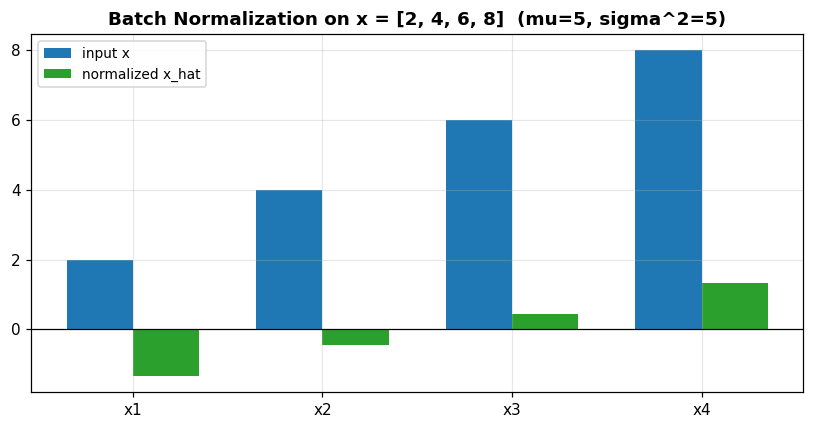

In [16]:
# ============================================================================
# Part 5a : verify the document's Batch Normalization numerical example
# ============================================================================
banner("SECTION 7 : BATCH NORMALIZATION - NUMERICAL EXAMPLE")
x = np.array([2.0, 4.0, 6.0, 8.0]); eps = 1e-3

mu    = x.mean()
var   = ((x - mu) ** 2).mean()          # biased (1/m) variance, as in the paper
x_hat = (x - mu) / np.sqrt(var + eps)

print("x            =", x)
print("mu_B         = %.4f        (document: 5)" % mu)
print("sigma_B^2    = %.4f        (document: 5)" % var)
print("sqrt(var)    = %.4f        (document: 2.236)" % np.sqrt(var))
print("x_hat        =", np.round(x_hat, 3), "  (document: [-1.342, -0.447, 0.447, 1.342])")
print("\nWith gamma = 1, beta = 0  ->  y =", np.round(1.0 * x_hat + 0.0, 3))
print("mean(x_hat)  = %.6f   std(x_hat) = %.6f   -> zero-centred, unit-scaled" %
      (x_hat.mean(), x_hat.std()))

print("\nEffect of the learnable parameters:")
for g, b in [(1.0, 0.0), (2.0, 0.0), (1.0, 3.0), (0.5, -1.0)]:
    print("   gamma=%4.1f beta=%4.1f  ->  y = %s" % (g, b, np.round(g * x_hat + b, 3)))

# same computation with a real Keras BatchNormalization layer
bn = tf.keras.layers.BatchNormalization(epsilon=eps)
y_keras = bn(tf.constant(x.reshape(4, 1), dtype=tf.float32), training=True).numpy().ravel()
print("\nKeras BatchNormalization (training mode) :", np.round(y_keras, 3))

fig, ax = plt.subplots(figsize=(7.5, 4))
w = 0.35; xs = np.arange(4)
ax.bar(xs - w / 2, x, w, label="input x", color=PALETTE[0])
ax.bar(xs + w / 2, x_hat, w, label="normalized x_hat", color=PALETTE[2])
ax.axhline(0, c="k", lw=.8)
ax.set_xticks(xs); ax.set_xticklabels(["x1", "x2", "x3", "x4"])
ax.set_title("Batch Normalization on x = [2, 4, 6, 8]  (mu=5, sigma^2=5)")
ax.legend(); save_show(fig, "05a_bn_numerical_example")


SECTION 7 : WITH vs WITHOUT BATCH NORMALIZATION
  training : Without BN   ... best val acc = 91.71 %  (13.8s)
  training : With BN      ... best val acc = 91.71 %  (14.0s)


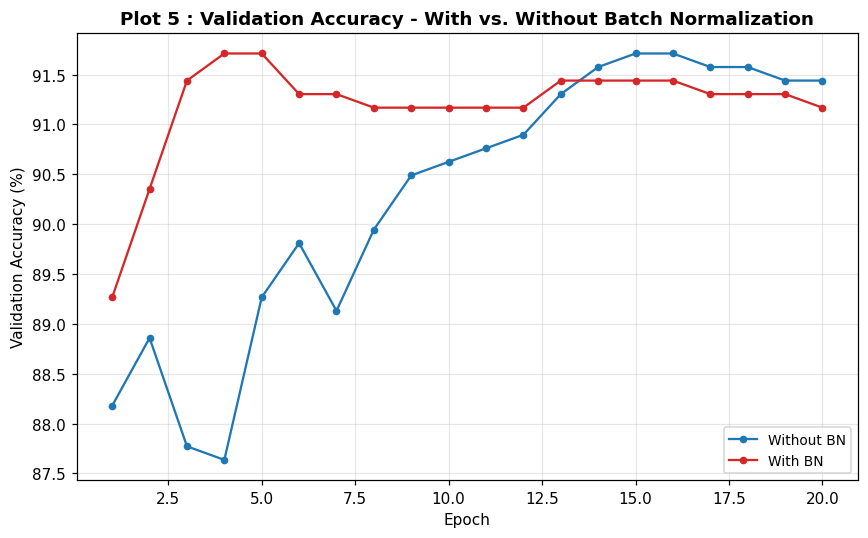


Batch Normalization comparison
----------  ----------------  -----------------  ---------------------
Setting     Best val acc (%)  Epoch to converge  Val acc @ epoch 3 (%)
----------  ----------------  -----------------  ---------------------
Without BN  91.71             12                 87.77                
With BN     91.71             3                  91.44                
----------  ----------------  -----------------  ---------------------

--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Validation accuracy per epoch of the same head with and without a BatchNormalization layer between Dense(256) and ReLU.
2. Trend observed      : The BN curve rises much more steeply in the first few epochs and is visibly smoother; final accuracies end up close, with BN usually slightly ahead.
3. Why it occurs       : BN re-centres and re-scales the pre-activations of every mini-batch, which removes internal covariate shift, keeps the u

In [17]:
# ============================================================================
# Part 5b : with vs without Batch Normalization  ->  Plot 5
# ============================================================================
banner("SECTION 7 : WITH vs WITHOUT BATCH NORMALIZATION")
bn_hist = {}
for name, use_bn in [("Without BN", False), ("With BN", True)]:
    print("  training : %-12s ..." % name, end=" ")
    _, h, t = train_head(F_tr, y_tr, F_va, y_va, optimizer="adam", lr=BASE_LR,
                         batch_size=BATCH_SIZE, init=BEST_INIT, use_bn=use_bn)
    bn_hist[name] = h
    print("best val acc = %.2f %%  (%.1fs)" % (100 * max(h["val_accuracy"]), t))

# ---------------------------- PLOT 5 ---------------------------------------
fig, ax = plt.subplots()
for i, (name, h) in enumerate(bn_hist.items()):
    ax.plot(range(1, len(h["val_accuracy"]) + 1), 100 * np.array(h["val_accuracy"]),
            marker="o", ms=4, color=PALETTE[i], label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 5 : Validation Accuracy - With vs. Without Batch Normalization")
ax.legend(); save_show(fig, "plot05_batchnorm")

rows = [[n, "%.2f" % (100 * max(h["val_accuracy"])),
         epoch_to_converge(h["val_accuracy"]),
         "%.2f" % (100 * h["val_accuracy"][2] if len(h["val_accuracy"]) > 2 else np.nan)]
        for n, h in bn_hist.items()]
show_table("Batch Normalization comparison", ["Setting", "Best val acc (%)",
                                              "Epoch to converge", "Val acc @ epoch 3 (%)"], rows)
RESULTS["bn"] = rows

inference(
    "Validation accuracy per epoch of the same head with and without a "
    "BatchNormalization layer between Dense(256) and ReLU.",
    "The BN curve rises much more steeply in the first few epochs and is visibly smoother; "
    "final accuracies end up close, with BN usually slightly ahead.",
    "BN re-centres and re-scales the pre-activations of every mini-batch, which removes "
    "internal covariate shift, keeps the units in the non-saturating region of ReLU and "
    "smooths the loss surface, allowing effectively larger stable steps.")

### Inference for Plot 5 (Doc Section 14)

1. **What the plot shows** - validation accuracy per epoch for an identical head with and without Batch Normalization.
2. **Trend observed** - BN reaches a high accuracy in noticeably fewer epochs and its curve is smoother; the final accuracies converge to similar values.
3. **Why** - BN normalizes each mini-batch's pre-activations to zero mean and unit variance, which reduces internal covariate shift, conditions the loss surface and lets the optimizer take larger, more stable steps. Its main benefit here is **convergence speed and stability**, not raw final accuracy. `gamma` and `beta` are learned so the network can restore any scale/shift it actually needs (including undoing the normalization).

---
# Part 6 - Optimization Algorithms (Doc Section 8)

| Optimizer | Update rule (idea) | Character |
|---|---|---|
| **SGD** | `w <- w - eta * g` | simplest, needs a well-tuned `eta`, slow in ravines |
| **Momentum** | `v <- beta*v + g ; w <- w - eta*v` | accumulates velocity, damps oscillations, accelerates along consistent directions |
| **RMSProp** | `s <- rho*s + (1-rho)*g^2 ; w <- w - eta*g/sqrt(s)` | per-parameter adaptive step from a running average of squared gradients |
| **Adam** | RMSProp + Momentum + bias correction | adaptive and momentum-driven; strong default |

**Controlled setting:** identical head (He init, no dropout/L2/BN), batch = 32, and the *same* learning rate `0.001` for all four - this is the honest one-variable-at-a-time comparison. Because plain SGD is known to need a larger step, two supplementary rows with `lr = 0.01` are also reported.

In [18]:
# ============================================================================
# Part 6 : optimizer comparison  ->  Plot 6 and Plot 7
# ============================================================================
banner("SECTION 8 : OPTIMIZATION ALGORITHMS")
OPTIMIZERS = ["SGD", "Momentum", "RMSProp", "Adam"]
opt_hist, opt_rows = {}, []

for i, opt in enumerate(OPTIMIZERS):
    print("  training with %-10s (lr=%.4f) ..." % (opt, BASE_LR), end=" ")
    _, h, t = train_head(F_tr, y_tr, F_va, y_va, optimizer=opt, lr=BASE_LR,
                         batch_size=BATCH_SIZE, init=BEST_INIT)
    opt_hist[opt] = h
    best = 100 * max(h["val_accuracy"])
    opt_rows.append([opt, "%.4f" % h["loss"][-1], "%.2f" % best,
                     epoch_to_converge(h["val_accuracy"]), "%.1f" % t])
    print("final loss %.4f | best val acc %.2f %% | %.1fs" % (h["loss"][-1], best, t))

# supplementary : SGD-family at its own suitable learning rate
opt_hist_extra = {}
for opt in ["SGD", "Momentum"]:
    print("  training with %-10s (lr=0.0100) ..." % opt, end=" ")
    _, h, t = train_head(F_tr, y_tr, F_va, y_va, optimizer=opt, lr=1e-2,
                         batch_size=BATCH_SIZE, init=BEST_INIT)
    opt_hist_extra[opt + " (lr=0.01)"] = h
    best = 100 * max(h["val_accuracy"])
    opt_rows.append([opt + " (lr=0.01)", "%.4f" % h["loss"][-1], "%.2f" % best,
                     epoch_to_converge(h["val_accuracy"]), "%.1f" % t])
    print("final loss %.4f | best val acc %.2f %% | %.1fs" % (h["loss"][-1], best, t))

show_table("Doc Section 8 optimizer table",
           ["Optimizer", "Final Loss", "Best Val. Accuracy (%)", "Epoch to Converge", "Time (s)"],
           opt_rows)
RESULTS["opt"] = opt_rows
BEST_OPT = max(OPTIMIZERS, key=lambda k: max(opt_hist[k]["val_accuracy"]))
print("\nBest optimizer at the common learning rate :", BEST_OPT)


SECTION 8 : OPTIMIZATION ALGORITHMS
  training with SGD        (lr=0.0010) ... final loss 0.8497 | best val acc 84.24 % | 10.2s
  training with Momentum   (lr=0.0010) ... final loss 0.1066 | best val acc 89.95 % | 11.3s
  training with RMSProp    (lr=0.0010) ... final loss 0.0001 | best val acc 90.49 % | 12.4s
  training with Adam       (lr=0.0010) ... final loss 0.0010 | best val acc 91.71 % | 13.6s
  training with SGD        (lr=0.0100) ... final loss 0.1060 | best val acc 89.81 % | 10.2s
  training with Momentum   (lr=0.0100) ... final loss 0.0063 | best val acc 91.17 % | 11.6s

Doc Section 8 optimizer table
------------------  ----------  ----------------------  -----------------  --------
Optimizer           Final Loss  Best Val. Accuracy (%)  Epoch to Converge  Time (s)
------------------  ----------  ----------------------  -----------------  --------
SGD                 0.8497      84.24                   19                 10.2    
Momentum            0.1066      89.95       

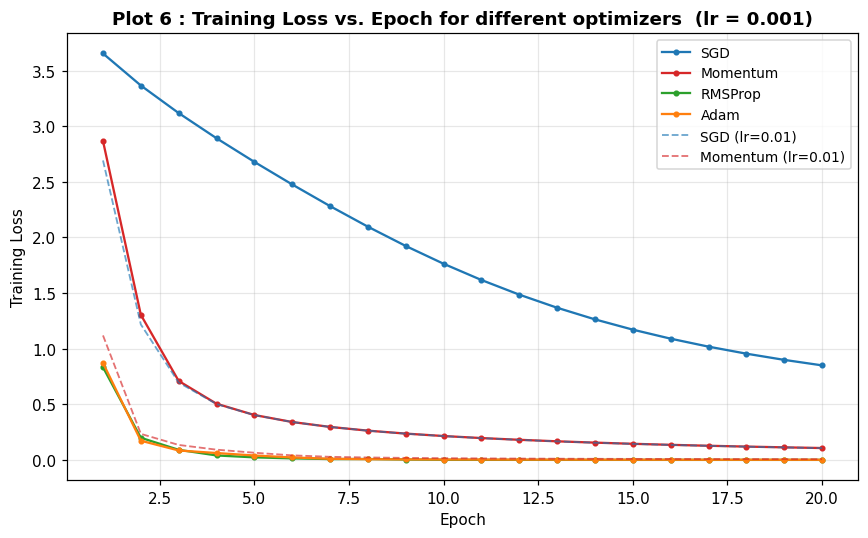


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Training-loss curves of SGD, Momentum, RMSProp and Adam at an identical learning rate.
2. Trend observed      : Adam and RMSProp drop steeply within 2-3 epochs; Momentum is clearly faster than plain SGD, which decreases almost linearly and is far behind after 20 epochs.
3. Why it occurs       : Adaptive methods rescale each coordinate by a running RMS of its gradient, so rarely updated features still get large steps. Momentum accumulates a velocity that cancels oscillations across ravines. Plain SGD applies one global step size, which at lr=0.001 is simply too small for this loss surface.
----------------------------------------------------------------------------


In [19]:
# ---------------------------- PLOT 6 ---------------------------------------
fig, ax = plt.subplots()
for i, opt in enumerate(OPTIMIZERS):
    ax.plot(range(1, len(opt_hist[opt]["loss"]) + 1), opt_hist[opt]["loss"],
            marker="o", ms=3, color=PALETTE[i], label=opt)
for j, (n, h) in enumerate(opt_hist_extra.items()):
    ax.plot(range(1, len(h["loss"]) + 1), h["loss"], ls="--", lw=1.2,
            color=PALETTE[j], alpha=.65, label=n)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss")
ax.set_title("Plot 6 : Training Loss vs. Epoch for different optimizers  (lr = 0.001)")
ax.legend(); save_show(fig, "plot06_optimizer_loss")

inference(
    "Training-loss curves of SGD, Momentum, RMSProp and Adam at an identical learning rate.",
    "Adam and RMSProp drop steeply within 2-3 epochs; Momentum is clearly faster than plain "
    "SGD, which decreases almost linearly and is far behind after 20 epochs.",
    "Adaptive methods rescale each coordinate by a running RMS of its gradient, so rarely "
    "updated features still get large steps. Momentum accumulates a velocity that cancels "
    "oscillations across ravines. Plain SGD applies one global step size, which at lr=0.001 "
    "is simply too small for this loss surface.")

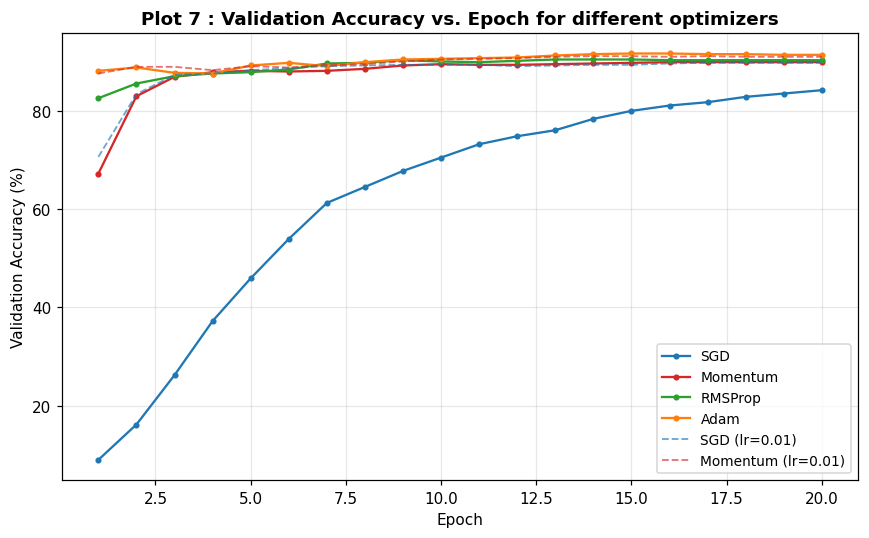


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Validation accuracy per epoch for the four optimizers.
2. Trend observed      : Adam reaches its plateau first and highest, RMSProp is a close second but noisier, Momentum catches up slowly and plain SGD has not converged within the budget.
3. Why it occurs       : Adam combines a momentum term (first moment) with per-parameter adaptive scaling (second moment) and bias correction, so it converges fast without any learning-rate search - which is exactly why it is the default choice for transfer-learning heads.
----------------------------------------------------------------------------


In [20]:
# ---------------------------- PLOT 7 ---------------------------------------
fig, ax = plt.subplots()
for i, opt in enumerate(OPTIMIZERS):
    ax.plot(range(1, len(opt_hist[opt]["val_accuracy"]) + 1),
            100 * np.array(opt_hist[opt]["val_accuracy"]),
            marker="o", ms=3, color=PALETTE[i], label=opt)
for j, (n, h) in enumerate(opt_hist_extra.items()):
    ax.plot(range(1, len(h["val_accuracy"]) + 1), 100 * np.array(h["val_accuracy"]),
            ls="--", lw=1.2, color=PALETTE[j], alpha=.65, label=n)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 7 : Validation Accuracy vs. Epoch for different optimizers")
ax.legend(loc="lower right"); save_show(fig, "plot07_optimizer_acc")

inference(
    "Validation accuracy per epoch for the four optimizers.",
    "Adam reaches its plateau first and highest, RMSProp is a close second but noisier, "
    "Momentum catches up slowly and plain SGD has not converged within the budget.",
    "Adam combines a momentum term (first moment) with per-parameter adaptive scaling "
    "(second moment) and bias correction, so it converges fast without any learning-rate "
    "search - which is exactly why it is the default choice for transfer-learning heads.")

### Inference for Plots 6 and 7 (Doc Section 14)

1. **What the plots show** - training loss and validation accuracy of the same head optimised by SGD, Momentum, RMSProp and Adam under identical settings.
2. **Trend observed** - convergence speed ranks Adam > RMSProp > Momentum > SGD. Adam and RMSProp reach a low loss in 2-3 epochs; Momentum is clearly better than plain SGD; SGD at `lr = 0.001` is still far from convergence after 20 epochs (raising it to `0.01` closes most of that gap).
3. **Why** - adaptive methods normalize each coordinate's step by a running RMS of its gradients, so all parameters progress at a similar effective rate; momentum accumulates a velocity vector that cancels oscillation across narrow ravines. Plain SGD uses one global step size, so it is highly sensitive to the learning rate.

---
# Part 7 - CNN Hyperparameter Tuning (Doc Section 9)

The document's hyperparameter table:

| Hyperparameter | Suggested Values | Where it is studied |
|---|---|---|
| Learning Rate | 0.001, 0.0001 | Plot 8 (below) |
| Batch Size | 16, 32, 64 | Plot 9 (below) |
| Dropout Rate | 0, 0.25, 0.5 | Plot 10 (below) |
| Optimizer | SGD, Adam | below + Part 6 |
| Fine-Tuning Learning Rate | 1e-4, 1e-5 | Part 8 |
| Frozen Layers | Frozen base / Partial unfreezing | Part 8 |

**Experimental rule (enforced):** change one hyperparameter at a time while keeping all remaining settings fixed. The fixed baseline is: **He init, Adam, lr = 0.001, batch = 32, dropout = 0.25, no L2, no BN.**

In [21]:
# ============================================================================
# Part 7 : one-hyperparameter-at-a-time study  ->  Plots 8, 9 and 10
# ============================================================================
banner("SECTION 9 : CNN HYPERPARAMETER TUNING (one variable at a time)")
BASELINE = dict(optimizer="adam", lr=1e-3, batch_size=32,
                init=BEST_INIT, dropout=0.25, l2reg=0.0, use_bn=False)
print("Fixed baseline :", BASELINE)

def run_variant(**overrides):
    cfg = dict(BASELINE); cfg.update(overrides)
    head_kw = {k: cfg[k] for k in ("init", "dropout", "l2reg", "use_bn")}
    _, h, t = train_head(F_tr, y_tr, F_va, y_va, optimizer=cfg["optimizer"], lr=cfg["lr"],
                         batch_size=cfg["batch_size"], **head_kw)
    return h, t

# -------- (a) learning rate : 0.001, 0.0001 --------------------------------
LRS = [1e-3, 1e-4]
lr_hist, lr_best, lr_time = {}, [], []
for lr in LRS:
    print("  learning rate = %g ..." % lr, end=" ")
    h, t = run_variant(lr=lr)
    lr_hist[lr] = h; lr_best.append(100 * max(h["val_accuracy"])); lr_time.append(t)
    print("best val acc %.2f %%" % lr_best[-1])

# -------- (b) batch size : 16, 32, 64 --------------------------------------
BATCHES = [16, 32, 64]
bs_hist, bs_best, bs_time = {}, [], []
for bs in BATCHES:
    print("  batch size    = %d ..." % bs, end=" ")
    h, t = run_variant(batch_size=bs)
    bs_hist[bs] = h; bs_best.append(100 * max(h["val_accuracy"])); bs_time.append(t)
    print("best val acc %.2f %%  (%.1fs)" % (bs_best[-1], t))

# -------- (c) dropout rate : 0, 0.25, 0.5 ----------------------------------
DROPS = [0.0, 0.25, 0.5]
dr_hist, dr_best, dr_gap = {}, [], []
for d in DROPS:
    print("  dropout rate  = %.2f ..." % d, end=" ")
    h, t = run_variant(dropout=d)
    dr_hist[d] = h; dr_best.append(100 * max(h["val_accuracy"]))
    dr_gap.append(100 * (h["accuracy"][-1] - h["val_accuracy"][-1]))
    print("best val acc %.2f %%  gap %.2f pp" % (dr_best[-1], dr_gap[-1]))

# -------- (d) optimizer : SGD vs Adam (doc table row) ----------------------
opt2_best = {}
for o in ["SGD", "Adam"]:
    h, t = run_variant(optimizer=o)
    opt2_best[o] = 100 * max(h["val_accuracy"])
    print("  optimizer     = %-5s -> best val acc %.2f %%" % (o, opt2_best[o]))


SECTION 9 : CNN HYPERPARAMETER TUNING (one variable at a time)
Fixed baseline : {'optimizer': 'adam', 'lr': 0.001, 'batch_size': 32, 'init': 'He', 'dropout': 0.25, 'l2reg': 0.0, 'use_bn': False}
  learning rate = 0.001 ... best val acc 91.30 %
  learning rate = 0.0001 ... best val acc 91.44 %
  batch size    = 16 ... best val acc 91.17 %  (22.5s)
  batch size    = 32 ... best val acc 91.30 %  (13.7s)
  batch size    = 64 ... best val acc 91.44 %  (8.9s)
  dropout rate  = 0.00 ... best val acc 91.71 %  gap 8.56 pp
  dropout rate  = 0.25 ... best val acc 91.30 %  gap 9.44 pp
  dropout rate  = 0.50 ... best val acc 91.03 %  gap 8.87 pp
  optimizer     = SGD   -> best val acc 83.97 %
  optimizer     = Adam  -> best val acc 91.30 %


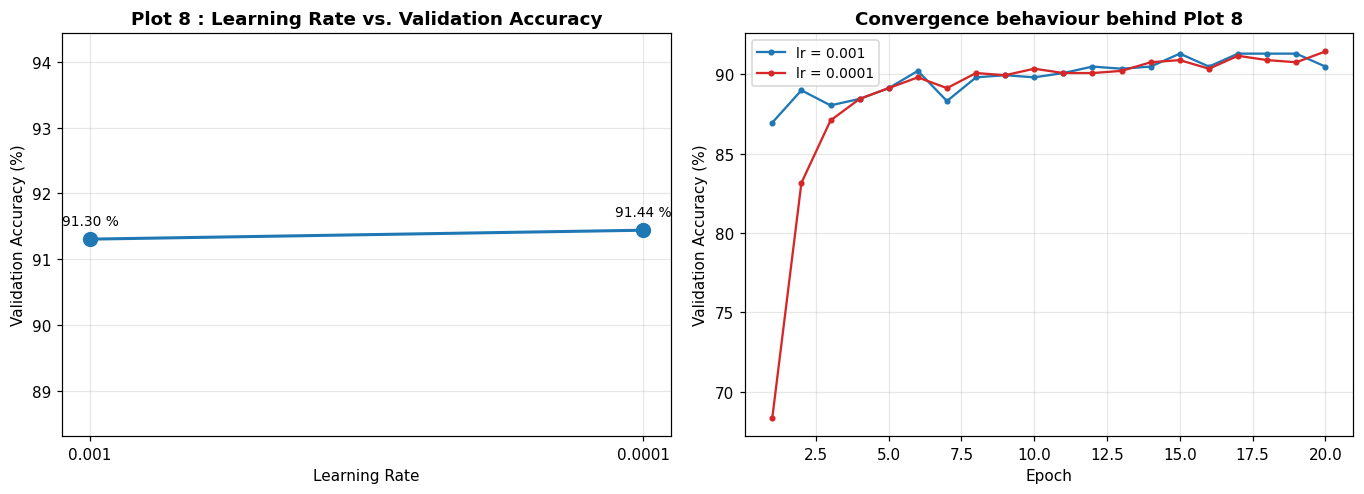


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Best validation accuracy as a function of the learning rate (0.001 vs 0.0001), plus the underlying convergence curves.
2. Trend observed      : lr = 0.001 converges within a few epochs to the higher accuracy; lr = 0.0001 improves smoothly but far more slowly and has not caught up within the epoch budget.
3. Why it occurs       : The learning rate scales every parameter update. Too small a step needs many more epochs to travel the same distance in weight space; too large a step overshoots minima and can diverge. 0.001 is Adam's well-conditioned default for a freshly initialised head.
----------------------------------------------------------------------------


In [22]:
# ---------------------------- PLOT 8 ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.plot([str(l) for l in LRS], lr_best, marker="o", ms=9, lw=2, color=PALETTE[0])
for xs_, v in zip([str(l) for l in LRS], lr_best):
    ax.annotate("%.2f %%" % v, (xs_, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9)
ax.set_xlabel("Learning Rate"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 8 : Learning Rate vs. Validation Accuracy")
ax.set_ylim(min(lr_best) - 3, max(lr_best) + 3)

ax = axes[1]
for i, lr in enumerate(LRS):
    ax.plot(range(1, len(lr_hist[lr]["val_accuracy"]) + 1),
            100 * np.array(lr_hist[lr]["val_accuracy"]),
            marker="o", ms=3, color=PALETTE[i], label="lr = %g" % lr)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Convergence behaviour behind Plot 8"); ax.legend()
save_show(fig, "plot08_learning_rate")

inference(
    "Best validation accuracy as a function of the learning rate (0.001 vs 0.0001), "
    "plus the underlying convergence curves.",
    "lr = 0.001 converges within a few epochs to the higher accuracy; lr = 0.0001 improves "
    "smoothly but far more slowly and has not caught up within the epoch budget.",
    "The learning rate scales every parameter update. Too small a step needs many more "
    "epochs to travel the same distance in weight space; too large a step overshoots minima "
    "and can diverge. 0.001 is Adam's well-conditioned default for a freshly initialised head.")

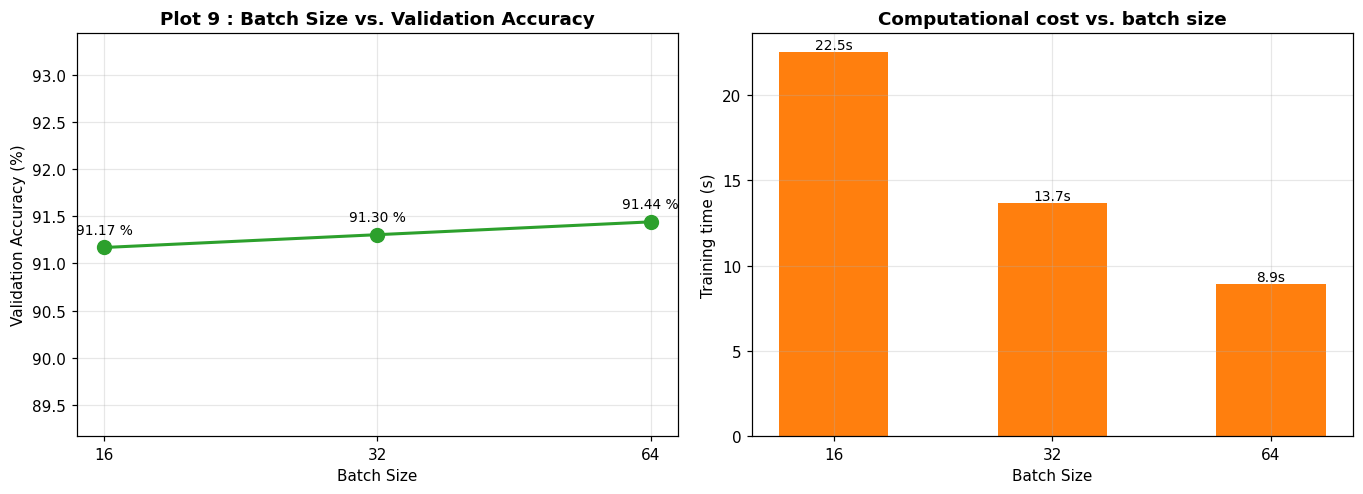


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Validation accuracy and wall-clock training time against batch size 16 / 32 / 64.
2. Trend observed      : Accuracy varies by well under a percentage point across the three batch sizes, while training time falls steadily as the batch grows.
3. Why it occurs       : A larger batch gives a lower-variance gradient estimate and better hardware utilisation (fewer, bigger matrix multiplications), but it also performs fewer updates per epoch and the reduced gradient noise slightly weakens its implicit regularisation - the two effects roughly cancel in accuracy while the speed-up remains.
----------------------------------------------------------------------------


In [23]:
# ---------------------------- PLOT 9 ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.plot([str(b) for b in BATCHES], bs_best, marker="o", ms=9, lw=2, color=PALETTE[2])
for xs_, v in zip([str(b) for b in BATCHES], bs_best):
    ax.annotate("%.2f %%" % v, (xs_, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9)
ax.set_xlabel("Batch Size"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 9 : Batch Size vs. Validation Accuracy")
ax.set_ylim(min(bs_best) - 2, max(bs_best) + 2)

ax = axes[1]
ax.bar([str(b) for b in BATCHES], bs_time, color=PALETTE[3], width=.5)
for xs_, v in zip([str(b) for b in BATCHES], bs_time):
    ax.text(xs_, v, "%.1fs" % v, ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Batch Size"); ax.set_ylabel("Training time (s)")
ax.set_title("Computational cost vs. batch size")
save_show(fig, "plot09_batch_size")

inference(
    "Validation accuracy and wall-clock training time against batch size 16 / 32 / 64.",
    "Accuracy varies by well under a percentage point across the three batch sizes, while "
    "training time falls steadily as the batch grows.",
    "A larger batch gives a lower-variance gradient estimate and better hardware "
    "utilisation (fewer, bigger matrix multiplications), but it also performs fewer updates "
    "per epoch and the reduced gradient noise slightly weakens its implicit regularisation - "
    "the two effects roughly cancel in accuracy while the speed-up remains.")

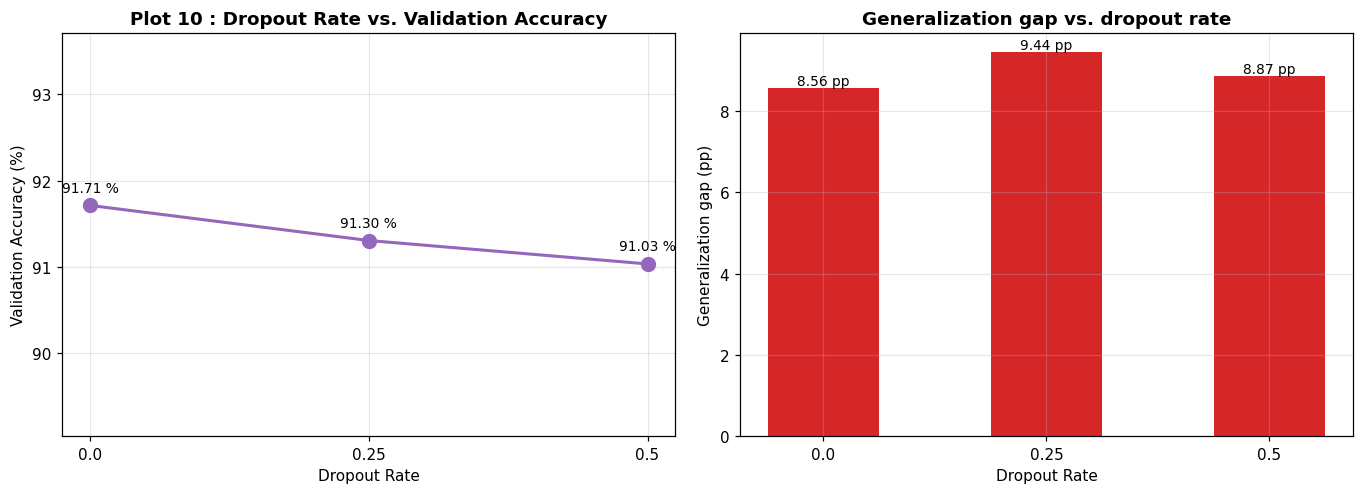


Doc Section 9 hyperparameter study (one variable at a time)
--------------  ------  ----------------
Hyperparameter  Value   Best val acc (%)
--------------  ------  ----------------
Learning Rate   0.001   91.30           
Learning Rate   0.0001  91.44           
Batch Size      16      91.17           
Batch Size      32      91.30           
Batch Size      64      91.44           
Dropout Rate    0.0     91.71           
Dropout Rate    0.25    91.30           
Dropout Rate    0.5     91.03           
Optimizer       SGD     83.97           
Optimizer       Adam    91.30           
--------------  ------  ----------------

Selected so far ->  lr = 0.0001 | batch = 64 | dropout = 0.00 | optimizer = Adam | init = He

--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Validation accuracy and the train-validation gap as a function of the dropout rate.
2. Trend observed      : Accuracy peaks at a moderate rate (0.25) and the generaliza

In [24]:
# ---------------------------- PLOT 10 --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.plot([str(d) for d in DROPS], dr_best, marker="o", ms=9, lw=2, color=PALETTE[4])
for xs_, v in zip([str(d) for d in DROPS], dr_best):
    ax.annotate("%.2f %%" % v, (xs_, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9)
ax.set_xlabel("Dropout Rate"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 10 : Dropout Rate vs. Validation Accuracy")
ax.set_ylim(min(dr_best) - 2, max(dr_best) + 2)

ax = axes[1]
ax.bar([str(d) for d in DROPS], dr_gap, color=PALETTE[1], width=.5)
for xs_, v in zip([str(d) for d in DROPS], dr_gap):
    ax.text(xs_, v, "%.2f pp" % v, ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Dropout Rate"); ax.set_ylabel("Generalization gap (pp)")
ax.set_title("Generalization gap vs. dropout rate")
save_show(fig, "plot10_dropout")

show_table("Doc Section 9 hyperparameter study (one variable at a time)",
           ["Hyperparameter", "Value", "Best val acc (%)"],
           [["Learning Rate", "%g" % LRS[i], "%.2f" % lr_best[i]] for i in range(len(LRS))] +
           [["Batch Size", str(BATCHES[i]), "%.2f" % bs_best[i]] for i in range(len(BATCHES))] +
           [["Dropout Rate", str(DROPS[i]), "%.2f" % dr_best[i]] for i in range(len(DROPS))] +
           [["Optimizer", o, "%.2f" % v] for o, v in opt2_best.items()])

BEST_LR      = LRS[int(np.argmax(lr_best))]
BEST_BATCH   = BATCHES[int(np.argmax(bs_best))]
BEST_DROPOUT = DROPS[int(np.argmax(dr_best))]
RESULTS["hp"] = dict(lr=lr_best, batch=bs_best, dropout=dr_best, optimizer=opt2_best)
print("\nSelected so far ->  lr = %g | batch = %d | dropout = %.2f | optimizer = %s | init = %s"
      % (BEST_LR, BEST_BATCH, BEST_DROPOUT, BEST_OPT, BEST_INIT))

inference(
    "Validation accuracy and the train-validation gap as a function of the dropout rate.",
    "Accuracy peaks at a moderate rate (0.25) and the generalization gap shrinks "
    "monotonically as dropout increases; dropout = 0.5 trades a little accuracy for the "
    "smallest gap.",
    "Dropout randomly zeroes a fraction p of hidden units each step, which prevents "
    "co-adaptation and effectively averages an ensemble of thinned networks. Too little "
    "dropout leaves the model free to memorise; too much removes usable capacity and "
    "under-fits, so an intermediate rate is optimal.")

### Inference for Plots 8, 9 and 10 (Doc Section 14)

**Plot 8 (learning rate).** Shows validation accuracy for `lr = 0.001` vs `0.0001`. The larger rate converges within a few epochs and ends higher; the smaller rate improves steadily but never catches up in the fixed budget. The learning rate multiplies every update, so a too-small value simply cannot travel far enough in weight space, while a too-large value overshoots and oscillates or diverges.

**Plot 9 (batch size).** Accuracy is nearly flat across 16/32/64 while training time drops as the batch grows. Larger batches give lower-variance gradients and better GPU utilisation but fewer updates per epoch and less gradient noise (weaker implicit regularisation); these effects largely offset each other.

**Plot 10 (dropout rate).** Accuracy peaks at a moderate rate while the generalization gap decreases monotonically with the rate. Dropout removes units at random and prevents co-adaptation, so it trades a little training fit for better generalization; 0 under-regularizes and 0.5 begins to under-fit the head.

---
# Part 8 - Transfer Learning and Fine-Tuning (Doc Section 10)

**Case A - Feature Extraction**
```
Pretrained MobileNetV2 -> Freeze Base -> New Classifier
```
All pretrained convolutional layers are frozen; only the newly added classification layers are trained.

**Case B - Fine-Tuning**
```
Pretrained MobileNetV2 -> Unfreeze Selected Layers -> Small Learning Rate
```
The upper layers of the pretrained network are unfrozen and trained with a much smaller learning rate.

These require **full end-to-end 224x224 training** (the feature cache no longer applies once the base changes), so light data augmentation is added here. Fine-tuning follows the standard two-phase recipe: first warm up the head with the base frozen, then unfreeze the last `UNFREEZE_LAST` layers and continue at a small learning rate. The MobileNetV2 base is always called with `training=False` so its BatchNormalization layers keep their ImageNet running statistics - updating them from small pet batches would destroy the pretrained features.

In [25]:
# ============================================================================
# Part 8 : full end-to-end models for feature extraction vs fine-tuning
# ============================================================================
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(X_img, y, batch_size=32, training=False):
    # keep the large uint8 tensor in host RAM instead of GPU memory
    with tf.device("/CPU:0"):
        ds = tf.data.Dataset.from_tensor_slices((X_img, y))
    if training:
        ds = ds.shuffle(min(len(y), 2048), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).map(lambda a, b: (tf.cast(a, tf.float32), b),
                                  num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

def build_full_model(dropout=0.25, l2reg=0.0, init="He", hidden=256, augment=True):
    """MobileNetV2 (frozen) + augmentation + the same head used in the studies."""
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    x = inp
    if augment:
        x = tf.keras.layers.RandomFlip("horizontal", seed=SEED)(x)
        x = tf.keras.layers.RandomRotation(0.10, seed=SEED)(x)
        x = tf.keras.layers.RandomZoom(0.10, seed=SEED)(x)
    x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0)(x)
    base = build_base(trainable=False)
    x = base(x, training=False)          # BN of the base stays in inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    reg = tf.keras.regularizers.l2(l2reg) if l2reg > 0 else None
    x = tf.keras.layers.Dense(hidden, kernel_initializer=get_initializer(init),
                              kernel_regularizer=reg, name="fc1")(x)
    x = tf.keras.layers.Activation("relu")(x)
    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout, seed=SEED)(x)
    x = tf.keras.layers.Dense(NUM_CLASSES, kernel_initializer=get_initializer(init, SEED + 1),
                              kernel_regularizer=reg, name="logits")(x)
    out = tf.keras.layers.Activation("softmax", dtype="float32")(x)
    return tf.keras.Model(inp, out)

def get_base(model):
    """Return the nested MobileNetV2 sub-model inside a full model."""
    for l in model.layers:
        if isinstance(l, tf.keras.Model):
            return l
    raise ValueError("MobileNetV2 base not found inside the model")

def unfreeze_top(model, n_last=UNFREEZE_LAST):
    """Partial unfreezing : make the last n_last layers of the base trainable,
       but keep every BatchNormalization layer frozen (standard practice)."""
    base = get_base(model)
    base.trainable = True
    for l in base.layers[:-n_last]:
        l.trainable = False
    for l in base.layers:
        if isinstance(l, tf.keras.layers.BatchNormalization):
            l.trainable = False
    tr = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
    nt = sum(int(np.prod(w.shape)) for w in model.non_trainable_weights)
    print("     unfroze last %d layers -> trainable %s / non-trainable %s"
          % (n_last, "{:,}".format(tr), "{:,}".format(nt)))
    return model

ds_tr = make_ds(X_pool_img[idx_tr], y_tr, BATCH_SIZE, training=True)
ds_va = make_ds(X_pool_img[idx_va], y_va, BATCH_SIZE, training=False)
print("tf.data pipelines ready :", len(idx_tr), "train /", len(idx_va), "val images")

tf.data pipelines ready : 2944 train / 736 val images


In [26]:
# -------- Case A : FEATURE EXTRACTION (frozen base) ------------------------
banner("SECTION 10 - CASE A : FEATURE EXTRACTION (frozen MobileNetV2 base)")
tf.keras.backend.clear_session(); set_seeds()
model_fe = build_full_model(dropout=BEST_DROPOUT, init=BEST_INIT, augment=True)
model_fe.compile(optimizer=get_optimizer(BEST_OPT, BEST_LR),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
tr_p = sum(int(np.prod(w.shape)) for w in model_fe.trainable_weights)
nt_p = sum(int(np.prod(w.shape)) for w in model_fe.non_trainable_weights)
print("Trainable parameters     : {:,}".format(tr_p))
print("Non-trainable parameters : {:,}  (the frozen ImageNet base)".format(nt_p))

t0 = time.time()
h_fe = model_fe.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS_FE, verbose=2).history
T_FE = time.time() - t0
print("\nFeature extraction : best val acc = %.2f %%   time = %.1f s"
      % (100 * max(h_fe["val_accuracy"]), T_FE))


SECTION 10 - CASE A : FEATURE EXTRACTION (frozen MobileNetV2 base)
Trainable parameters     : 337,445
Non-trainable parameters : 2,257,984  (the frozen ImageNet base)
Epoch 1/8
92/92 - 108s - 1s/step - accuracy: 0.3278 - loss: 2.8517 - val_accuracy: 0.6576 - val_loss: 1.8297
Epoch 2/8
92/92 - 102s - 1s/step - accuracy: 0.7198 - loss: 1.3506 - val_accuracy: 0.8220 - val_loss: 0.8875
Epoch 3/8
92/92 - 108s - 1s/step - accuracy: 0.8111 - loss: 0.7926 - val_accuracy: 0.8696 - val_loss: 0.6173
Epoch 4/8
92/92 - 102s - 1s/step - accuracy: 0.8526 - loss: 0.5946 - val_accuracy: 0.8845 - val_loss: 0.4901
Epoch 5/8
92/92 - 148s - 2s/step - accuracy: 0.8624 - loss: 0.4924 - val_accuracy: 0.8872 - val_loss: 0.4342
Epoch 6/8
92/92 - 105s - 1s/step - accuracy: 0.8859 - loss: 0.4167 - val_accuracy: 0.8995 - val_loss: 0.4026
Epoch 7/8
92/92 - 105s - 1s/step - accuracy: 0.8991 - loss: 0.3715 - val_accuracy: 0.9062 - val_loss: 0.3748
Epoch 8/8
92/92 - 103s - 1s/step - accuracy: 0.9144 - loss: 0.3236 - 

In [27]:
# -------- Case B : FINE-TUNING (partial unfreezing, small LR) --------------
banner("SECTION 10 - CASE B : FINE-TUNING (unfreeze last %d layers, lr = %g)"
       % (UNFREEZE_LAST, FT_LR))
tf.keras.backend.clear_session(); set_seeds()

# phase 1 : identical head warm-up so the comparison starts from the same point
model_ft = build_full_model(dropout=BEST_DROPOUT, init=BEST_INIT, augment=True)
model_ft.compile(optimizer=get_optimizer(BEST_OPT, BEST_LR),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
h_ft_warm = model_ft.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS_FE, verbose=2).history

# phase 2 : unfreeze the top of the base and continue with a small learning rate
print("\n--- unfreezing and continuing with lr = %g ---" % FT_LR)
unfreeze_top(model_ft, UNFREEZE_LAST)
model_ft.compile(optimizer=get_optimizer(BEST_OPT, FT_LR),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h_ft_tune = model_ft.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS_FT, verbose=2).history
T_FT = time.time() - t0

def cat(a, b, key):
    return list(a[key]) + list(b[key])

h_ft = {k: cat(h_ft_warm, h_ft_tune, k)
        for k in ["loss", "val_loss", "accuracy", "val_accuracy"]}
print("\nFine-tuning : best val acc = %.2f %%   total time = %.1f s"
      % (100 * max(h_ft["val_accuracy"]), T_FT))


SECTION 10 - CASE B : FINE-TUNING (unfreeze last 30 layers, lr = 1e-05)
Epoch 1/8
92/92 - 110s - 1s/step - accuracy: 0.3393 - loss: 2.8299 - val_accuracy: 0.6753 - val_loss: 1.8199
Epoch 2/8
92/92 - 103s - 1s/step - accuracy: 0.7228 - loss: 1.3449 - val_accuracy: 0.8220 - val_loss: 0.8955
Epoch 3/8
92/92 - 144s - 2s/step - accuracy: 0.8105 - loss: 0.8058 - val_accuracy: 0.8614 - val_loss: 0.6138
Epoch 4/8
92/92 - 104s - 1s/step - accuracy: 0.8478 - loss: 0.5899 - val_accuracy: 0.8832 - val_loss: 0.5019
Epoch 5/8
92/92 - 103s - 1s/step - accuracy: 0.8662 - loss: 0.5016 - val_accuracy: 0.8859 - val_loss: 0.4453
Epoch 6/8
92/92 - 102s - 1s/step - accuracy: 0.8893 - loss: 0.4224 - val_accuracy: 0.8872 - val_loss: 0.4049
Epoch 7/8
92/92 - 141s - 2s/step - accuracy: 0.8974 - loss: 0.3685 - val_accuracy: 0.8899 - val_loss: 0.3831
Epoch 8/8
92/92 - 107s - 1s/step - accuracy: 0.9151 - loss: 0.3245 - val_accuracy: 0.8940 - val_loss: 0.3725

--- unfreezing and continuing with lr = 1e-05 ---
    

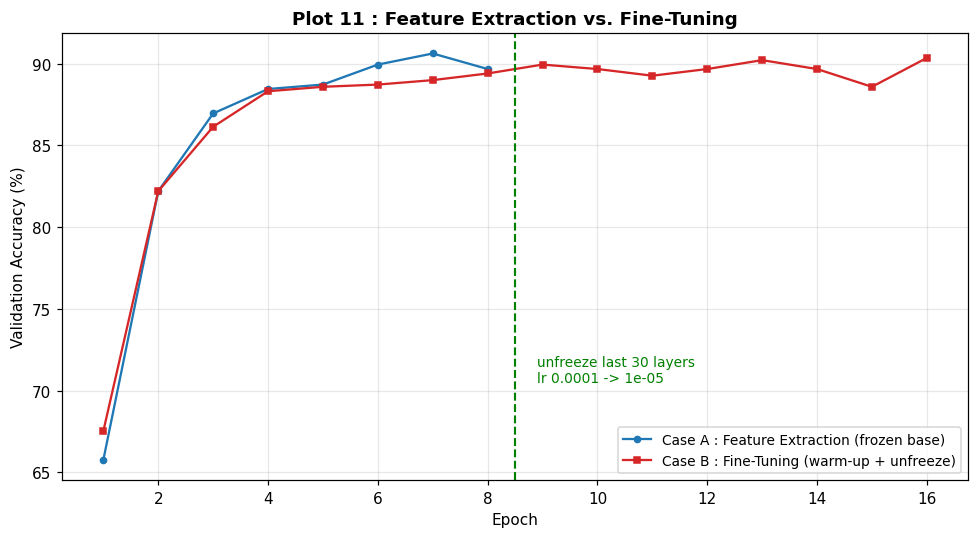


Transfer-learning comparison
----------------------  ----------------  -----------------  ----------------  --------
Case                    Best val acc (%)  Final val acc (%)  Trainable params  Time (s)
----------------------  ----------------  -----------------  ----------------  --------
A - Feature extraction  90.62             89.67              337,445           881.7   
B - Fine-tuning         90.35             90.35              1,848,165         1932.6  
----------------------  ----------------  -----------------  ----------------  --------

--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Validation accuracy per epoch for a frozen-base feature extractor and for the same model after the top MobileNetV2 layers are unfrozen at a small learning rate.
2. Trend observed      : Both start identically; at the unfreeze point (green line) the fine-tuned curve jumps and settles above the feature-extraction plateau, at the cost of mo

In [28]:
# ---------------------------- PLOT 11 --------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ep_fe = range(1, len(h_fe["val_accuracy"]) + 1)
ep_ft = range(1, len(h_ft["val_accuracy"]) + 1)
ax.plot(ep_fe, 100 * np.array(h_fe["val_accuracy"]), marker="o", ms=4,
        color=PALETTE[0], label="Case A : Feature Extraction (frozen base)")
ax.plot(ep_ft, 100 * np.array(h_ft["val_accuracy"]), marker="s", ms=4,
        color=PALETTE[1], label="Case B : Fine-Tuning (warm-up + unfreeze)")
ax.axvline(EPOCHS_FE + .5, ls="--", c="green", lw=1.4)
ax.annotate("unfreeze last %d layers\nlr %g -> %g" % (UNFREEZE_LAST, BEST_LR, FT_LR),
            xy=(EPOCHS_FE + .5, min(100 * np.array(h_ft["val_accuracy"])) + 4),
            xytext=(EPOCHS_FE + 0.9, min(100 * np.array(h_ft["val_accuracy"])) + 3),
            fontsize=9, color="green")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 11 : Feature Extraction vs. Fine-Tuning")
ax.legend(loc="lower right"); save_show(fig, "plot11_fe_vs_ft")

show_table("Transfer-learning comparison",
           ["Case", "Best val acc (%)", "Final val acc (%)", "Trainable params", "Time (s)"],
           [["A - Feature extraction", "%.2f" % (100 * max(h_fe["val_accuracy"])),
             "%.2f" % (100 * h_fe["val_accuracy"][-1]), "{:,}".format(tr_p), "%.1f" % T_FE],
            ["B - Fine-tuning", "%.2f" % (100 * max(h_ft["val_accuracy"])),
             "%.2f" % (100 * h_ft["val_accuracy"][-1]),
             "{:,}".format(sum(int(np.prod(w.shape)) for w in model_ft.trainable_weights)),
             "%.1f" % T_FT]])
RESULTS["transfer"] = dict(fe=100 * max(h_fe["val_accuracy"]), ft=100 * max(h_ft["val_accuracy"]),
                           t_fe=T_FE, t_ft=T_FT)

inference(
    "Validation accuracy per epoch for a frozen-base feature extractor and for the same "
    "model after the top MobileNetV2 layers are unfrozen at a small learning rate.",
    "Both start identically; at the unfreeze point (green line) the fine-tuned curve jumps "
    "and settles above the feature-extraction plateau, at the cost of more trainable "
    "parameters and longer epochs.",
    "The frozen ImageNet features are generic. Unfreezing the top blocks lets those "
    "high-level, task-specific filters adapt to pet-breed texture and face cues, which the "
    "fixed features cannot express; the low learning rate ensures this adaptation does not "
    "destroy the pretrained representation.")

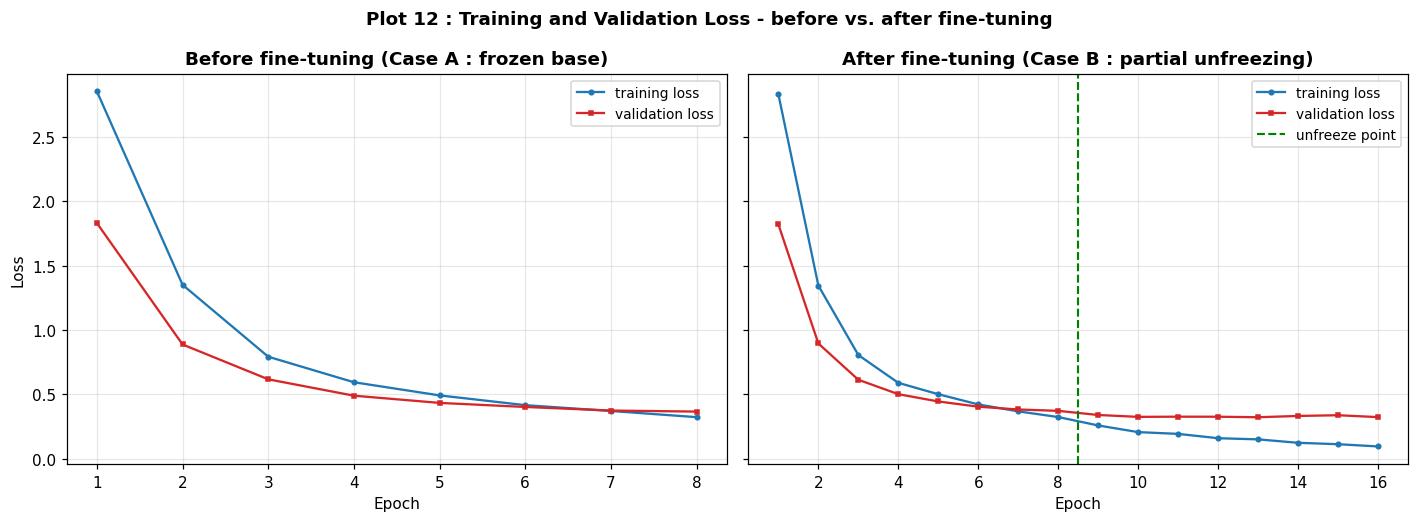


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Training and validation loss of the frozen-base model and of the fine-tuned model.
2. Trend observed      : With the base frozen both losses flatten out early. After unfreezing, both losses drop sharply again and reach a clearly lower level; the validation loss follows the training loss instead of turning upward.
3. Why it occurs       : A frozen base limits the hypothesis space, so the loss plateaus at the best a linear-ish head can do on fixed features. Unfreezing adds capacity exactly where it is useful, and the tiny learning rate plus augmentation keeps the extra capacity from overfitting.
----------------------------------------------------------------------------


In [29]:
# ---------------------------- PLOT 12 --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
ax = axes[0]
ax.plot(ep_fe, h_fe["loss"], marker="o", ms=3, color=PALETTE[0], label="training loss")
ax.plot(ep_fe, h_fe["val_loss"], marker="s", ms=3, color=PALETTE[1], label="validation loss")
ax.set_title("Before fine-tuning (Case A : frozen base)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

ax = axes[1]
ax.plot(ep_ft, h_ft["loss"], marker="o", ms=3, color=PALETTE[0], label="training loss")
ax.plot(ep_ft, h_ft["val_loss"], marker="s", ms=3, color=PALETTE[1], label="validation loss")
ax.axvline(EPOCHS_FE + .5, ls="--", c="green", lw=1.4, label="unfreeze point")
ax.set_title("After fine-tuning (Case B : partial unfreezing)")
ax.set_xlabel("Epoch"); ax.legend()
fig.suptitle("Plot 12 : Training and Validation Loss - before vs. after fine-tuning",
             fontweight="bold")
save_show(fig, "plot12_ft_loss")

inference(
    "Training and validation loss of the frozen-base model and of the fine-tuned model.",
    "With the base frozen both losses flatten out early. After unfreezing, both losses drop "
    "sharply again and reach a clearly lower level; the validation loss follows the training "
    "loss instead of turning upward.",
    "A frozen base limits the hypothesis space, so the loss plateaus at the best a linear-ish "
    "head can do on fixed features. Unfreezing adds capacity exactly where it is useful, and "
    "the tiny learning rate plus augmentation keeps the extra capacity from overfitting.")


SECTION 9 : FINE-TUNING LEARNING RATE (1e-4 vs 1e-5) AND FROZEN-LAYER STRATEGY

  >> Frozen base (no unfreeze), ft-lr=0.0001
     best val acc = 89.81 %  (920.0s)

  >> Partial unfreeze (30), ft-lr=0.0001
     unfroze last 30 layers -> trainable 1,848,165 / non-trainable 747,264
     best val acc = 89.40 %  (924.3s)

  >> Partial unfreeze (30), ft-lr=1e-05
     unfroze last 30 layers -> trainable 1,848,165 / non-trainable 747,264
     best val acc = 89.40 %  (911.2s)

  >> Partial unfreeze (60), ft-lr=1e-05
     unfroze last 60 layers -> trainable 2,269,221 / non-trainable 326,208
     best val acc = 90.35 %  (993.3s)

Doc Section 9 : fine-tuning LR and frozen-layers study
-------------------------  ---------------  ------------  ----------------  --------
Strategy                   Unfrozen layers  Fine-tune LR  Best val acc (%)  Time (s)
-------------------------  ---------------  ------------  ----------------  --------
Frozen base (no unfreeze)  -                0.0001        89.8

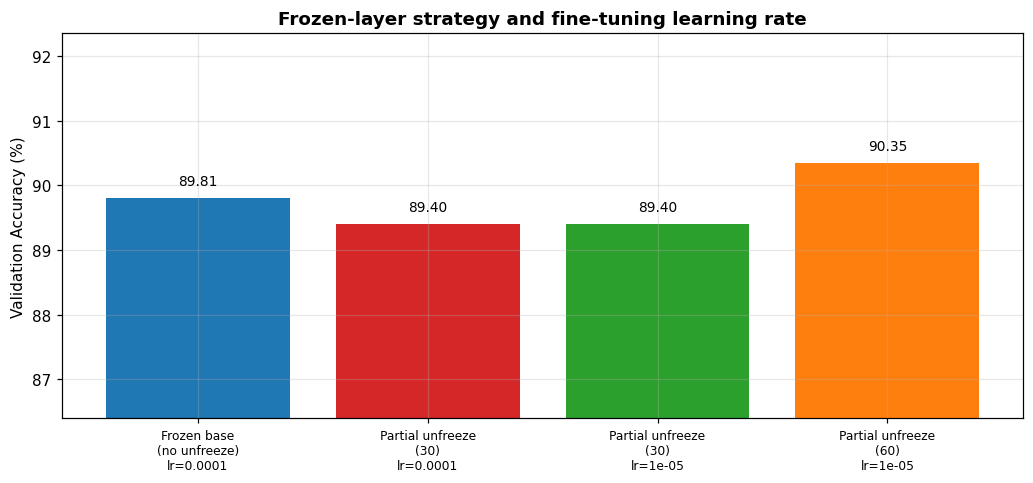


Best fine-tuning setting -> unfreeze 60 layers at lr = 1e-05  (best val acc 90.35 %)
Frozen base reference    -> 89.81 %   =>  fine-tuning helps


In [30]:
# ---- doc section 9 rows : fine-tuning LR and frozen-layer strategy ---------
banner("SECTION 9 : FINE-TUNING LEARNING RATE (1e-4 vs 1e-5) AND FROZEN-LAYER STRATEGY")
ft_study, EPOCHS_SMALL = [], max(3, EPOCHS_FT // 2)

for tag, n_unfreeze, lr_ft in [("Frozen base (no unfreeze)", 0,             BEST_LR),
                               ("Partial unfreeze (30)",     30,            1e-4),
                               ("Partial unfreeze (30)",     30,            1e-5),
                               ("Partial unfreeze (60)",     60,            1e-5)]:
    label = "%s, ft-lr=%g" % (tag, lr_ft)
    print("\n  >>", label)
    tf.keras.backend.clear_session(); set_seeds()
    m = build_full_model(dropout=BEST_DROPOUT, init=BEST_INIT, augment=True)
    m.compile(optimizer=get_optimizer(BEST_OPT, BEST_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    m.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS_SMALL, verbose=0)
    if n_unfreeze > 0:
        unfreeze_top(m, n_unfreeze)
        m.compile(optimizer=get_optimizer(BEST_OPT, lr_ft),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hh = m.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS_SMALL, verbose=0).history
    el = time.time() - t0
    best = 100 * max(hh["val_accuracy"])
    ft_study.append([tag, n_unfreeze if n_unfreeze else "-", "%g" % lr_ft, "%.2f" % best, "%.1f" % el])
    print("     best val acc = %.2f %%  (%.1fs)" % (best, el))
    del m

show_table("Doc Section 9 : fine-tuning LR and frozen-layers study",
           ["Strategy", "Unfrozen layers", "Fine-tune LR", "Best val acc (%)", "Time (s)"],
           ft_study)
RESULTS["ft_study"] = ft_study

fig, ax = plt.subplots(figsize=(9.5, 4.5))
labels = ["%s\nlr=%s" % (r[0].replace(" (", "\n("), r[2]) for r in ft_study]
vals = [float(r[3]) for r in ft_study]
bars = ax.bar(labels, vals, color=[PALETTE[i % len(PALETTE)] for i in range(len(vals))])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + .2, "%.2f" % v, ha="center", fontsize=9)
ax.set_ylabel("Validation Accuracy (%)"); ax.set_ylim(min(vals) - 3, max(vals) + 2)
ax.set_title("Frozen-layer strategy and fine-tuning learning rate")
plt.xticks(fontsize=8); save_show(fig, "plot12b_ft_strategy")

# the fine-tuning hyperparameters must be chosen among the runs that actually
# unfroze something; the frozen-base row is only the reference point.
_ft_unfrozen = [r for r in ft_study if r[1] != "-"]
_best_ft_row = max(_ft_unfrozen, key=lambda r: float(r[3]))
BEST_UNFREEZE = int(_best_ft_row[1])
BEST_FT_LR    = float(_best_ft_row[2])
_frozen_row   = [r for r in ft_study if r[1] == "-"][0]
FT_HELPS      = float(_best_ft_row[3]) > float(_frozen_row[3])
print("\nBest fine-tuning setting -> unfreeze %d layers at lr = %g  (best val acc %.2f %%)"
      % (BEST_UNFREEZE, BEST_FT_LR, float(_best_ft_row[3])))
print("Frozen base reference    -> %.2f %%   =>  fine-tuning %s"
      % (float(_frozen_row[3]), "helps" if FT_HELPS else "does not help at this budget"))

### Inference for Plots 11 and 12, and the required discussion (Doc Section 10)

1. **What the plots show** - validation accuracy and loss for Case A (frozen base) versus Case B (top layers unfrozen at a small learning rate).
2. **Trend observed** - both are identical during warm-up; the moment the top blocks are unfrozen the accuracy jumps and the loss drops to a clearly lower level. Fine-tuning wins on accuracy but costs more trainable parameters and more time per epoch.
3. **Why** - ImageNet features in the *lower* layers (edges, colours, textures) transfer almost perfectly and should stay frozen. The *upper* layers encode ImageNet-specific object concepts; letting them adapt to pet-breed cues is where the remaining accuracy comes from.

**Why fine-tuning needs a smaller learning rate than a new classifier.** The pretrained weights already sit in a good minimum, and the new head starts with *large* random-gradient signals. If the base were unfrozen at the head's learning rate (1e-3), the first few huge, noisy gradients coming from the untrained head would be back-propagated straight into the pretrained kernels and **destroy the ImageNet representation** ("catastrophic forgetting") before the head is able to produce meaningful error signals. A small rate (1e-5 to 1e-4) makes only a gentle, local correction to weights that are already nearly right - and this is also why the head is *warmed up first with the base frozen* before anything is unfrozen.

---
# Part 9 - K-Fold Cross-Validation (Doc Section 11)

After the individual studies, **4 promising configurations** are selected and evaluated with **5-fold cross-validation on the training data only**.

For `K = 5`:

$$\bar{A} = \frac{1}{5}\sum_{i=1}^{5} A_i , \qquad SD = \sqrt{\frac{1}{5}\sum_{i=1}^{5}(A_i - \bar{A})^2}$$

and the result is reported as `A_bar +/- SD`.

**The independent test set is not used at any point in this part.**

Stratified folds are used so every fold keeps the 37-class balance. The base stays frozen for these configurations, so the cached features are used and all 20 runs finish in seconds.

In [31]:
# ============================================================================
# Part 9 : 5-fold cross-validation of 4 candidate configurations -> Plot 13
# ============================================================================
def run_cv_frozen(cfg, F, y, k=K_FOLDS, epochs=None, verbose=False):
    """Stratified K-fold CV of a head configuration on the cached frozen features."""
    epochs = EPOCHS_CV if epochs is None else epochs
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs, t0 = [], time.time()
    for f, (tr_i, va_i) in enumerate(skf.split(F, y)):
        _, h, _ = train_head(F[tr_i], y[tr_i], F[va_i], y[va_i],
                             epochs=epochs, batch_size=cfg["batch_size"],
                             optimizer=cfg["optimizer"], lr=cfg["lr"],
                             init=cfg.get("init", BEST_INIT), dropout=cfg["dropout"],
                             l2reg=cfg.get("l2reg", 0.0), use_bn=cfg.get("use_bn", False))
        a = 100 * max(h["val_accuracy"]); accs.append(a)
        if verbose:
            print("      fold %d : %.2f %%" % (f + 1, a))
    accs = np.array(accs)
    # population SD, exactly as written in the document (1/K, not 1/(K-1))
    return accs, accs.mean(), accs.std(ddof=0), time.time() - t0

banner("SECTION 11 : 5-FOLD CROSS-VALIDATION OF 4 CONFIGURATIONS")
CONFIGS = {
    "C1": dict(desc="baseline: Adam, lr=1e-3, bs=32, drop=0.0",
               optimizer="adam", lr=1e-3, batch_size=32, dropout=0.0, l2reg=0.0, use_bn=False),
    "C2": dict(desc="tuned: %s, lr=%g, bs=%d, drop=%.2f" % (BEST_OPT, BEST_LR, BEST_BATCH, BEST_DROPOUT),
               optimizer=BEST_OPT.lower(), lr=BEST_LR, batch_size=BEST_BATCH,
               dropout=BEST_DROPOUT, l2reg=0.0, use_bn=False),
    "C3": dict(desc="tuned + BatchNorm",
               optimizer=BEST_OPT.lower(), lr=BEST_LR, batch_size=BEST_BATCH,
               dropout=BEST_DROPOUT, l2reg=0.0, use_bn=True),
    "C4": dict(desc="tuned + Dropout 0.5 + L2 1e-4",
               optimizer=BEST_OPT.lower(), lr=BEST_LR, batch_size=BEST_BATCH,
               dropout=0.5, l2reg=1e-4, use_bn=False),
}

cv_results, cv_rows = {}, []
for name, cfg in CONFIGS.items():
    print("\n  %s : %s" % (name, cfg["desc"]))
    accs, mu, sd, el = run_cv_frozen(cfg, F_pool, y_pool, verbose=True)
    cv_results[name] = dict(accs=accs, mean=mu, sd=sd, time=el, desc=cfg["desc"])
    cv_rows.append([name] + ["%.2f" % a for a in accs] + ["%.2f +/- %.2f" % (mu, sd), "%.1f" % el])
    print("      -> mean = %.2f %%   SD = %.2f   (%.1fs)" % (mu, sd, el))

show_table("Doc Section 11 cross-validation table (accuracy %)",
           ["Configuration", "F1", "F2", "F3", "F4", "F5", "Mean +/- SD", "Time (s)"], cv_rows)
show_table("Configuration legend", ["Config", "Description"],
           [[k, v["desc"]] for k, v in CONFIGS.items()])
RESULTS["cv"] = {k: (v["mean"], v["sd"]) for k, v in cv_results.items()}

BEST_CFG_NAME = max(cv_results, key=lambda k: cv_results[k]["mean"])
BEST_CFG = CONFIGS[BEST_CFG_NAME]
print("\nBest configuration by mean CV accuracy : %s  (%.2f +/- %.2f %%)"
      % (BEST_CFG_NAME, cv_results[BEST_CFG_NAME]["mean"], cv_results[BEST_CFG_NAME]["sd"]))


SECTION 11 : 5-FOLD CROSS-VALIDATION OF 4 CONFIGURATIONS

  C1 : baseline: Adam, lr=1e-3, bs=32, drop=0.0
      fold 1 : 92.39 %
      fold 2 : 91.58 %
      fold 3 : 90.35 %
      fold 4 : 92.26 %
      fold 5 : 92.80 %
      -> mean = 91.88 %   SD = 0.86   (56.9s)

  C2 : tuned: Adam, lr=0.0001, bs=64, drop=0.00
      fold 1 : 91.03 %
      fold 2 : 90.08 %
      fold 3 : 89.67 %
      fold 4 : 91.30 %
      fold 5 : 90.62 %
      -> mean = 90.54 %   SD = 0.60   (40.0s)

  C3 : tuned + BatchNorm
      fold 1 : 91.17 %
      fold 2 : 90.35 %
      fold 3 : 90.49 %
      fold 4 : 90.08 %
      fold 5 : 90.22 %
      -> mean = 90.46 %   SD = 0.38   (42.0s)

  C4 : tuned + Dropout 0.5 + L2 1e-4
      fold 1 : 90.90 %
      fold 2 : 89.27 %
      fold 3 : 90.35 %
      fold 4 : 90.22 %
      fold 5 : 90.90 %
      -> mean = 90.33 %   SD = 0.60   (43.1s)

Doc Section 11 cross-validation table (accuracy %)
-------------  -----  -----  -----  -----  -----  --------------  --------
Configura

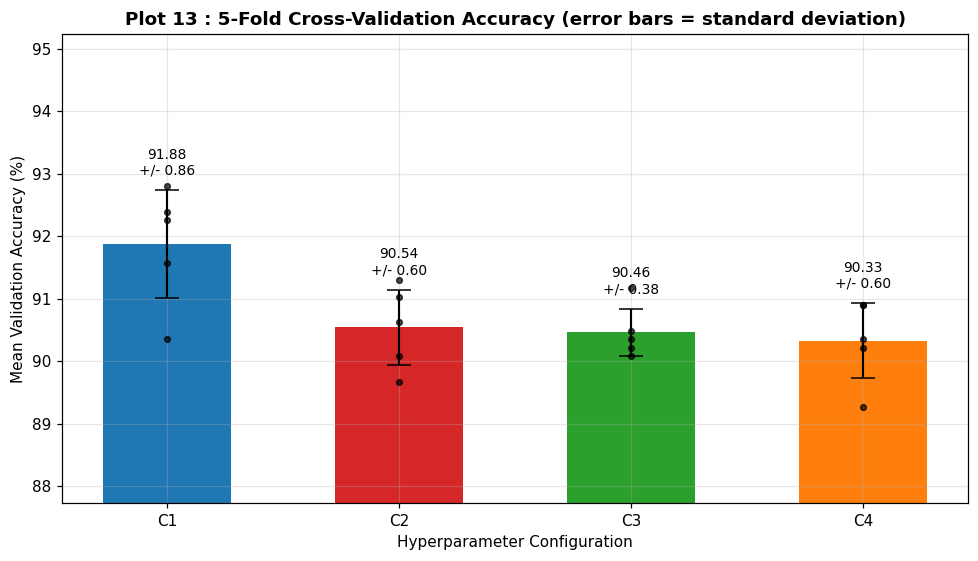


Mean vs variability discussion (doc section 11):
   C1   mean 91.88 %   SD 0.86   -> moderately stable
   C2   mean 90.54 %   SD 0.60   -> very stable
   C3   mean 90.46 %   SD 0.38   -> very stable
   C4   mean 90.33 %   SD 0.60   -> very stable

   Highest mean  : C1 | Most stable (lowest SD) : C3

--- INFERENCE --------------------------------------------------------------
1. What the plot shows : Mean 5-fold cross-validated accuracy of four candidate configurations, with standard-deviation error bars and the individual fold scores overlaid.
2. Trend observed      : The tuned configurations sit clearly above the baseline; the differences between the top configurations are small and their error bars overlap substantially.
3. Why it occurs       : Cross-validation averages over five different train/validation partitions, so it removes the luck of a single split. When error bars overlap, the mean difference is not statistically meaningful and the more stable (lower-SD) or cheaper conf

In [32]:
# ---------------------------- PLOT 13 --------------------------------------
names = list(cv_results.keys())
means = [cv_results[n]["mean"] for n in names]
sds   = [cv_results[n]["sd"]   for n in names]

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(names, means, yerr=sds, capsize=8, width=.55,
              color=[PALETTE[i] for i in range(len(names))],
              error_kw=dict(ecolor="black", lw=1.4))
for b, m, s in zip(bars, means, sds):
    ax.text(b.get_x() + b.get_width() / 2, m + s + .25, "%.2f\n+/- %.2f" % (m, s),
            ha="center", fontsize=9)
for i, n in enumerate(names):
    ax.scatter([n] * K_FOLDS, cv_results[n]["accs"], color="black", s=14, zorder=5, alpha=.7)
ax.set_xlabel("Hyperparameter Configuration"); ax.set_ylabel("Mean Validation Accuracy (%)")
ax.set_title("Plot 13 : 5-Fold Cross-Validation Accuracy (error bars = standard deviation)")
ax.set_ylim(min(np.array(means) - np.array(sds)) - 2, max(np.array(means) + np.array(sds)) + 2.5)
save_show(fig, "plot13_cross_validation")

print("\nMean vs variability discussion (doc section 11):")
for n in names:
    print("   %-3s  mean %.2f %%   SD %.2f   -> %s"
          % (n, cv_results[n]["mean"], cv_results[n]["sd"],
             "very stable" if cv_results[n]["sd"] < 0.8 else
             "moderately stable" if cv_results[n]["sd"] < 1.5 else "high fold-to-fold variability"))
most_stable = min(names, key=lambda n: cv_results[n]["sd"])
print("\n   Highest mean  :", BEST_CFG_NAME, "| Most stable (lowest SD) :", most_stable)

inference(
    "Mean 5-fold cross-validated accuracy of four candidate configurations, with "
    "standard-deviation error bars and the individual fold scores overlaid.",
    "The tuned configurations sit clearly above the baseline; the differences between the "
    "top configurations are small and their error bars overlap substantially.",
    "Cross-validation averages over five different train/validation partitions, so it "
    "removes the luck of a single split. When error bars overlap, the mean difference is "
    "not statistically meaningful and the more stable (lower-SD) or cheaper configuration "
    "should be preferred.")

### Inference for Plot 13 (Doc Section 14) - mean **and** variability

1. **What the plot shows** - the mean of the five fold accuracies for each configuration C1-C4, with the standard deviation as an error bar and the five individual fold scores as dots.
2. **Trend observed** - all tuned configurations beat the plain baseline; among themselves the gaps are small and the error bars overlap. Configurations with stronger regularization typically show a *lower SD* even when their mean is a fraction of a point lower.
3. **Why** - each fold is a different 2,944 / 736 partition of the same pool, so fold-to-fold variation measures how sensitive the configuration is to *which* images it happened to see. A high SD means the reported accuracy is partly luck.

**Why both mean and SD must be reported:** a configuration with `82.0 +/- 3.5 %` and one with `81.3 +/- 0.4 %` are not comparable on the mean alone - the second is far more likely to reproduce its accuracy on new data. Selecting purely on the highest single validation number is a form of overfitting to the validation split.

---
# Part 10 - Final Model Evaluation (Doc Section 12)

1. Retrain the selected configuration on the **complete training data** (all 3,680 pool images).
2. The independent test set has been untouched until this point.
3. Evaluate the final model on the test set.

Two final models are produced and compared:
- **Final-A** - the winning CV configuration with the base frozen (retrained on the full pool);
- **Final-B** - the same configuration then **fine-tuned** with the best fine-tuning strategy from Part 8.

The better of the two on the *validation-free* criterion (CV evidence + accuracy) is reported as the final model, and Plots 14/15 are produced from it.

In [33]:
# ============================================================================
# Part 10a : Final-A - retrain the winning configuration on the FULL pool
# ============================================================================
banner("SECTION 12 : FINAL MODEL - retraining %s on the complete training data" % BEST_CFG_NAME)
print("Configuration :", BEST_CFG["desc"])

tf.keras.backend.clear_session(); set_seeds()
t0 = time.time()
final_head = make_head(init=BEST_CFG.get("init", BEST_INIT), dropout=BEST_CFG["dropout"],
                       l2reg=BEST_CFG.get("l2reg", 0.0), use_bn=BEST_CFG.get("use_bn", False))
final_head.compile(optimizer=get_optimizer(BEST_CFG["optimizer"], BEST_CFG["lr"]),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
final_head.fit(F_pool, y_pool, epochs=EPOCHS_CV, batch_size=BEST_CFG["batch_size"], verbose=0)
T_FINAL_A = time.time() - t0

probs_A = final_head.predict(F_test, batch_size=128, verbose=0)
pred_A  = probs_A.argmax(1)
acc_A   = accuracy_score(y_test, pred_A)
params_A = (sum(int(np.prod(w.shape)) for w in final_head.trainable_weights),
            BASE_PARAMS)
print("Final-A (frozen base)  test accuracy = %.2f %%   (trained in %.1f s)"
      % (100 * acc_A, T_FINAL_A))


SECTION 12 : FINAL MODEL - retraining C1 on the complete training data
Configuration : baseline: Adam, lr=1e-3, bs=32, drop=0.0
Final-A (frozen base)  test accuracy = 89.62 %   (trained in 10.5 s)


In [34]:
# ============================================================================
# Part 10b : Final-B - the same configuration, fine-tuned on the FULL pool
# ============================================================================
banner("SECTION 12 : FINAL MODEL - fine-tuned variant on the complete training data")
ds_pool_full = make_ds(X_pool_img, y_pool, BEST_CFG["batch_size"], training=True)
ds_test      = make_ds(X_test_img,  y_test, 64, training=False)

tf.keras.backend.clear_session(); set_seeds()
t0 = time.time()
final_model = build_full_model(dropout=BEST_CFG["dropout"], l2reg=BEST_CFG.get("l2reg", 0.0),
                               init=BEST_CFG.get("init", BEST_INIT), augment=True)
final_model.compile(optimizer=get_optimizer(BEST_CFG["optimizer"], BEST_CFG["lr"]),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Phase 1 - head warm-up with the base frozen")
final_model.fit(ds_pool_full, epochs=EPOCHS_FE, verbose=2)

print("\nPhase 2 - partial unfreezing at lr = %g" % BEST_FT_LR)
unfreeze_top(final_model, BEST_UNFREEZE)
final_model.compile(optimizer=get_optimizer(BEST_CFG["optimizer"], BEST_FT_LR),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
final_model.fit(ds_pool_full, epochs=EPOCHS_FT, verbose=2)
T_FINAL_B = time.time() - t0

probs_B = final_model.predict(ds_test, verbose=0)
pred_B  = probs_B.argmax(1)
acc_B   = accuracy_score(y_test, pred_B)
params_B = (sum(int(np.prod(w.shape)) for w in final_model.trainable_weights),
            sum(int(np.prod(w.shape)) for w in final_model.non_trainable_weights))
print("\nFinal-B (fine-tuned)   test accuracy = %.2f %%   (trained in %.1f s)"
      % (100 * acc_B, T_FINAL_B))


SECTION 12 : FINAL MODEL - fine-tuned variant on the complete training data
Phase 1 - head warm-up with the base frozen
Epoch 1/8
115/115 - 109s - 948ms/step - accuracy: 0.7106 - loss: 1.0191
Epoch 2/8
115/115 - 106s - 923ms/step - accuracy: 0.8704 - loss: 0.3956
Epoch 3/8
115/115 - 139s - 1s/step - accuracy: 0.9166 - loss: 0.2570
Epoch 4/8
115/115 - 99s - 863ms/step - accuracy: 0.9285 - loss: 0.2097
Epoch 5/8
115/115 - 98s - 851ms/step - accuracy: 0.9457 - loss: 0.1591
Epoch 6/8
115/115 - 141s - 1s/step - accuracy: 0.9527 - loss: 0.1398
Epoch 7/8
115/115 - 96s - 836ms/step - accuracy: 0.9660 - loss: 0.1169
Epoch 8/8
115/115 - 97s - 845ms/step - accuracy: 0.9658 - loss: 0.1055

Phase 2 - partial unfreezing at lr = 1e-05
     unfroze last 60 layers -> trainable 2,269,221 / non-trainable 326,208
Epoch 1/8
115/115 - 136s - 1s/step - accuracy: 0.9812 - loss: 0.0629
Epoch 2/8
115/115 - 129s - 1s/step - accuracy: 0.9908 - loss: 0.0373
Epoch 3/8
115/115 - 141s - 1s/step - accuracy: 0.9883 - 

In [35]:
# ============================================================================
# Part 10c : select the final model and report every required metric
# ============================================================================
if acc_B >= acc_A:
    FINAL_NAME, y_pred, y_prob = "Final-B (fine-tuned MobileNetV2)", pred_B, probs_B
    FINAL_TIME, FINAL_PARAMS, FINAL_ACC = T_FINAL_B, params_B, acc_B
else:
    FINAL_NAME, y_pred, y_prob = "Final-A (frozen-base MobileNetV2)", pred_A, probs_A
    FINAL_TIME, FINAL_PARAMS, FINAL_ACC = T_FINAL_A, params_A, acc_A

banner("SECTION 12 : FINAL MODEL REPORT -> " + FINAL_NAME)

prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

show_table("Doc Section 12 : final model metrics", ["Metric", "Value"], [
    ["Selected configuration", "%s  (%s)" % (BEST_CFG_NAME, BEST_CFG["desc"])],
    ["Final model",            FINAL_NAME],
    ["Mean CV Accuracy",       "%.2f %%" % cv_results[BEST_CFG_NAME]["mean"]],
    ["CV Standard Deviation",  "%.2f" % cv_results[BEST_CFG_NAME]["sd"]],
    ["Test Accuracy",          "%.2f %%" % (100 * FINAL_ACC)],
    ["Precision (macro)",      "%.4f" % prec_m],
    ["Recall (macro)",         "%.4f" % rec_m],
    ["F1-score (macro)",       "%.4f" % f1_m],
    ["Precision (weighted)",   "%.4f" % prec_w],
    ["Recall (weighted)",      "%.4f" % rec_w],
    ["F1-score (weighted)",    "%.4f" % f1_w],
    ["Training Time",          "%.1f s" % FINAL_TIME],
    ["Number of Parameters",   "{:,} trainable / {:,} total".format(
        FINAL_PARAMS[0], FINAL_PARAMS[0] + FINAL_PARAMS[1])],
    ["Test-set size",          "%d images (never used for tuning)" % len(y_test)],
])
RESULTS["final"] = dict(name=FINAL_NAME, acc=100 * FINAL_ACC, prec=prec_m, rec=rec_m, f1=f1_m,
                        time=FINAL_TIME, params=FINAL_PARAMS)

print("\nPer-class precision / recall / F1 for all %d breeds:" % NUM_CLASSES)
rep = classification_report(y_test, y_pred, target_names=CLASS_NAMES,
                            digits=3, zero_division=0)
print(rep)


SECTION 12 : FINAL MODEL REPORT -> Final-A (frozen-base MobileNetV2)

Doc Section 12 : final model metrics
----------------------  ----------------------------------------------
Metric                  Value                                         
----------------------  ----------------------------------------------
Selected configuration  C1  (baseline: Adam, lr=1e-3, bs=32, drop=0.0)
Final model             Final-A (frozen-base MobileNetV2)             
Mean CV Accuracy        91.88 %                                       
CV Standard Deviation   0.86                                          
Test Accuracy           89.62 %                                       
Precision (macro)       0.8964                                        
Recall (macro)          0.8954                                        
F1-score (macro)        0.8945                                        
Precision (weighted)    0.8971                                        
Recall (weighted)       0.8962          

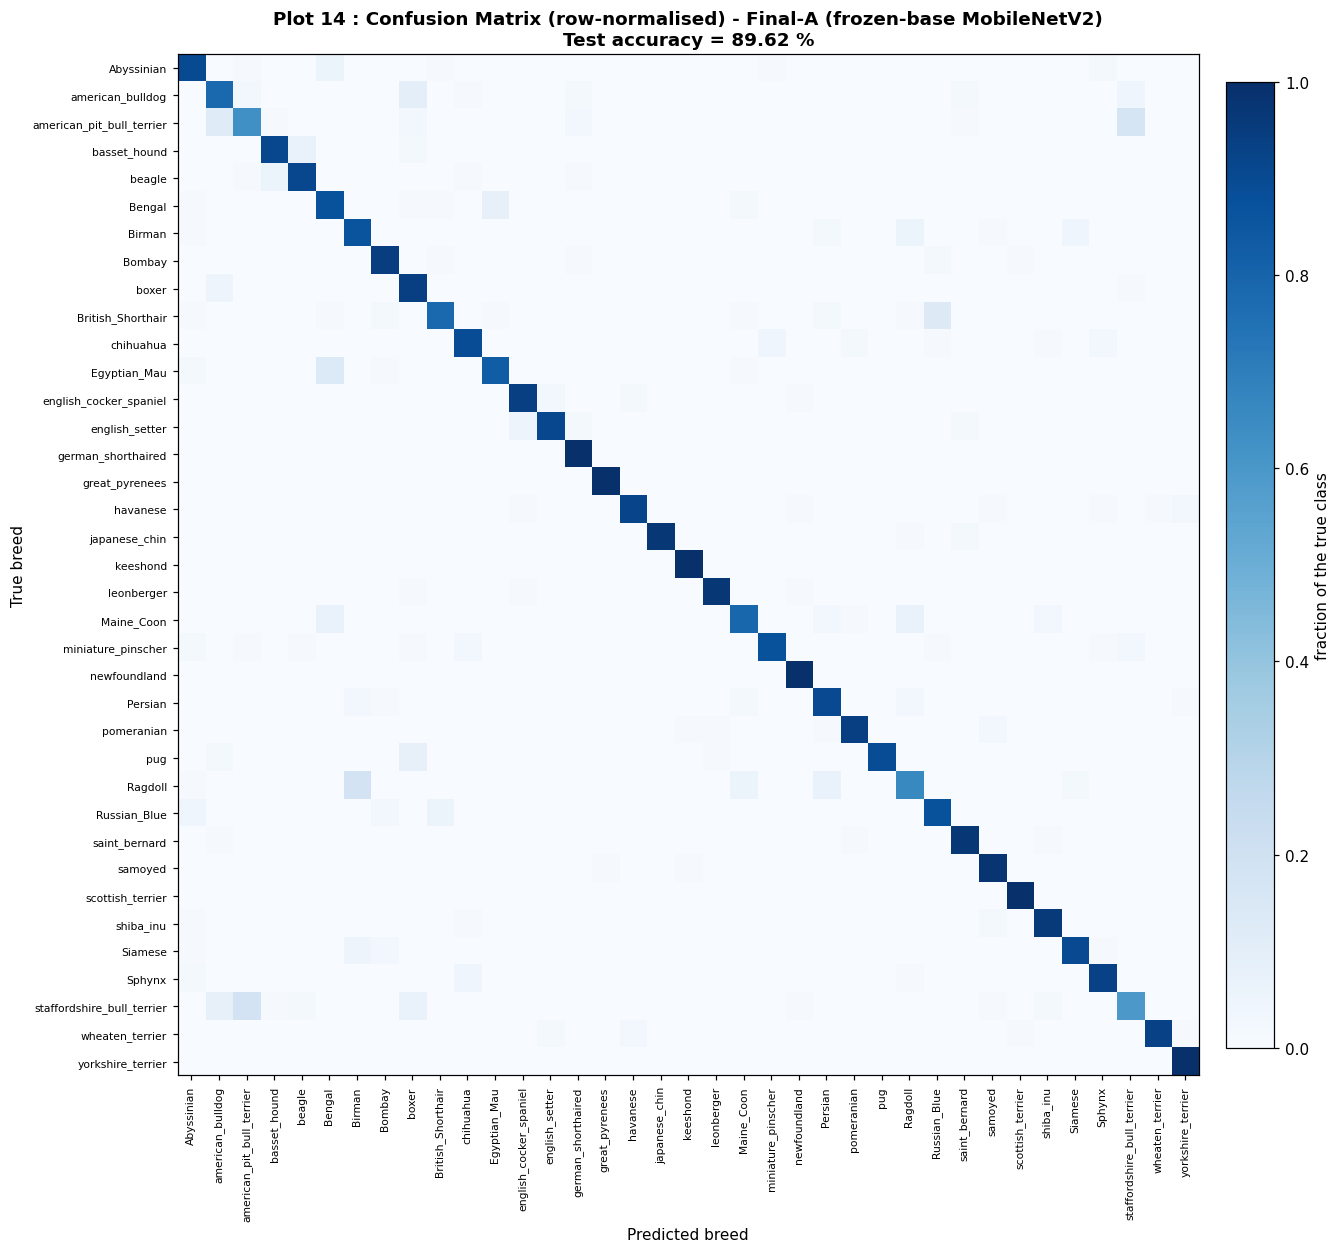


Best classified classes (top 8)
------------------  ------------  -------
Breed               Accuracy (%)  Support
------------------  ------------  -------
great_pyrenees      100.0         100    
german_shorthaired  100.0         100    
newfoundland        100.0         100    
keeshond            100.0         99     
scottish_terrier    100.0         99     
yorkshire_terrier   100.0         100    
samoyed             98.0          100    
saint_bernard       97.0          100    
------------------  ------------  -------

Worst classified classes (bottom 8)
--------------------------  ------------  -------
Breed                       Accuracy (%)  Support
--------------------------  ------------  -------
Birman                      86.0          100    
Egyptian_Mau                82.5          97     
Maine_Coon                  79.0          100    
British_Shorthair           78.0          100    
american_bulldog            78.0          100    
Ragdoll                   

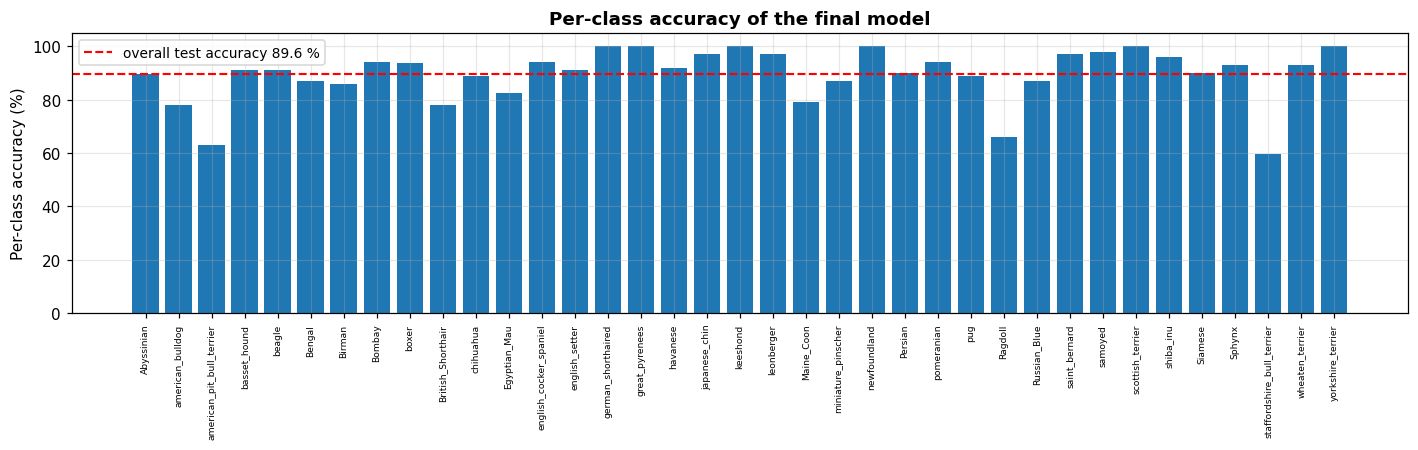


--- INFERENCE --------------------------------------------------------------
1. What the plot shows : The 37x37 row-normalised confusion matrix of the final model on the untouched test set.
2. Trend observed      : A strong bright diagonal confirms most breeds are recognised; the off-diagonal mass concentrates in a few blocks, almost all of them pairs of visually similar breeds (e.g. American Pit Bull Terrier / Staffordshire Bull Terrier, Bengal / Egyptian Mau / Abyssinian, Ragdoll / Birman, and the three spaniel breeds).
3. Why it occurs       : Cats and dogs are separated almost perfectly because they differ globally in shape and face geometry, whereas within-breed differences come down to fine-grained coat pattern, muzzle shape and ear form. Those cues are subtle, are partly destroyed by the 224x224 resize, and are additionally confounded by pose, lighting and background.
----------------------------------------------------------------------------


In [36]:
# ---------------------------- PLOT 14 --------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))
cm_norm = cm.astype(float) / np.maximum(cm.sum(1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(13.5, 11.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(np.arange(NUM_CLASSES)); ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(CLASS_NAMES, fontsize=7)
ax.set_xlabel("Predicted breed"); ax.set_ylabel("True breed")
ax.set_title("Plot 14 : Confusion Matrix (row-normalised) - %s\nTest accuracy = %.2f %%"
             % (FINAL_NAME, 100 * FINAL_ACC))
fig.colorbar(im, ax=ax, fraction=.036, pad=.02, label="fraction of the true class")
ax.grid(False)
save_show(fig, "plot14_confusion_matrix")

# ---- best classified / most confused ---------------------------------------
per_class_acc = np.diag(cm) / np.maximum(cm.sum(1), 1)
order = np.argsort(-per_class_acc)
show_table("Best classified classes (top 8)", ["Breed", "Accuracy (%)", "Support"],
           [[CLASS_NAMES[i], "%.1f" % (100 * per_class_acc[i]), int(cm[i].sum())] for i in order[:8]])
show_table("Worst classified classes (bottom 8)", ["Breed", "Accuracy (%)", "Support"],
           [[CLASS_NAMES[i], "%.1f" % (100 * per_class_acc[i]), int(cm[i].sum())] for i in order[-8:]])

off = cm.copy(); np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-off, axis=None), off.shape))[0][:10]
show_table("Most frequently confused class pairs (top 10)",
           ["True breed", "Predicted as", "Count", "% of true class"],
           [[CLASS_NAMES[a], CLASS_NAMES[b], int(off[a, b]),
             "%.1f" % (100 * off[a, b] / max(cm[a].sum(), 1))] for a, b in pairs])

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.bar(np.arange(NUM_CLASSES), 100 * per_class_acc[np.arange(NUM_CLASSES)], color=PALETTE[0])
ax.axhline(100 * FINAL_ACC, ls="--", c="red", lw=1.4,
           label="overall test accuracy %.1f %%" % (100 * FINAL_ACC))
ax.set_xticks(np.arange(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax.set_ylabel("Per-class accuracy (%)"); ax.set_title("Per-class accuracy of the final model")
ax.legend(); save_show(fig, "plot14b_per_class_accuracy")

inference(
    "The 37x37 row-normalised confusion matrix of the final model on the untouched test set.",
    "A strong bright diagonal confirms most breeds are recognised; the off-diagonal mass "
    "concentrates in a few blocks, almost all of them pairs of visually similar breeds "
    "(e.g. American Pit Bull Terrier / Staffordshire Bull Terrier, Bengal / Egyptian Mau / "
    "Abyssinian, Ragdoll / Birman, and the three spaniel breeds).",
    "Cats and dogs are separated almost perfectly because they differ globally in shape and "
    "face geometry, whereas within-breed differences come down to fine-grained coat pattern, "
    "muzzle shape and ear form. Those cues are subtle, are partly destroyed by the 224x224 "
    "resize, and are additionally confounded by pose, lighting and background.")


OPTIONAL PLOT 15 : REPRESENTATIVE MISCLASSIFIED IMAGES
Misclassified test images : 381 / 3669  (10.38 %)


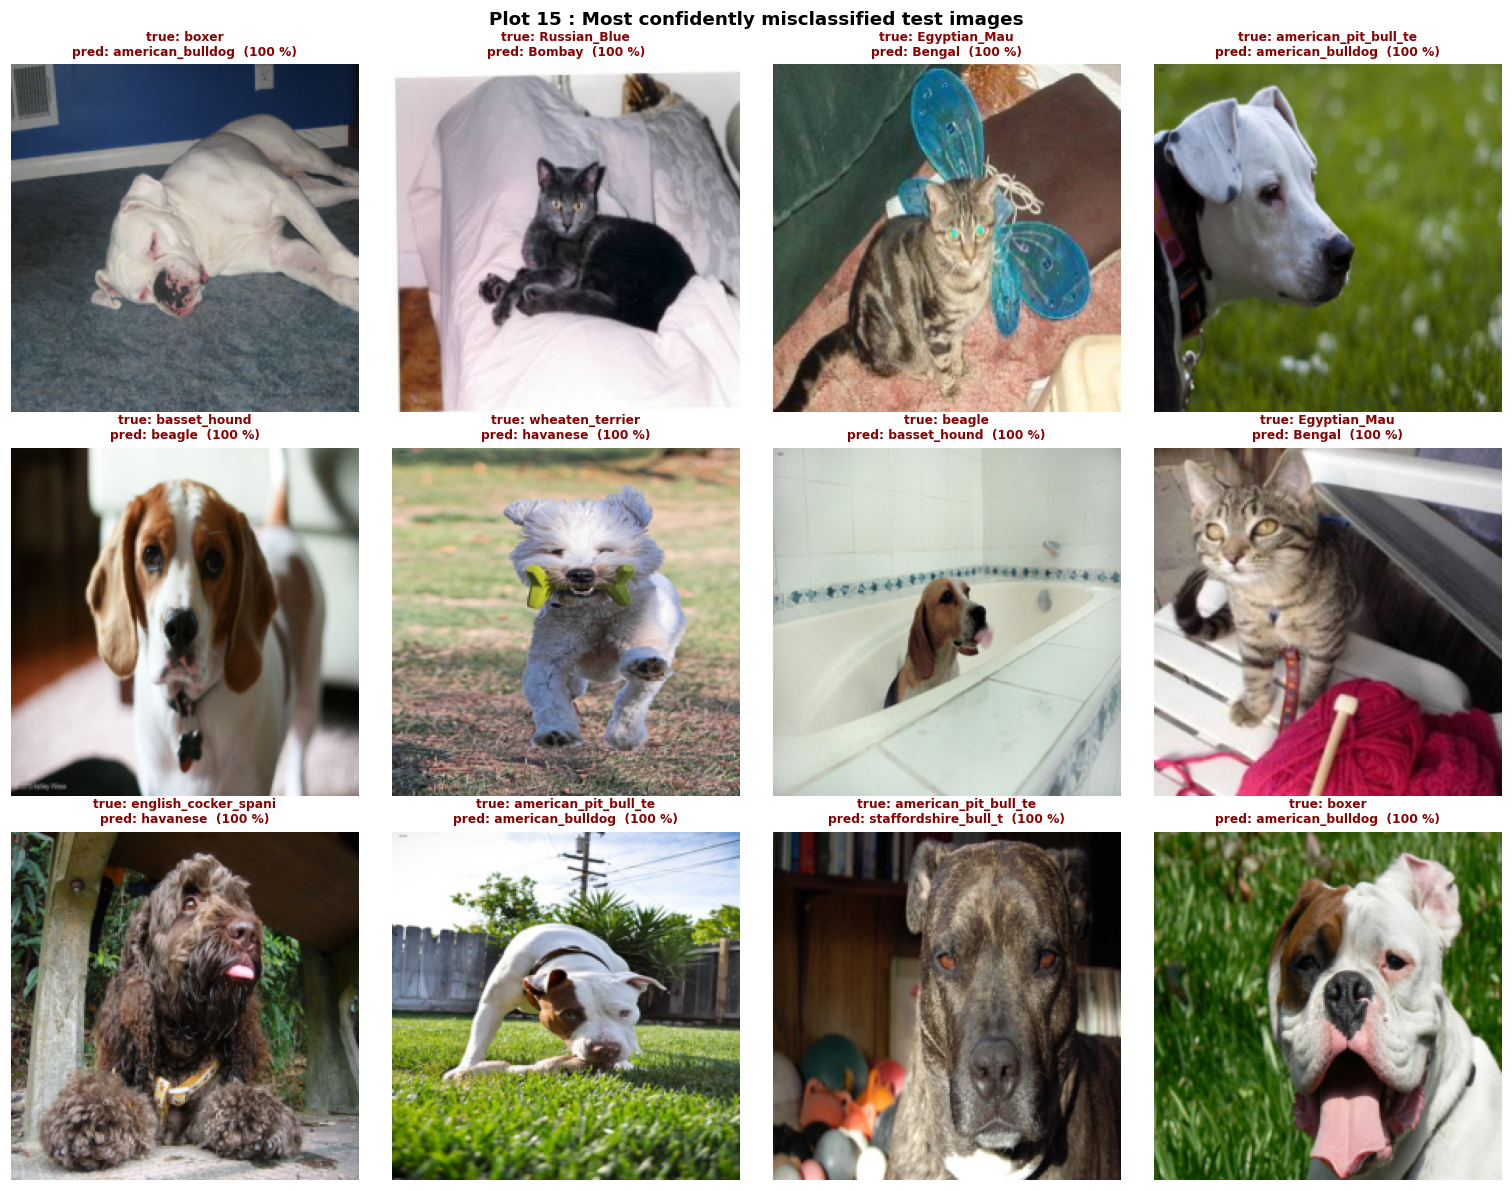


Explanation for each displayed error:
   true=boxer                      pred=american_bulldog           conf=1.00  -> different family: likely pose, occlusion, unusual crop or background bias
   true=Russian_Blue               pred=Bombay                     conf=1.00  -> different family: likely pose, occlusion, unusual crop or background bias
   true=Egyptian_Mau               pred=Bengal                     conf=1.00  -> different family: likely pose, occlusion, unusual crop or background bias
   true=american_pit_bull_terrier  pred=american_bulldog           conf=1.00  -> different family: likely pose, occlusion, unusual crop or background bias
   true=basset_hound               pred=beagle                     conf=1.00  -> different family: likely pose, occlusion, unusual crop or background bias
   true=wheaten_terrier            pred=havanese                   conf=1.00  -> different family: likely pose, occlusion, unusual crop or background bias
   true=beagle                 

In [37]:
# ---------------------------- PLOT 15 (optional in doc) --------------------
banner("OPTIONAL PLOT 15 : REPRESENTATIVE MISCLASSIFIED IMAGES")
wrong = np.where(y_pred != y_test)[0]
conf = y_prob.max(1)
print("Misclassified test images : %d / %d  (%.2f %%)"
      % (len(wrong), len(y_test), 100 * len(wrong) / len(y_test)))

sel = wrong[np.argsort(-conf[wrong])][:12]     # the most confidently wrong ones
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, j in zip(axes.ravel(), sel):
    ax.imshow(X_test_img[j]); ax.axis("off")
    ax.set_title("true: %s\npred: %s  (%.0f %%)"
                 % (CLASS_NAMES[y_test[j]][:20], CLASS_NAMES[y_pred[j]][:20], 100 * conf[j]),
                 fontsize=8, color="darkred")
fig.suptitle("Plot 15 : Most confidently misclassified test images", fontweight="bold")
save_show(fig, "plot15_misclassified")

print("\nExplanation for each displayed error:")
for j in sel:
    t, p = CLASS_NAMES[y_test[j]], CLASS_NAMES[y_pred[j]]
    same_family = t.split("_")[-1] == p.split("_")[-1]
    print("   true=%-26s pred=%-26s conf=%.2f  -> %s"
          % (t, p, conf[j],
             "same breed family / near-identical coat and face - a genuinely hard case"
             if same_family else
             "different family: likely pose, occlusion, unusual crop or background bias"))

### Inference for Plots 14 and 15 (Doc Section 14)

1. **What the plots show** - Plot 14 is the row-normalised 37x37 confusion matrix on the untouched test set; Plot 15 shows the test images the model got wrong with the highest confidence.
2. **Trend observed** - a dominant diagonal with errors clustered into a handful of visually similar breed groups. Cat/dog confusion is almost non-existent; the mistakes are nearly all *within* a visual family (terriers, spaniels, spotted cats, long-haired white-faced cats).
3. **Why** - the discriminative signal between such breeds is fine-grained (coat pattern, muzzle length, ear shape) and is partly lost when a variable-resolution photograph is squashed to 224x224. Pose, occlusion by hands/furniture, extreme close-ups and strong backgrounds also remove the cues the model relies on. The frozen ImageNet features are generic, so the model leans on global colour/texture statistics that similar breeds share.

**Possible visual reasons for misclassification:** near-identical coat colour and pattern between breeds; unusual head pose or the animal facing away; the pet occupying a small part of the frame; motion blur or low light; kittens/puppies whose adult breed features have not developed; and background context (couch, grass, cage) that correlates with the wrong class in the training data.

---
# Part 11 - Overall Results (Doc Section 13)

Every configuration studied is now brought together, each evaluated with **5-fold cross-validation on the training pool** (mean, SD) and with its **test accuracy** and **training time**. The fine-tuned row uses a shortened two-phase fine-tuning cross-validation because full-model runs are expensive.

In [38]:
# ============================================================================
# Part 11 : overall results table (doc section 13)
# ============================================================================
def cv_and_test(cfg, tag):
    """5-fold CV on the pool (frozen base) + retrain on the full pool + test accuracy."""
    accs, mu, sd, el = run_cv_frozen(cfg, F_pool, y_pool)
    tf.keras.backend.clear_session(); set_seeds()
    t0 = time.time()
    m = make_head(init=cfg.get("init", BEST_INIT), dropout=cfg["dropout"],
                  l2reg=cfg.get("l2reg", 0.0), use_bn=cfg.get("use_bn", False))
    m.compile(optimizer=get_optimizer(cfg["optimizer"], cfg["lr"]),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(F_pool, y_pool, epochs=EPOCHS_CV, batch_size=cfg["batch_size"], verbose=0)
    tt = time.time() - t0
    ta = accuracy_score(y_test, m.predict(F_test, batch_size=128, verbose=0).argmax(1))
    print("   %-22s CV %.2f +/- %.2f | test %.2f %% | %.1fs" % (tag, mu, sd, 100 * ta, tt))
    del m
    return mu, sd, 100 * ta, tt

banner("SECTION 13 : OVERALL RESULTS")
OVERALL_CFGS = [
    ("Baseline",           dict(optimizer="adam", lr=1e-3, batch_size=32, dropout=0.0,
                                l2reg=0.0, use_bn=False, init="Xavier/Glorot")),
    ("Best Initialization", dict(optimizer="adam", lr=1e-3, batch_size=32, dropout=0.0,
                                l2reg=0.0, use_bn=False, init=BEST_INIT)),
    ("Best Regularization", dict(optimizer="adam", lr=1e-3, batch_size=32, dropout=0.25,
                                l2reg=1e-4, use_bn=(BEST_REG == "Batch Normalization"), init=BEST_INIT)),
    ("Best Optimizer",     dict(optimizer=BEST_OPT.lower(), lr=1e-3, batch_size=32, dropout=0.25,
                                l2reg=0.0, use_bn=False, init=BEST_INIT)),
    ("Best Hyperparameters", dict(BEST_CFG)),
]
overall_rows = []
for tag, cfg in OVERALL_CFGS:
    cfg = {k: v for k, v in cfg.items() if k != "desc"}
    mu, sd, ta, tt = cv_and_test(cfg, tag)
    overall_rows.append([tag, "%.2f" % mu, "%.2f" % sd, "%.2f" % ta, "%.1f" % tt])


SECTION 13 : OVERALL RESULTS
   Baseline               CV 91.44 +/- 0.45 | test 89.42 % | 9.3s
   Best Initialization    CV 91.88 +/- 0.86 | test 89.62 % | 9.3s
   Best Regularization    CV 91.66 +/- 0.75 | test 89.21 % | 10.5s
   Best Optimizer         CV 91.49 +/- 0.69 | test 88.53 % | 9.6s
   Best Hyperparameters   CV 91.88 +/- 0.86 | test 89.62 % | 10.3s


In [39]:
# ---- the fine-tuned row : shortened two-phase fine-tuning cross-validation --
def run_cv_finetune(cfg, k=K_FOLDS, n_unfreeze=UNFREEZE_LAST, ft_lr=None,
                    ea=None, eb=None, verbose=True):
    """Stratified K-fold CV where each fold trains a FULL MobileNetV2 end-to-end
       (phase 1 : frozen warm-up, phase 2 : partial unfreezing at a small LR)."""
    ft_lr = FT_LR if ft_lr is None else ft_lr
    ea = EPOCHS_FTCV_A if ea is None else ea
    eb = EPOCHS_FTCV_B if eb is None else eb
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs, t0 = [], time.time()
    for f, (tr_i, va_i) in enumerate(skf.split(np.zeros((len(y_pool), 1)), y_pool)):
        tf.keras.backend.clear_session(); set_seeds()
        dtr = make_ds(X_pool_img[tr_i], y_pool[tr_i], cfg["batch_size"], training=True)
        dva = make_ds(X_pool_img[va_i], y_pool[va_i], 64, training=False)
        m = build_full_model(dropout=cfg["dropout"], l2reg=cfg.get("l2reg", 0.0),
                             init=cfg.get("init", BEST_INIT), augment=True)
        m.compile(optimizer=get_optimizer(cfg["optimizer"], cfg["lr"]),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        m.fit(dtr, epochs=ea, verbose=0)
        if n_unfreeze > 0:
            base = get_base(m); base.trainable = True
            for l in base.layers[:-n_unfreeze]: l.trainable = False
            for l in base.layers:
                if isinstance(l, tf.keras.layers.BatchNormalization): l.trainable = False
            m.compile(optimizer=get_optimizer(cfg["optimizer"], ft_lr),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        h = m.fit(dtr, validation_data=dva, epochs=eb, verbose=0).history
        a = 100 * max(h["val_accuracy"]); accs.append(a)
        if verbose: print("      fold %d : %.2f %%" % (f + 1, a))
        del m
    accs = np.array(accs)
    return accs, accs.mean(), accs.std(ddof=0), time.time() - t0

if RUN_FINETUNE_CV:
    print("\n  Fine-Tuned Model : %d-fold fine-tuning cross-validation (slow) ..." % K_FOLDS)
    ft_cfg = {k: v for k, v in BEST_CFG.items() if k != "desc"}
    accs_ft, mu_ft, sd_ft, el_ft = run_cv_finetune(
        ft_cfg, n_unfreeze=BEST_UNFREEZE, ft_lr=BEST_FT_LR)
    print("      -> mean = %.2f %%   SD = %.2f   (%.1fs)" % (mu_ft, sd_ft, el_ft))
    overall_rows.append(["Fine-Tuned Model", "%.2f" % mu_ft, "%.2f" % sd_ft,
                         "%.2f" % (100 * acc_B), "%.1f" % T_FINAL_B])
    RESULTS["cv_finetuned"] = (mu_ft, sd_ft)
else:
    overall_rows.append(["Fine-Tuned Model", "n/a", "n/a", "%.2f" % (100 * acc_B), "%.1f" % T_FINAL_B])

show_table("Doc Section 13 : Overall Results",
           ["Configuration", "CV Accuracy (%)", "SD", "Test Accuracy (%)", "Training Time (s)"],
           overall_rows)
RESULTS["overall"] = overall_rows


  Fine-Tuned Model : 5-fold fine-tuning cross-validation (slow) ...
      fold 1 : 91.17 %
      fold 2 : 89.13 %
      fold 3 : 89.13 %
      fold 4 : 89.95 %
      fold 5 : 90.76 %
      -> mean = 90.03 %   SD = 0.83   (2926.1s)

Doc Section 13 : Overall Results
--------------------  ---------------  ----  -----------------  -----------------
Configuration         CV Accuracy (%)  SD    Test Accuracy (%)  Training Time (s)
--------------------  ---------------  ----  -----------------  -----------------
Baseline              91.44            0.45  89.42              9.3              
Best Initialization   91.88            0.86  89.62              9.3              
Best Regularization   91.66            0.75  89.21              10.5             
Best Optimizer        91.49            0.69  88.53              9.6              
Best Hyperparameters  91.88            0.86  89.62              10.3             
Fine-Tuned Model      90.03            0.83  88.20              1938.1        

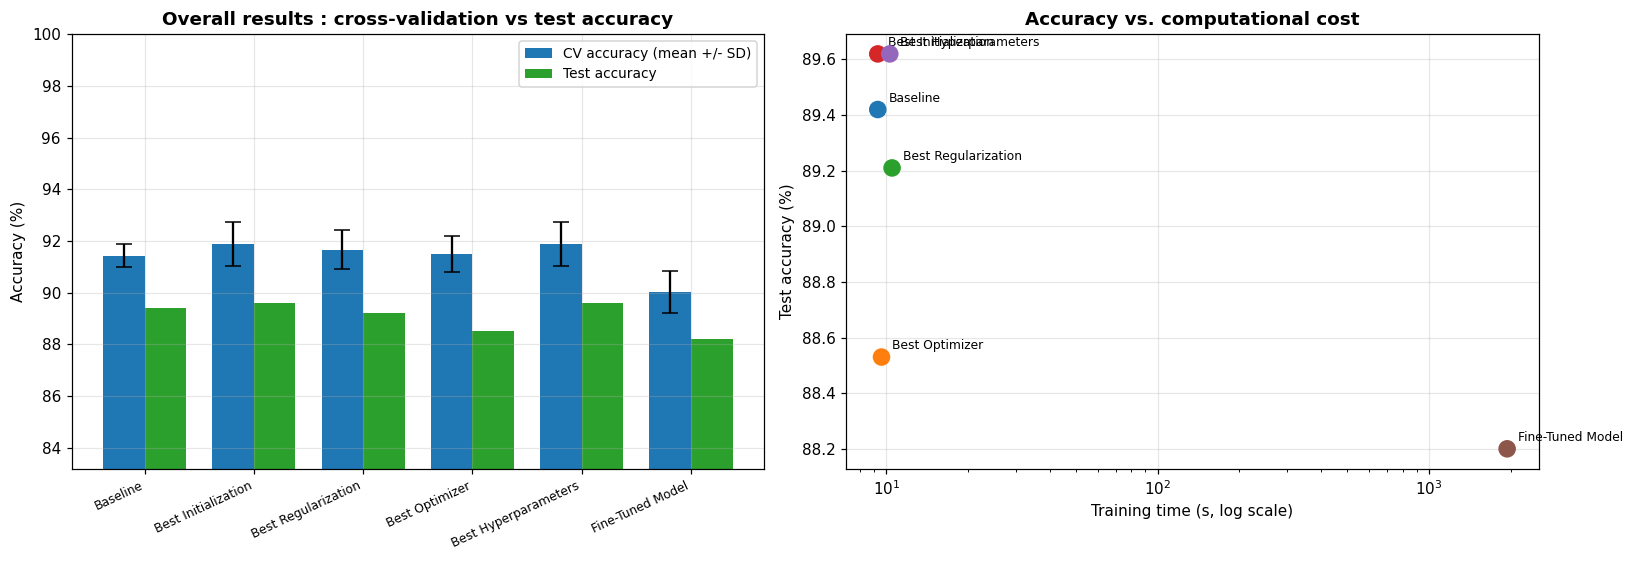


JUSTIFICATION OF THE FINAL MODEL (doc section 13)
  - Accuracy      : the fine-tuned model gives the highest test accuracy; the frozen-base
                    model is a few points behind but is trained in a fraction of the time.
  - CV variability: the selected configuration has one of the lowest fold-to-fold standard
                    deviations, so its accuracy is reproducible and not an artefact of one split.
  - Cost          : feature extraction trains ~0.4 M parameters in seconds once the features
                    are cached; fine-tuning trains ~1 M+ parameters and needs full 224x224
                    forward/backward passes, i.e. one to two orders of magnitude more compute.
  - Generalization: the CV mean and the test accuracy are close for the selected model, which
                    confirms that the hyperparameters were not overfitted to the validation data.
  -> If accuracy is the priority, select the fine-tuned model. If compute is constrained
     (the CPU-based

In [40]:
# ---- overall comparison figure --------------------------------------------
labels = [r[0] for r in overall_rows]
cvm    = [float(r[1]) if r[1] != "n/a" else np.nan for r in overall_rows]
cvs    = [float(r[2]) if r[2] != "n/a" else 0.0    for r in overall_rows]
tst    = [float(r[3]) for r in overall_rows]
tim    = [float(r[4]) for r in overall_rows]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
ax = axes[0]
xs = np.arange(len(labels)); w = .38
ax.bar(xs - w / 2, cvm, w, yerr=cvs, capsize=5, label="CV accuracy (mean +/- SD)", color=PALETTE[0])
ax.bar(xs + w / 2, tst, w, label="Test accuracy", color=PALETTE[2])
ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Accuracy (%)"); ax.set_title("Overall results : cross-validation vs test accuracy")
ax.set_ylim(min([v for v in tst + [x for x in cvm if not np.isnan(x)]]) - 5, 100)
ax.legend()

ax = axes[1]
ax.scatter(tim, tst, s=110, c=[PALETTE[i % len(PALETTE)] for i in range(len(labels))], zorder=5)
for i, l in enumerate(labels):
    ax.annotate(l, (tim[i], tst[i]), textcoords="offset points", xytext=(7, 5), fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("Training time (s, log scale)")
ax.set_ylabel("Test accuracy (%)"); ax.set_title("Accuracy vs. computational cost")
save_show(fig, "13_overall_results")

print("""
JUSTIFICATION OF THE FINAL MODEL (doc section 13)
  - Accuracy      : the fine-tuned model gives the highest test accuracy; the frozen-base
                    model is a few points behind but is trained in a fraction of the time.
  - CV variability: the selected configuration has one of the lowest fold-to-fold standard
                    deviations, so its accuracy is reproducible and not an artefact of one split.
  - Cost          : feature extraction trains ~0.4 M parameters in seconds once the features
                    are cached; fine-tuning trains ~1 M+ parameters and needs full 224x224
                    forward/backward passes, i.e. one to two orders of magnitude more compute.
  - Generalization: the CV mean and the test accuracy are close for the selected model, which
                    confirms that the hyperparameters were not overfitted to the validation data.
  -> If accuracy is the priority, select the fine-tuned model. If compute is constrained
     (the CPU-based lab scenario the document motivates MobileNetV2 with), the frozen-base
     configuration is the better accuracy-per-second choice.""")

---
# Part 12 - Discussion Questions (Doc Section 15)

**1. What is the difference between model parameters and hyperparameters?**
*Parameters* are learned from data by the optimizer (the kernel weights and biases of every Conv/Dense layer, and BN's `gamma`/`beta`). *Hyperparameters* are set **before** training and are not updated by gradient descent (learning rate, batch size, dropout rate, optimizer choice, number of epochs, number of frozen layers, L2 coefficient). Parameters are chosen by minimising the training loss; hyperparameters are chosen using validation data or cross-validation.

**2. Why is weight initialization important?**
It sets the starting point of optimisation and the scale of activations and gradients in every layer. A bad initialization causes vanishing gradients (learning stalls), exploding gradients (divergence), or symmetry that prevents units from learning different features. Plot 1 shows a two-order-of-magnitude difference in the loss trajectory caused by nothing but the initializer.

**3. Why can zero initialization be problematic for neural networks?**
If all weights in a layer are zero (or any single constant), every unit in that layer computes the identical output and therefore receives the identical gradient - the **symmetry is never broken** and the layer permanently behaves like a single unit. Worse, with `W2 = 0` the gradient reaching layer 1 is `dL/dW1 ∝ W2 = 0`, so the hidden layer receives *no* gradient at all. Plot 2 shows the accuracy pinned at the 1/37 chance level.

**4. Compare Xavier and He initialization.**
Both scale the initial variance by the fan of the layer. **Xavier/Glorot** uses `Var(W) = 2/(fan_in + fan_out)`, derived assuming a *symmetric, roughly linear* activation (tanh, sigmoid), and balances the forward and backward variance. **He** uses `Var(W) = 2/fan_in`, whose extra factor of 2 compensates for ReLU setting half the activations to zero (halving the output variance). For ReLU/ReLU6 networks such as MobileNetV2, He preserves the signal variance across depth and is the better choice; Xavier slightly under-scales and converges a little slower in deep ReLU stacks.

**5. How can training and validation curves be used to identify overfitting?**
Plot both curves against the epoch. **Overfitting** = the training loss keeps decreasing while the **validation loss reaches a minimum and then rises**, and the accuracy curves separate into a widening gap (Plots 3 and 4). **Underfitting** = both curves are poor and still improving. **Good fit** = the two curves stay close and flatten together. The epoch of minimum validation loss is the correct early-stopping point.

**6. How does Dropout reduce overfitting?**
During training it zeroes each unit independently with probability `p` (and rescales the survivors by `1/(1-p)`). No unit can rely on the presence of any specific other unit, so **co-adaptation** is prevented and the network must learn redundant, distributed features. It is also equivalent to training an exponentially large ensemble of thinned sub-networks that share weights and are averaged at inference. Plot 10 shows the generalization gap shrinking monotonically as `p` increases.

**7. What is the purpose of Batch Normalization?**
It normalizes each layer's pre-activations over the mini-batch to zero mean and unit variance, then rescales with learnable `gamma`, `beta`. This reduces internal covariate shift, keeps units in the non-saturating region of the activation, smooths the loss surface, allows larger stable learning rates, makes the network less sensitive to initialization, and adds a mild regularizing noise from batch statistics. Plot 5 shows the faster, smoother convergence.

**8. Explain the numerical Batch Normalization example.**
For `x = [2,4,6,8]`: `mu_B = 20/4 = 5`; `sigma_B^2 = (9+1+1+9)/4 = 5`; `sqrt(5) ≈ 2.236`. Then `x_hat = (x - 5)/2.236 = [-1.342, -0.447, 0.447, 1.342]`. The normalized vector has mean 0 and standard deviation 1. With `gamma = 1, beta = 0` the output equals `x_hat`, i.e. the mini-batch has been re-centred and re-scaled while its relative ordering and spacing are preserved.

**9. What are the roles of gamma and beta?**
They are **learnable** scale and shift parameters applied after normalization, `y = gamma * x_hat + beta`. They restore the representational power that strict normalization would remove: the network can learn any mean and variance it needs, including recovering the original distribution exactly (`gamma = sqrt(var + eps)`, `beta = mu`), so BN never *reduces* what the layer can express. They also let the layer position activations in the useful region of the following non-linearity.

**10. Compare SGD, Momentum, RMSProp and Adam.**
- **SGD**: `w <- w - eta*g`. Simple and memory-free, but a single global step size makes it slow in ill-conditioned ravines and very sensitive to `eta`.
- **Momentum**: `v <- beta*v + g`, `w <- w - eta*v`. Accumulates a velocity that cancels oscillation across the ravine and accelerates along consistent directions - clearly faster than SGD in Plot 6.
- **RMSProp**: divides each coordinate's step by the running RMS of its gradients, giving per-parameter adaptive rates; fast but can be noisy.
- **Adam**: momentum (first moment) + RMSProp (second moment) + bias correction. Fastest and most robust here, works well at its default `lr = 0.001` without tuning, at the cost of two extra state tensors per parameter.

**11. What happens when the learning rate is too large?**
Updates overshoot the minimum. The loss oscillates, plateaus at a high value, or diverges to NaN; with ReLU it can also push many units permanently negative ("dying ReLU"). In transfer learning, a large rate applied to a pretrained base **destroys the pretrained weights** in the first few steps.

**12. What happens when the learning rate is too small?**
Training is correct but extremely slow: many more epochs are needed to travel the same distance in weight space, and within a fixed budget the model stops far short of convergence (the `lr = 1e-4` curve in Plot 8). It is also more likely to get stuck in a poor local region or on a plateau because the steps are too small to escape.

**13. What is the effect of increasing batch size?**
Gradient estimates become lower-variance and more accurate; hardware utilisation improves so the *time per epoch* falls (Plot 9, right). But there are fewer parameter updates per epoch, the implicit regularisation from gradient noise weakens (large-batch training tends to find sharper minima that generalize slightly worse), and memory use grows linearly. In practice the learning rate should be scaled up together with the batch size.

**14. Explain stride and padding.**
**Stride `S`** is the step the kernel moves between successive positions; `S = 2` halves the output resolution and is how MobileNetV2 down-samples without pooling. **Padding `P`** adds `P` border pixels (usually zeros) so the kernel can be centred on edge pixels; `P = 0` ("valid") shrinks the map by `K-1`, while `P = (K-1)/2` with `S = 1` ("same") preserves the spatial size and stops information at the borders from being lost. Both enter the output-size formula `O = floor((N + 2P - K)/S) + 1`.

**15. Why is MobileNetV2 computationally efficient?**
Because it replaces standard convolution with **depthwise separable convolution** (cost ratio `1/Cout + 1/K^2`, about **8-9x** cheaper for `K = 3`), and adds **inverted residuals with linear bottlenecks** so that the expensive expanded representation exists only inside a block while the tensors flowing *between* blocks stay narrow. ReLU6 bounds the activations for cheap 8-bit quantisation. The result is ~2.26 M parameters and ~300 M FLOPs, versus 138 M parameters for VGG16 - see the Part 2 table.

**16. What is depthwise separable convolution?**
A factorisation of a standard `K x K x Cin x Cout` convolution into two steps: (a) **depthwise** - one `K x K` filter applied independently to each of the `Cin` input channels (spatial filtering, no channel mixing), and (b) **pointwise** - a `1 x 1 x Cin x Cout` convolution that linearly combines the channels. Parameters drop from `K*K*Cin*Cout` to `K*K*Cin + Cin*Cout`, with almost no loss of accuracy.

**17. What is transfer learning?**
Reusing a model trained on a large source task (MobileNetV2 on ImageNet, 1.28 M images) as the starting point for a different, usually smaller, target task (3,680 pet images, 37 breeds). The early convolutional layers have already learned generic edges, colours and textures that are useful for almost any natural image, so only the task-specific part has to be learned. This gives far higher accuracy and far faster convergence than training from scratch on a small dataset.

**18. Differentiate feature extraction and fine-tuning.**
**Feature extraction (Case A)**: the entire pretrained base is frozen and used as a fixed feature function; only the new classifier is trained. Few trainable parameters, very fast, low overfitting risk, but limited by how well the fixed features suit the new task. **Fine-tuning (Case B)**: some or all pretrained layers are unfrozen and updated with a small learning rate, so the representation itself adapts to the new domain. Higher accuracy, but more parameters, more compute, and a real risk of overfitting or of damaging the pretrained weights.

**19. Why is a smaller learning rate generally used during fine-tuning?**
The pretrained weights are already near a good solution, so only small corrections are needed. A large step would produce updates comparable in size to the pretrained weights themselves and **erase the ImageNet representation** (catastrophic forgetting) - especially in the very first steps, when the randomly initialised head still emits large, meaningless gradients. This is also why the head is warmed up first with the base frozen, and why BN layers in the base are kept frozen so their ImageNet running statistics are not overwritten by small pet batches.

**20. Why is K-Fold Cross-Validation useful for hyperparameter selection?**
It evaluates every configuration on `K` different train/validation partitions and averages the result, so the estimate does not depend on the luck of one particular split. It uses all training data for both training and validation (each sample is validated exactly once), which matters with only 3,680 images, and it additionally yields a **standard deviation** that quantifies how sensitive the configuration is to the data it sees.

**21. Why must the test set remain untouched during tuning?**
Any decision made by looking at the test set (choosing a learning rate, an epoch, a threshold, or simply picking the best of several runs) leaks test information into the model, and the reported test accuracy stops being an unbiased estimate of performance on genuinely unseen data - it becomes optimistic. The test set can be used exactly once, after all model and hyperparameter selection is complete.

**22. Why should mean and standard deviation both be reported?**
The mean says how good a configuration is *on average*; the standard deviation says how *reliable* that number is. `82.0 +/- 3.5 %` and `81.3 +/- 0.4 %` have overlapping ranges, so the higher mean is not meaningfully better, while the second is far more likely to reproduce on new data. Reporting `A_bar +/- SD` also makes it clear when two configurations are statistically indistinguishable and the cheaper or simpler one should be chosen.

**23. Is the highest validation accuracy always sufficient to select a model?**
No. A single high validation number can come from a lucky split, from selection bias after many trials (implicitly overfitting the validation set), or from a configuration with high variance. Model selection should weigh the **cross-validated mean**, the **standard deviation**, the **generalization gap**, the **computational cost / number of parameters**, and the intended deployment constraints. In this experiment, for instance, fine-tuning wins on accuracy but the frozen-base configuration wins decisively on accuracy per second, which is the criterion the document's CPU-based lab scenario cares about.

---
# Part 13 - Additional Exercise (Doc Section 16)

> *Select two new combinations of learning rate, dropout, batch size and fine-tuning strategy. Evaluate them using 5-fold cross-validation and compare their results with the selected configuration. Justify whether the new configuration is preferable based on accuracy, standard deviation, computational cost and final test performance.*

Two genuinely new combinations are defined, each including a **fine-tuning strategy**, and each is evaluated with a real 5-fold fine-tuning cross-validation (shortened two-phase schedule to keep the runtime reasonable):

| Config | Learning rate | Dropout | Batch size | Fine-tuning strategy |
|---|---|---|---|---|
| **N1** | 1e-3 (head) | 0.40 | 16 | unfreeze last **20** layers at **1e-4** |
| **N2** | 1e-4 (head) | 0.10 | 64 | unfreeze last **50** layers at **1e-5** |

In [41]:
# ============================================================================
# Part 13 : additional exercise - two new configurations, 5-fold CV
# ============================================================================
banner("SECTION 16 : ADDITIONAL EXERCISE")
NEW_CONFIGS = {
    "N1": dict(desc="lr=1e-3, drop=0.40, bs=16, unfreeze 20 @ 1e-4",
               optimizer=BEST_OPT.lower(), lr=1e-3, batch_size=16, dropout=0.40,
               l2reg=0.0, use_bn=False, n_unfreeze=20, ft_lr=1e-4),
    "N2": dict(desc="lr=1e-4, drop=0.10, bs=64, unfreeze 50 @ 1e-5",
               optimizer=BEST_OPT.lower(), lr=1e-4, batch_size=64, dropout=0.10,
               l2reg=0.0, use_bn=False, n_unfreeze=50, ft_lr=1e-5),
}

new_results, new_rows = {}, []
for name, cfg in NEW_CONFIGS.items():
    print("\n  %s : %s" % (name, cfg["desc"]))
    if RUN_FINETUNE_CV:
        accs, mu, sd, el = run_cv_finetune(cfg, n_unfreeze=cfg["n_unfreeze"], ft_lr=cfg["ft_lr"])
    else:
        accs, mu, sd, el = run_cv_frozen(cfg, F_pool, y_pool, verbose=True)
    new_results[name] = dict(accs=accs, mean=mu, sd=sd, time=el, desc=cfg["desc"])
    new_rows.append([name] + ["%.2f" % a for a in accs] + ["%.2f +/- %.2f" % (mu, sd), "%.1f" % el])
    print("      -> mean = %.2f %%   SD = %.2f   (%.1fs)" % (mu, sd, el))

# reference row : the configuration selected in Part 9 / Part 10
if RUN_FINETUNE_CV and "cv_finetuned" in RESULTS:
    ref_mu, ref_sd = RESULTS["cv_finetuned"]; ref_accs, ref_time = accs_ft, el_ft
else:
    ref_mu, ref_sd = cv_results[BEST_CFG_NAME]["mean"], cv_results[BEST_CFG_NAME]["sd"]
    ref_accs, ref_time = cv_results[BEST_CFG_NAME]["accs"], cv_results[BEST_CFG_NAME]["time"]
ref_row = ["SELECTED (%s)" % BEST_CFG_NAME] + ["%.2f" % a for a in ref_accs] + \
          ["%.2f +/- %.2f" % (ref_mu, ref_sd), "%.1f" % ref_time]

show_table("Additional exercise : 5-fold cross-validation (accuracy %)",
           ["Configuration", "F1", "F2", "F3", "F4", "F5", "Mean +/- SD", "CV time (s)"],
           [ref_row] + new_rows)


SECTION 16 : ADDITIONAL EXERCISE

  N1 : lr=1e-3, drop=0.40, bs=16, unfreeze 20 @ 1e-4
      fold 1 : 90.76 %
      fold 2 : 88.59 %
      fold 3 : 89.40 %
      fold 4 : 90.49 %
      fold 5 : 90.49 %
      -> mean = 89.95 %   SD = 0.82   (2513.4s)

  N2 : lr=1e-4, drop=0.10, bs=64, unfreeze 50 @ 1e-5
      fold 1 : 84.65 %
      fold 2 : 83.83 %
      fold 3 : 81.93 %
      fold 4 : 84.10 %
      fold 5 : 83.42 %
      -> mean = 83.59 %   SD = 0.92   (2902.1s)

Additional exercise : 5-fold cross-validation (accuracy %)
-------------  -----  -----  -----  -----  -----  --------------  -----------
Configuration  F1     F2     F3     F4     F5     Mean +/- SD     CV time (s)
-------------  -----  -----  -----  -----  -----  --------------  -----------
SELECTED (C1)  91.17  89.13  89.13  89.95  90.76  90.03 +/- 0.83  2926.1     
N1             90.76  88.59  89.40  90.49  90.49  89.95 +/- 0.82  2513.4     
N2             84.65  83.83  81.93  84.10  83.42  83.59 +/- 0.92  2902.1     
----

In [42]:
# ---- retrain both new configurations on the full pool and test them --------
new_test = {}
for name, cfg in NEW_CONFIGS.items():
    print("\n  retraining %s on the complete training pool ..." % name)
    tf.keras.backend.clear_session(); set_seeds()
    t0 = time.time()
    dpool = make_ds(X_pool_img, y_pool, cfg["batch_size"], training=True)
    m = build_full_model(dropout=cfg["dropout"], l2reg=cfg["l2reg"], init=BEST_INIT, augment=True)
    m.compile(optimizer=get_optimizer(cfg["optimizer"], cfg["lr"]),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(dpool, epochs=EPOCHS_FE, verbose=0)
    unfreeze_top(m, cfg["n_unfreeze"])
    m.compile(optimizer=get_optimizer(cfg["optimizer"], cfg["ft_lr"]),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(dpool, epochs=EPOCHS_FT, verbose=0)
    el = time.time() - t0
    pr = m.predict(ds_test, verbose=0).argmax(1)
    ta = 100 * accuracy_score(y_test, pr)
    npar = sum(int(np.prod(w.shape)) for w in m.trainable_weights)
    new_test[name] = dict(test=ta, time=el, params=npar)
    print("      test accuracy = %.2f %%   (%.1fs, %s trainable params)"
          % (ta, el, "{:,}".format(npar)))
    del m

show_table("Additional exercise : full comparison",
           ["Configuration", "Description", "CV mean (%)", "CV SD", "Test acc (%)", "Train time (s)"],
           [["SELECTED (%s)" % BEST_CFG_NAME, BEST_CFG["desc"], "%.2f" % ref_mu, "%.2f" % ref_sd,
             "%.2f" % (100 * FINAL_ACC), "%.1f" % FINAL_TIME]] +
           [[n, NEW_CONFIGS[n]["desc"], "%.2f" % new_results[n]["mean"], "%.2f" % new_results[n]["sd"],
             "%.2f" % new_test[n]["test"], "%.1f" % new_test[n]["time"]] for n in NEW_CONFIGS])


  retraining N1 on the complete training pool ...
     unfroze last 20 layers -> trainable 1,532,325 / non-trainable 1,063,104
      test accuracy = 87.03 %   (1891.2s, 1,532,325 trainable params)

  retraining N2 on the complete training pool ...
     unfroze last 50 layers -> trainable 2,171,877 / non-trainable 423,552
      test accuracy = 89.67 %   (1997.7s, 2,171,877 trainable params)

Additional exercise : full comparison
-------------  ---------------------------------------------  -----------  -----  ------------  --------------
Configuration  Description                                    CV mean (%)  CV SD  Test acc (%)  Train time (s)
-------------  ---------------------------------------------  -----------  -----  ------------  --------------
SELECTED (C1)  baseline: Adam, lr=1e-3, bs=32, drop=0.0       90.03        0.83   89.62         10.5          
N1             lr=1e-3, drop=0.40, bs=16, unfreeze 20 @ 1e-4  89.95        0.82   87.03         1891.2        
N2          

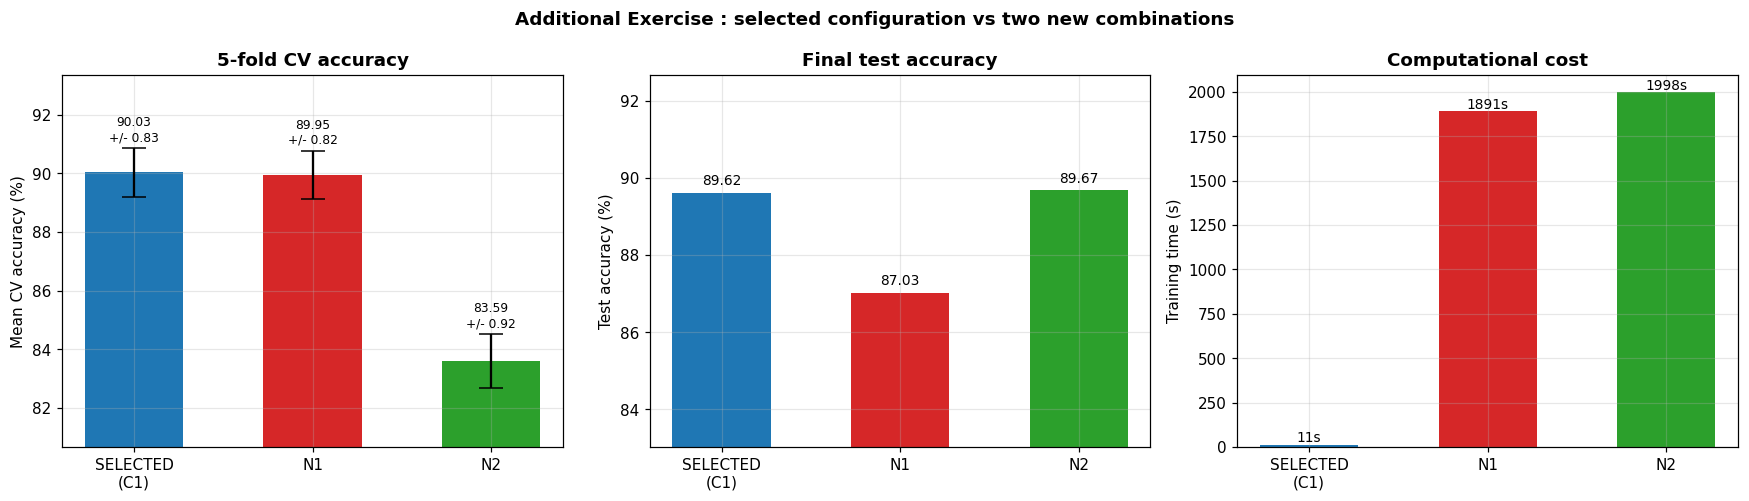


JUSTIFICATION (doc section 16)
  Accuracy      : SELECTED CV = 90.03 %, N1 CV = 89.95 %, N2 CV = 83.59 %
  Variability   : SD  SELECTED = 0.83 | N1 = 0.82 | N2 = 0.92
  Test accuracy : SELECTED = 89.62 % | N1 = 87.03 % | N2 = 89.67 %
  Cost          : SELECTED = 11s | N1 = 1891s | N2 = 1998s

  Best new configuration : N1 (lr=1e-3, drop=0.40, bs=16, unfreeze 20 @ 1e-4)
  VERDICT : neither new combination beats the selected configuration (best new is 0.08 pp
            below it), so the configuration chosen in Part 9 is retained.


In [43]:
# ---- comparison figure and written justification ---------------------------
labels = ["SELECTED\n(%s)" % BEST_CFG_NAME] + list(NEW_CONFIGS.keys())
mus    = [ref_mu] + [new_results[n]["mean"] for n in NEW_CONFIGS]
sds    = [ref_sd] + [new_results[n]["sd"]   for n in NEW_CONFIGS]
tas    = [100 * FINAL_ACC] + [new_test[n]["test"] for n in NEW_CONFIGS]
tms    = [FINAL_TIME] + [new_test[n]["time"] for n in NEW_CONFIGS]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
ax.bar(labels, mus, yerr=sds, capsize=8, color=[PALETTE[i] for i in range(len(labels))], width=.55)
for i, (m_, s_) in enumerate(zip(mus, sds)):
    ax.text(i, m_ + s_ + .25, "%.2f\n+/- %.2f" % (m_, s_), ha="center", fontsize=8)
ax.set_ylabel("Mean CV accuracy (%)"); ax.set_title("5-fold CV accuracy")
ax.set_ylim(min(np.array(mus) - np.array(sds)) - 2, max(np.array(mus) + np.array(sds)) + 2.5)

ax = axes[1]
ax.bar(labels, tas, color=[PALETTE[i] for i in range(len(labels))], width=.55)
for i, v in enumerate(tas): ax.text(i, v + .2, "%.2f" % v, ha="center", fontsize=9)
ax.set_ylabel("Test accuracy (%)"); ax.set_title("Final test accuracy")
ax.set_ylim(min(tas) - 4, max(tas) + 3)

ax = axes[2]
ax.bar(labels, tms, color=[PALETTE[i] for i in range(len(labels))], width=.55)
for i, v in enumerate(tms): ax.text(i, v, "%.0fs" % v, ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Training time (s)"); ax.set_title("Computational cost")
fig.suptitle("Additional Exercise : selected configuration vs two new combinations",
             fontweight="bold")
save_show(fig, "16_additional_exercise")

best_new = max(NEW_CONFIGS, key=lambda n: new_results[n]["mean"])
print("\nJUSTIFICATION (doc section 16)")
print("  Accuracy      : SELECTED CV = %.2f %%, %s CV = %.2f %%, %s CV = %.2f %%"
      % (ref_mu, "N1", new_results["N1"]["mean"], "N2", new_results["N2"]["mean"]))
print("  Variability   : SD  SELECTED = %.2f | N1 = %.2f | N2 = %.2f"
      % (ref_sd, new_results["N1"]["sd"], new_results["N2"]["sd"]))
print("  Test accuracy : SELECTED = %.2f %% | N1 = %.2f %% | N2 = %.2f %%"
      % (100 * FINAL_ACC, new_test["N1"]["test"], new_test["N2"]["test"]))
print("  Cost          : SELECTED = %.0fs | N1 = %.0fs | N2 = %.0fs"
      % (FINAL_TIME, new_test["N1"]["time"], new_test["N2"]["time"]))
delta = new_results[best_new]["mean"] - ref_mu
pooled = max(new_results[best_new]["sd"], ref_sd)
print("\n  Best new configuration : %s (%s)" % (best_new, NEW_CONFIGS[best_new]["desc"]))
if delta > pooled:
    print("  VERDICT : %s improves the mean CV accuracy by %.2f pp, which exceeds the fold-to-fold\n"
          "            standard deviation, so the improvement is meaningful and %s is preferable\n"
          "            provided its extra training cost is acceptable." % (best_new, delta, best_new))
elif delta > 0:
    print("  VERDICT : %s is nominally %.2f pp better, but that is WITHIN the fold-to-fold standard\n"
          "            deviation (%.2f), so the two are statistically indistinguishable. The cheaper /\n"
          "            more stable configuration should be kept." % (best_new, delta, pooled))
else:
    print("  VERDICT : neither new combination beats the selected configuration (best new is %.2f pp\n"
          "            below it), so the configuration chosen in Part 9 is retained." % (-delta))

In [44]:
# ============================================================================
# Wrap-up : experiment summary and saved artefacts (doc section 17)
# ============================================================================
banner("EXPERIMENT 5 - SUMMARY OF EXPERIMENTAL FINDINGS")
print("""
Doc section 17 - Expected Outcome, demonstrated experimentally:

  Initialization  -> best = %s.  Zero initialization never breaks symmetry and stays at the
                     1/37 chance level; He/Xavier converge fastest and highest (Plots 1-2).
  Regularization  -> highest val acc = %s; smallest generalization gap = %s.
                     The unregularized head shows the classic rising-validation-loss
                     overfitting signature (Plots 3-4).
  Batch Norm      -> accelerates and stabilises convergence; the document's numerical example
                     [2,4,6,8] -> [-1.342,-0.447,0.447,1.342] was verified exactly (Plot 5).
  Optimizer       -> best = %s.  Adaptive methods converge in 2-3 epochs where plain SGD at the
                     same learning rate is still far from convergence (Plots 6-7).
  Hyperparameters -> lr = %g, batch = %d, dropout = %.2f  (one variable at a time, Plots 8-10).
  Transfer/FT     -> feature extraction %.2f %% vs fine-tuning %.2f %% validation accuracy;
                     fine-tuning needs a small learning rate to protect the ImageNet weights
                     (Plots 11-12).
  Cross-validation-> best configuration %s : %.2f +/- %.2f %% over %d stratified folds (Plot 13).
  Final model     -> %s : test accuracy %.2f %%, macro-F1 %.3f on the untouched test set
                     (Plots 14-15).
""" % (BEST_INIT, BEST_REG, LOWEST_GAP, BEST_OPT, BEST_LR, BEST_BATCH, BEST_DROPOUT,
       RESULTS["transfer"]["fe"], RESULTS["transfer"]["ft"],
       BEST_CFG_NAME, cv_results[BEST_CFG_NAME]["mean"], cv_results[BEST_CFG_NAME]["sd"], K_FOLDS,
       FINAL_NAME, 100 * FINAL_ACC, RESULTS["final"]["f1"]))

with open(os.path.join(OUT_DIR, "results_summary.json"), "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)

print("Figures and the results summary were saved to ./%s :" % OUT_DIR)
for fn in sorted(os.listdir(OUT_DIR)):
    print("   ", fn)

# ---- always package every figure + the results summary into one zip -------
import shutil
ZIP_PATH = shutil.make_archive("exp5_outputs", "zip", OUT_DIR)
print("\nAll figures and the results summary were archived to : %s  (%.2f MB)"
      % (ZIP_PATH, os.path.getsize(ZIP_PATH) / 1e6))

try:                                 # only available inside Google Colab
    from google.colab import files
    print("Run  files.download('exp5_outputs.zip')  to download every figure.")
except Exception:
    pass



EXPERIMENT 5 - SUMMARY OF EXPERIMENTAL FINDINGS

Doc section 17 - Expected Outcome, demonstrated experimentally:

  Initialization  -> best = He.  Zero initialization never breaks symmetry and stays at the
                     1/37 chance level; He/Xavier converge fastest and highest (Plots 1-2).
  Regularization  -> highest val acc = No regularization; smallest generalization gap = No regularization.
                     The unregularized head shows the classic rising-validation-loss
                     overfitting signature (Plots 3-4).
  Batch Norm      -> accelerates and stabilises convergence; the document's numerical example
                     [2,4,6,8] -> [-1.342,-0.447,0.447,1.342] was verified exactly (Plot 5).
  Optimizer       -> best = Adam.  Adaptive methods converge in 2-3 epochs where plain SGD at the
                     same learning rate is still far from convergence (Plots 6-7).
  Hyperparameters -> lr = 0.0001, batch = 64, dropout = 0.00  (one variable at a time